In [5]:
def plot_fiber_only_map(
    ref_lat, ref_lon,
    das, sta,
    earthquake_location,
    sparse_corr_file,             # <--- NEW: path to sparse npz file
    cartesian_grid_x, cartesian_grid_y,
    lat_range, lon_range,
    fiber_file,
    title="Fiber Coherence Map",
    event_name=None,
    ax=None,
    boundary_margin=5,
    vicinity_km=2
):
    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from matplotlib.lines import Line2D
    from scipy.interpolate import griddata
    import numpy as np
    import os

    # --- Helper: Cartesian -> Geographic ---
    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        earth_radius = 6371  # km
        lat = origin_lat + (y / earth_radius) * (180 / np.pi)
        lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    # --- Helper: load & reconstruct sparse corrmatrix ---
    def load_sparse_corrmatrix(npz_path):
        data = np.load(npz_path)
        indices = data["indices"]
        values = data["values"]
        nnz = int(data["nnz"])
        nx, ny, nz = data["shape"]

        corr_flat = np.zeros(nx * ny * nz, dtype=values.dtype)
        corr_flat[indices[:nnz]] = values[:nnz]
        return corr_flat.reshape((nx, ny, nz))

    file_dir = os.path.dirname(fiber_file)

    # --- Load dense coherence cube from sparse npz ---
    corrmatrix_das = load_sparse_corrmatrix(sparse_corr_file)

    # --- Mask edges of correlation cube ---
    boundary_margin = 1
    corrmatrix_das = corrmatrix_das[
        boundary_margin:-boundary_margin,
        boundary_margin:-boundary_margin,
        boundary_margin:-boundary_margin
    ]
    cartesian_grid_x = cartesian_grid_x[boundary_margin:-boundary_margin, boundary_margin:-boundary_margin]
    cartesian_grid_y = cartesian_grid_y[boundary_margin:-boundary_margin, boundary_margin:-boundary_margin]

    # --- Normalize coherence matrix ---
    corrmatrix = corrmatrix_das / np.nanmax(corrmatrix_das)
    nx, ny, nz = np.shape(corrmatrix)
    dz = 0.1  # km vertical spacing
    depth_axis = np.arange(nz) * dz
    print("Grid shape:", (nx, ny, nz))

    # --- Top-down projection ---
    CXY = np.max(corrmatrix, axis=2).T

    # --- Geographic conversion ---
    lat_grid, lon_grid = cartesian_to_geographic(cartesian_grid_x, cartesian_grid_y, ref_lat, ref_lon)
    lat_lin = np.linspace(lat_range[0], lat_range[1], ny)
    lon_lin = np.linspace(lon_range[0], lon_range[1], nx)
    grid_lon, grid_lat = np.meshgrid(lon_lin, lat_lin)

    interpolated_CXY = griddata(
        (lat_grid.flatten(), lon_grid.flatten()),
        CXY.flatten(),
        (grid_lat, grid_lon),
        method='cubic'
    )

    # --- Boundary-safe max (avoid edges) on XY projection ---
    margin = 1
    valid_region = np.copy(interpolated_CXY)
    valid_region[:margin, :] = np.nan
    valid_region[-margin:, :] = np.nan
    valid_region[:, :margin] = np.nan
    valid_region[:, -margin:] = np.nan

    max_index_xy = np.unravel_index(np.nanargmax(valid_region), valid_region.shape)
    ix_max, iy_max = max_index_xy

    max_lat = grid_lat[ix_max, iy_max]
    max_lon = grid_lon[ix_max, iy_max]

    # --- Compute depth at max coherence (initial coarse point) ---
    max_depth_index = np.nanargmax(corrmatrix[ix_max, iy_max, :])
    max_depth = depth_axis[max_depth_index]

    print(f"📍 Max Coherence Position (boundary-safe, coarse):")
    print(f"   Latitude : {max_lat:.5f}")
    print(f"   Longitude: {max_lon:.5f}")
    print(f"   Depth    : {max_depth:.5f} km")

    # --- Define vicinity (±vicinity_km) ---
    km_per_deg_lat = 111.32
    km_per_deg_lon = 111.32 * np.cos(np.radians(max_lat))
    half_deg_lat = (vicinity_km / 2) / km_per_deg_lat
    half_deg_lon = (vicinity_km / 2) / km_per_deg_lon
    local_lat_min, local_lat_max = max_lat - half_deg_lat, max_lat + half_deg_lat
    local_lon_min, local_lon_max = max_lon - half_deg_lon, max_lon + half_deg_lon

    # --- Mask local region in XY map ---
    lat_mask = (grid_lat[:, 0] >= local_lat_min) & (grid_lat[:, 0] <= local_lat_max)
    lon_mask = (grid_lon[0, :] >= local_lon_min) & (grid_lon[0, :] <= local_lon_max)
    local_grid_lat = grid_lat[np.ix_(lat_mask, lon_mask)]
    local_grid_lon = grid_lon[np.ix_(lat_mask, lon_mask)]
    local_interp = interpolated_CXY[np.ix_(lat_mask, lon_mask)]

    fig, (ax_map, ax_xz, ax_yz) = plt.subplots(
        1, 3, figsize=(15, 5), dpi=300,
        gridspec_kw={'width_ratios': [1, 1, 1]}
    )

    # ####################
    # XY VIEW (MAP)
    # ####################
    m = Basemap(
        projection='cyl',
        llcrnrlat=local_lat_min, urcrnrlat=local_lat_max,
        llcrnrlon=local_lon_min, urcrnrlon=local_lon_max,
        resolution='h', ax=ax_map
    )
    m.drawcoastlines(linewidth=0.5)
    m.drawcountries(linewidth=0.5)
    m.fillcontinents(color='lightgray', lake_color='lightblue')
    m.drawmapboundary(fill_color='lightblue')

    cs = ax_map.contourf(local_grid_lon, local_grid_lat, local_interp,
                         levels=20, cmap='viridis', alpha=0.85)

    # ticks
    n_xticks = 4
    n_yticks = 4
    xticks = np.linspace(local_lon_min, local_lon_max, n_xticks)
    yticks = np.linspace(local_lat_min, local_lat_max, n_yticks)
    ax_map.set_xticks(xticks)
    ax_map.set_yticks(yticks)
    ax_map.tick_params(axis='both', which='both', direction='out', labelsize=8)

    # --- Plot earthquake & max coherence on map ---
    ax_map.scatter(
        earthquake_location[1], earthquake_location[0],
        marker='*', color='red', edgecolors='black',
        s=130, label='Catalog Location'
    )
    ax_map.scatter(
        max_lon, max_lat, marker='*', facecolors='yellow',
        edgecolors='black', s=130, label='Max Coherence'
    )

    # --- Plot DAS positions (map) ---
    for name, coords in das.items():
        lat, lon = coords[:2]
        if (local_lat_min <= lat <= local_lat_max) and (local_lon_min <= lon <= local_lon_max):
            ax_map.scatter(lon, lat, marker='^', color='orange', s=25)
            ax_map.text(lon + 0.0002, lat + 0.0002, name,
                        fontsize=6, color='black', ha='left', va='bottom')

    # --- Plot Station positions (map) ---
    for name, coords in sta.items():
        lat, lon = coords[:2]
        if (local_lat_min <= lat <= local_lat_max) and (local_lon_min <= lon <= local_lon_max):
            ax_map.scatter(lon, lat, marker='^', color='crimson', s=25)
            ax_map.text(lon + 0.0002, lat + 0.0002, name,
                        fontsize=6, color='black', ha='left', va='bottom')

    ax_map.set_title(f"{title} (Local ±{vicinity_km/2:.1f} km)", fontsize=12)
    ax_map.set_xlabel("Longitude")
    ax_map.set_ylabel("Latitude")

    cbar = fig.colorbar(cs, ax=ax_map, orientation='vertical', pad=0.02, shrink=0.8)
    cbar.set_label('Normalized Coherence')

    # ####################
    # LOCAL VOLUME & REFINED MAX
    # ####################
    # Extract local slice indices in the *original* longitude / latitude axes
    lat_indices = np.where((lat_lin >= local_lat_min) & (lat_lin <= local_lat_max))[0]
    lon_indices = np.where((lon_lin >= local_lon_min) & (lon_lin <= local_lon_max))[0]
    depth_indices = np.arange(nz)

    # REFINE: search for THE max in the 3D sub-volume
    local_corr = corrmatrix[np.ix_(lon_indices, lat_indices, depth_indices)]
    local_max_index = np.unravel_index(np.nanargmax(local_corr), local_corr.shape)
    lx, ly, lz = local_max_index   # indices in local_corr

    # Convert back to global lon/lat/depth
    refined_lon = lon_lin[lon_indices[lx]]
    refined_lat = lat_lin[lat_indices[ly]]
    refined_depth = depth_axis[depth_indices[lz]]

    print("🔍 Refined local max in volume:")
    print(f"   Latitude : {refined_lat:.5f}")
    print(f"   Longitude: {refined_lon:.5f}")
    print(f"   Depth    : {refined_depth:.5f} km")

    # ####################
    # XZ VIEW (Longitude–Depth)
    # ####################
    C_xz_local = local_corr.transpose(2, 1, 0)  # (depth, lat, lon)
    C_xz_slice = np.max(C_xz_local, axis=1)     # max over lat -> (depth, lon)

    lon_extent = [lon_lin[lon_indices[0]], lon_lin[lon_indices[-1]]]
    im1 = ax_xz.imshow(
        C_xz_slice,
        extent=[lon_extent[0], lon_extent[1], depth_axis[-1], depth_axis[0]],
        aspect='auto', cmap='viridis'
    )
    ax_xz.set_xlabel("Longitude")
    ax_xz.set_ylabel("Depth (km)")
    ax_xz.set_title("Longitude–Depth")
    ax_xz.invert_yaxis()
    ax_xz.tick_params(axis='both', which='both', direction='out', labelsize=8)

    # --- XZ refined max marker ---
    ax_xz.scatter(refined_lon, refined_depth,
                  color='yellow', edgecolor='black', s=70, marker='*', zorder=5)

    # ####################
    # YZ VIEW (Latitude–Depth)
    # ####################
    C_yz_local = local_corr.transpose(2, 0, 1)  # (depth, lon, lat)
    C_yz_slice = np.max(C_yz_local, axis=1)     # max over lon -> (depth, lat)

    lat_extent = [lat_lin[lat_indices[0]], lat_lin[lat_indices[-1]]]
    im2 = ax_yz.imshow(
        C_yz_slice,
        extent=[lat_extent[0], lat_extent[1], depth_axis[-1], depth_axis[0]],
        aspect='auto', cmap='viridis'
    )
    ax_yz.set_xlabel("Latitude")
    ax_yz.set_ylabel("Depth (km)")
    ax_yz.set_title("Latitude–Depth")
    ax_yz.invert_yaxis()
    ax_yz.tick_params(axis='both', which='both', direction='out', labelsize=8)

    # --- YZ refined max marker ---
    ax_yz.scatter(refined_lat, refined_depth,
                  color='yellow', edgecolor='black', s=70, marker='*', zorder=5)

    # ####################
    # Fixed red star marker in all views
    # ####################
    ref_lat_marker = 46.51049267 #46.51057784
    ref_lon_marker = 8.476303318 #8.47647181
    ref_depth_km = 1.427 #1.420


    ax_map.scatter(ref_lon_marker, ref_lat_marker,
                   marker='*', color='red', edgecolors='black', s=130, zorder=5)

    ax_xz.scatter(ref_lon_marker, ref_depth_km,
                  color='red', edgecolor='black', s=80, marker='*', zorder=5)
    ax_yz.scatter(ref_lat_marker, ref_depth_km,
                  color='red', edgecolor='black', s=80, marker='*', zorder=5)

    # ####################
    # DAS & STATIONS on vertical slices
    # ####################
    for name, coords in das.items():
        lat, lon, depth_das = coords[:3]
        if (local_lat_min <= lat <= local_lat_max) and (local_lon_min <= lon <= local_lon_max):
            ax_xz.scatter(lon, depth_das, marker='^', color='orange', s=20)
            ax_yz.scatter(lat, depth_das, marker='^', color='orange', s=20)

    for name, coords in sta.items():
        lat, lon, depth_sta = coords[:3]
        if (local_lat_min <= lat <= local_lat_max) and (local_lon_min <= lon <= local_lon_max):
            ax_xz.scatter(lon, depth_sta, marker='^', color='crimson', s=20)
            ax_yz.scatter(lat, depth_sta, marker='^', color='crimson', s=20)

    # ####################
    # Legend
    # ####################
    custom_handles = [
        Line2D([0], [0], marker='*', color='red', label='Catalog Location',
               markersize=10, linestyle='', markeredgecolor='black'),
        Line2D([0], [0], marker='*', color='none', label='Max Coherence (refined)',
               markersize=10, linestyle='', markeredgecolor='black'),
        Line2D([0], [0], marker='^', color='crimson', label='Seismometers',
               linestyle='', markersize=6),
        Line2D([0], [0], marker='^', color='orange', label='DAS',
               linestyle='', markersize=6),
    ]
    ax_map.legend(handles=custom_handles, loc='lower right',
                  fontsize='small', frameon=True)

    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])

    output_file = os.path.join(
        file_dir,
        f"{event_name}_fiber_map_local_2km_horizontal.pdf" if event_name else "fiber_map_local_2km_horizontal.pdf"
    )
    plt.savefig(output_file, bbox_inches='tight')
    plt.show()

    print(f"✅ Saved local vicinity plot: {output_file}")



=== Stations ===
Using file: /home/emanuele/data/emanuele/loki-das/campi-flegrei/output_vlp_12_30_no_sta_lta/fiber/corrmatrix_sparse_best_0_fiber.npz


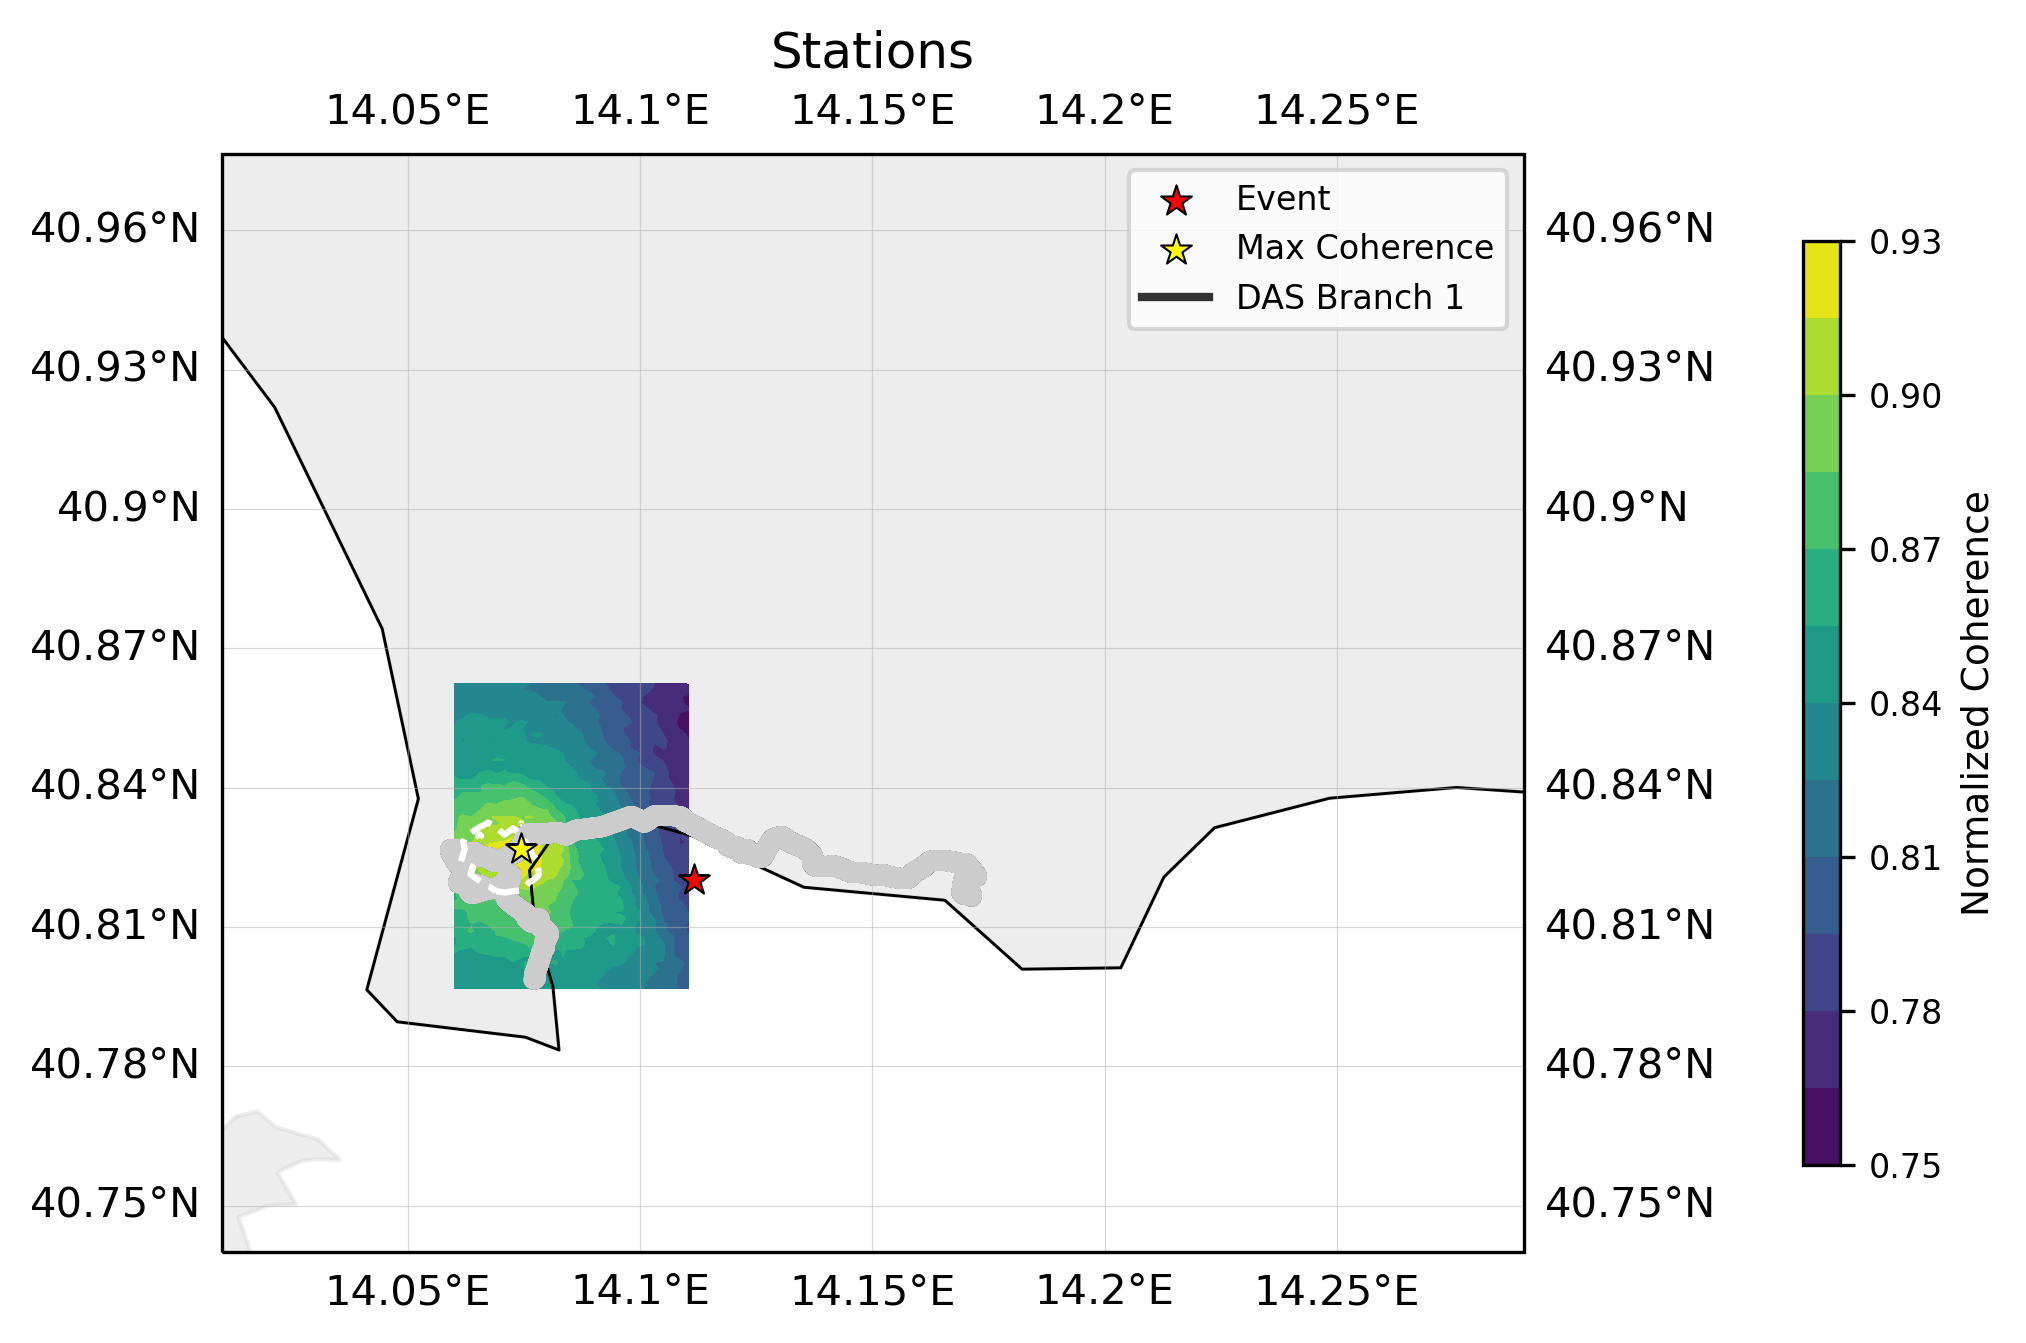


=== Fiber ===
Using file: /home/emanuele/data/emanuele/loki-das/campi-flegrei/output_vlp_12_30_no_sta_lta/fiber/corrmatrix_sparse_best_0_fiber.npz


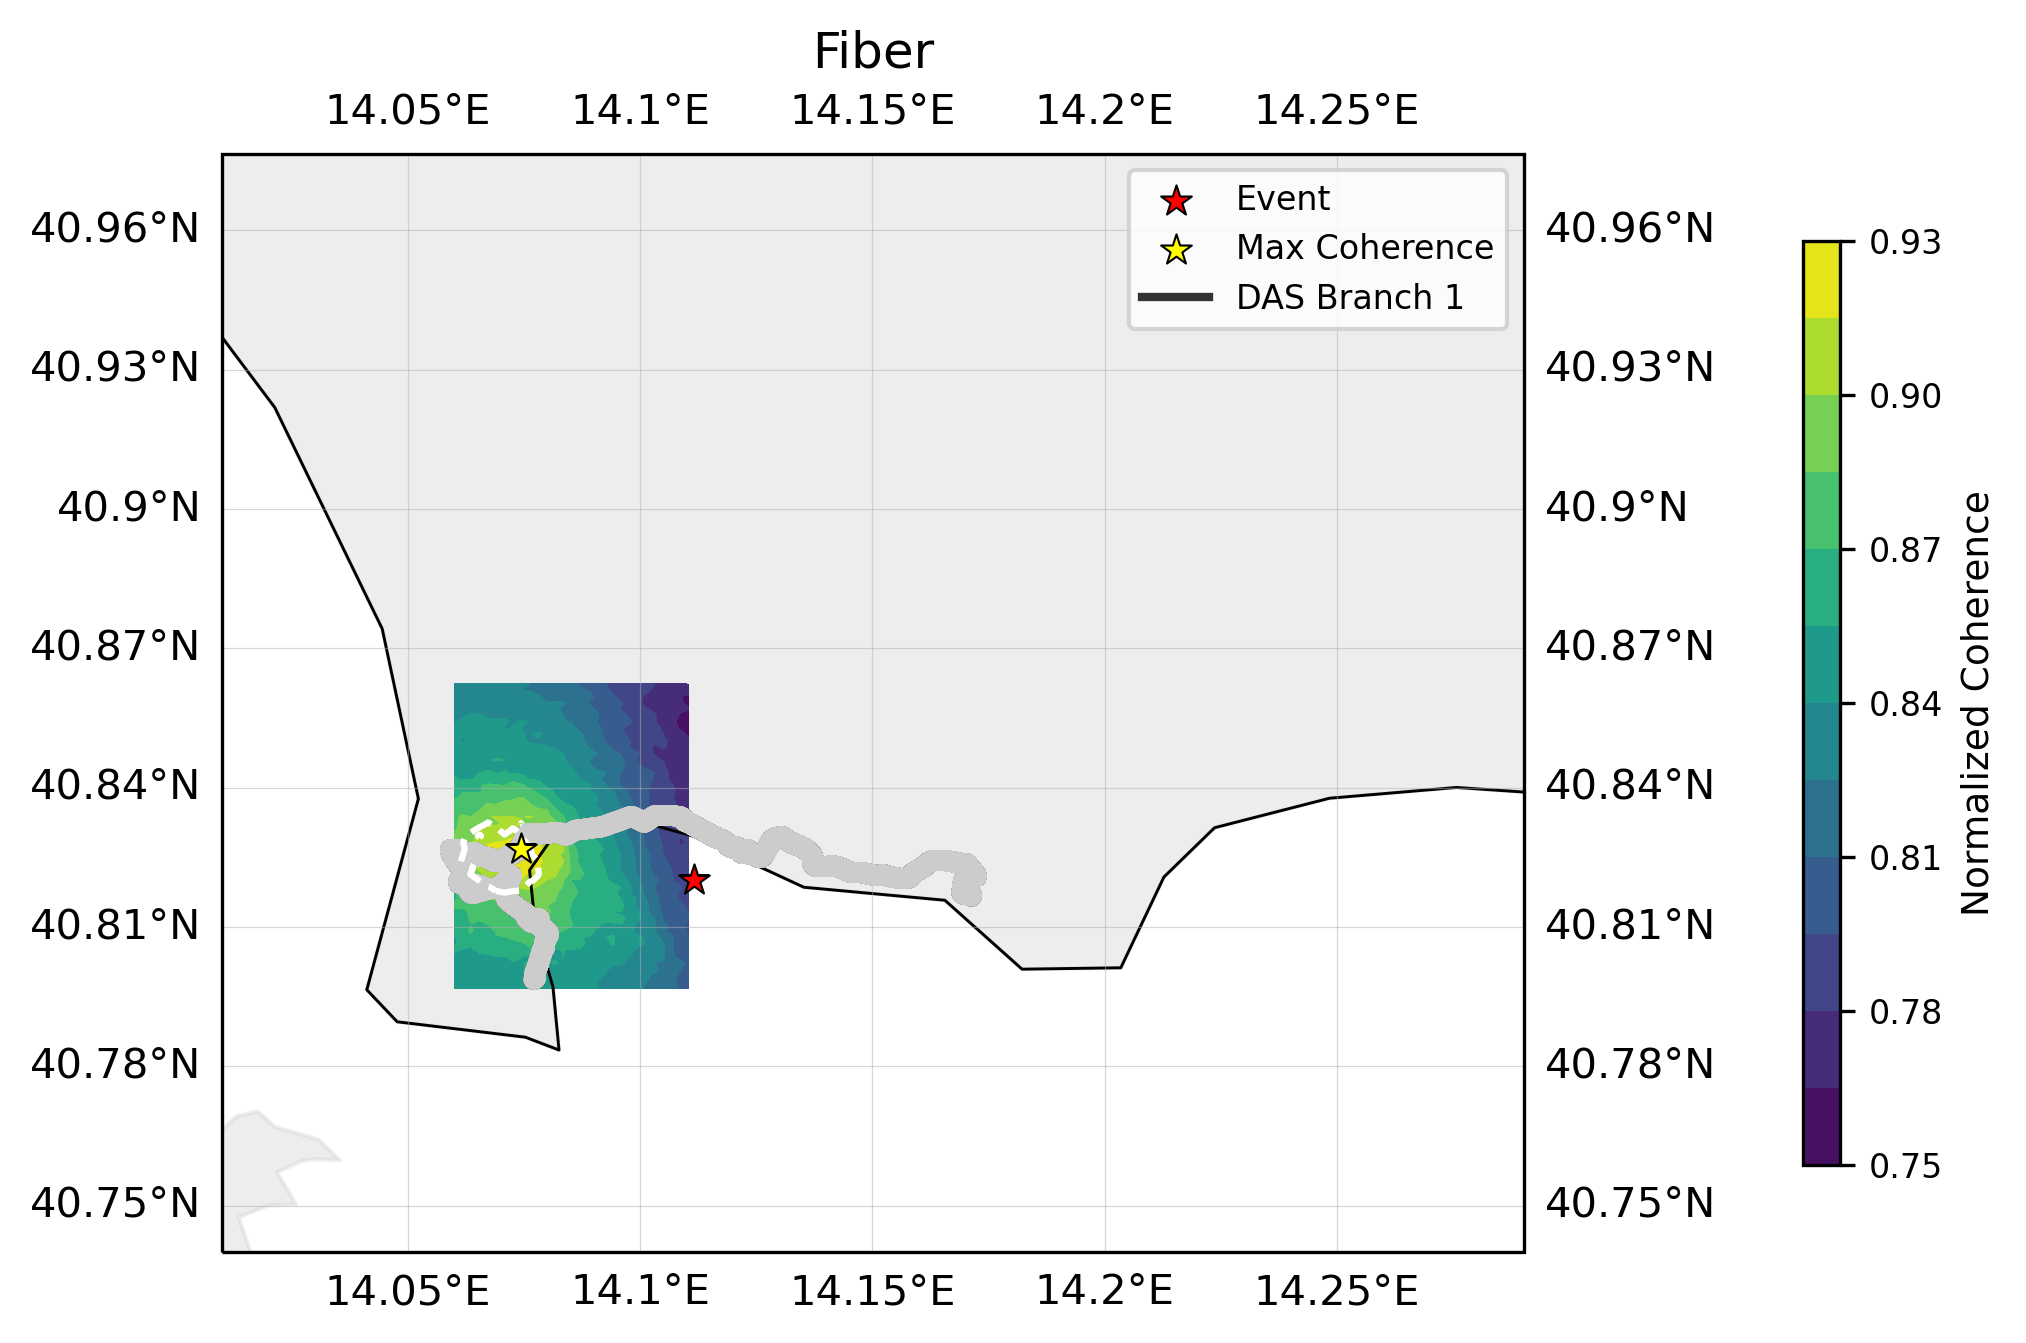


=== Hybrid ===
Using file: /home/emanuele/data/emanuele/loki-das/campi-flegrei/output_vlp_12_30_no_sta_lta/fiber/corrmatrix_sparse_best_0_fiber.npz


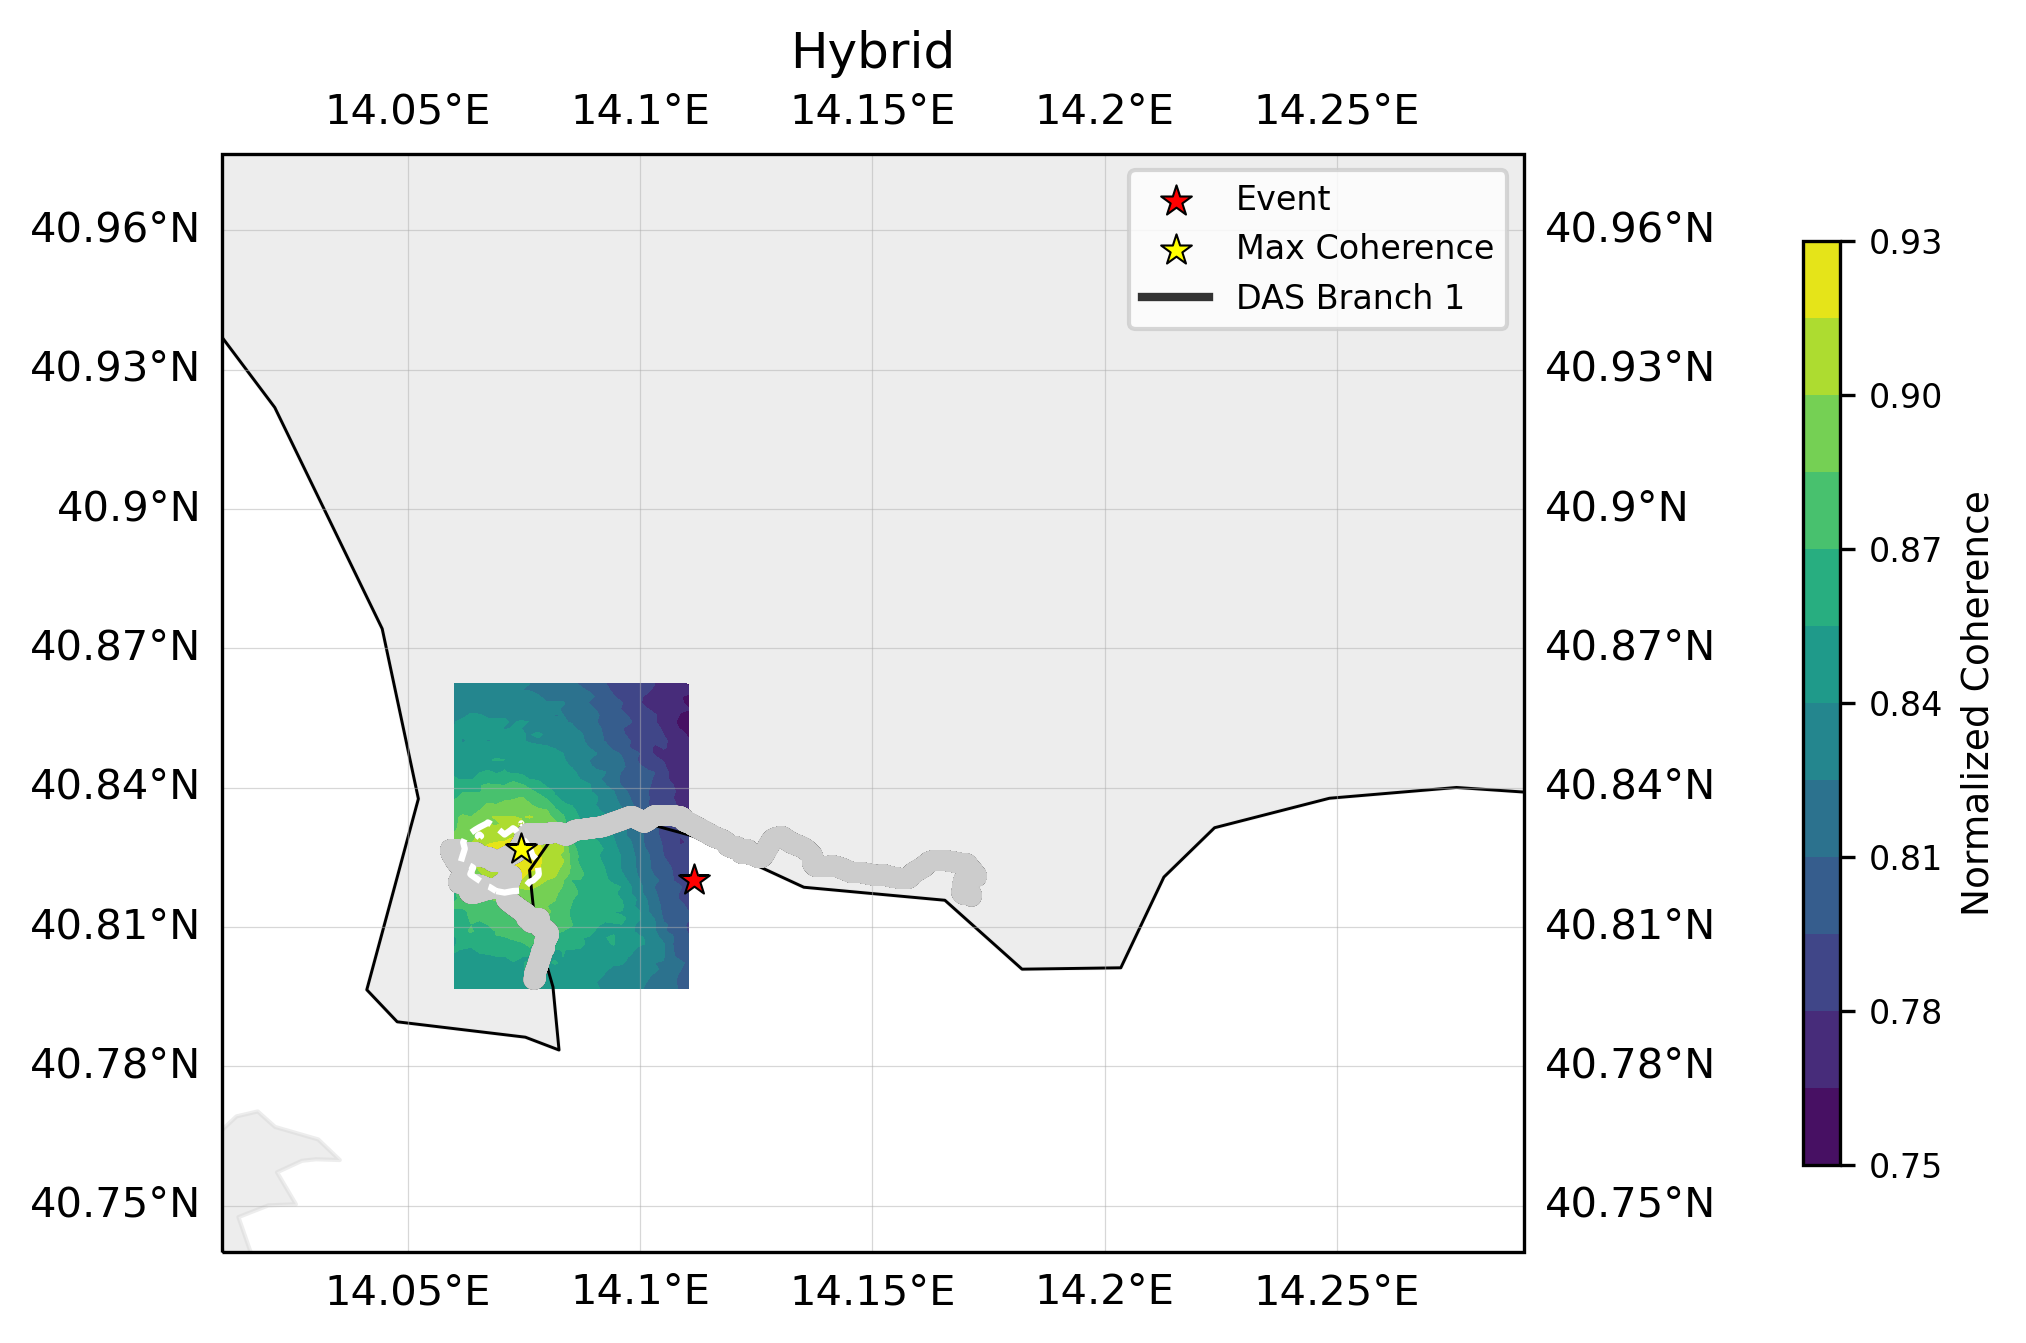

In [37]:
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

# --- Reference Coordinates ---


import pandas as pd

def read_das_geometry(
    filename,
    prefix="CH",
    label="SEL HYB",
    ch_min=None,
    ch_max=None
):
    """
    Read DAS geometry file and return a dictionary:
    { 'CH0041 (SEL HYB)': (lat, lon), ... }
    """

    df = pd.read_csv(
        filename,
        delim_whitespace=True,
        names=["ch_id", "lat", "lon", "depth"]
    )

    # Optional channel selection
    if ch_min is not None:
        df = df[df["ch_id"] >= ch_min]
    if ch_max is not None:
        df = df[df["ch_id"] <= ch_max]

    das_dict = {
        f"{prefix}{int(row.ch_id):04d} ({label})": (row.lat, row.lon)
        for _, row in df.iterrows()
    }

    return das_dict


stations = read_das_geometry(
    "/home/emanuele/data/emanuele/loki-das/Traveltimes/campi-flegrei/DAS_geom.txt",
    prefix="A",
    ch_min=41,
    ch_max=4400
)

das_hyb1 = read_das_geometry(
    "/home/emanuele/data/emanuele/loki-das/Traveltimes/campi-flegrei/DAS_geom.txt",
    prefix="A",
    ch_min=41,
    ch_max=4400
)

das_hyb2 = read_das_geometry(
    "/home/emanuele/data/emanuele/loki-das/Traveltimes/campi-flegrei/DAS_geom.txt",
    prefix="B",
    ch_min=41,
    ch_max=4400
)

das_hyb3 = read_das_geometry(
    "/home/emanuele/data/emanuele/loki-das/Traveltimes/campi-flegrei/DAS_geom.txt",
    prefix="C",
    ch_min=41,
    ch_max=4400
)

das_hyb4 = read_das_geometry(
    "/home/emanuele/data/emanuele/loki-das/Traveltimes/campi-flegrei/DAS_geom.txt",
    prefix="D",
    ch_min=41,
    ch_max=4400
)

das_hyb5 = read_das_geometry(
    "/home/emanuele/data/emanuele/loki-das/Traveltimes/campi-flegrei/DAS_geom.txt",
    prefix="E",
    ch_min=41,
    ch_max=4400
)

das_groups = [
    das_hyb1,
    das_hyb2,
    das_hyb3,
    das_hyb4,
    das_hyb5,
]


import numpy as np
import os
import glob
import matplotlib.pyplot as plt

# --------------------------
# MAP LIBRARIES
# --------------------------
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata

# --------------------------
# REFERENCE COORDINATES
# --------------------------
ref_lat = 40.79 
ref_lon = 14.06

# --------------------------
# STATIONS

# --------------------------
# DAS (reduced example)
# --------------------------

# --------------------------
# EVENTS
# --------------------------
events = {

    "event": (40.820040564, 14.111585681, 0)
}


#vlp_12_30 = 40.820040564, 14.111585681, 2.52

#vt_16_30 = 40.8315, 14.1307
#vt_12_30 = 40.8093, 14.1030




# --------------------------
# FOLDERS
# --------------------------
base_dir_root = "/home/emanuele/data/emanuele/loki-das/campi-flegrei/output_vlp_12_30_no_sta_lta"
folders = {
    "Stations": "fiber",
    "Fiber": "fiber",
    "Hybrid": "fiber",
}

# ============================================================
# ======================= UTILITIES ==========================
# ============================================================

import pandas as pd

def read_das_geometry(
    filename,
    prefix="CH",
    label="SEL HYB",
    ch_min=None,
    ch_max=None
):
    """
    Read DAS geometry file and return a dictionary:
    { 'CH0041 (SEL HYB)': (lat, lon), ... }
    """

    df = pd.read_csv(
        filename,
        delim_whitespace=True,
        names=["ch_id", "lat", "lon", "depth"]
    )

    # Optional channel selection
    if ch_min is not None:
        df = df[df["ch_id"] >= ch_min]
    if ch_max is not None:
        df = df[df["ch_id"] <= ch_max]

    das_dict = {
        f"{prefix}{int(row.ch_id):04d} ({label})": (row.lat, row.lon)
        for _, row in df.iterrows()
    }

    return das_dict


def select_highest_coherence_file(folder):
    candidates = glob.glob(os.path.join(folder, "*.npz"))
    if not candidates:
        raise FileNotFoundError(f"No .npz files in {folder}")

    best_file, best_val = None, -np.inf
    for f in candidates:
        try:
            d = np.load(f)
            vmax = d["values"].max()
            if vmax > best_val:
                best_val = vmax
                best_file = f
        except Exception:
            continue

    return best_file


def load_sparse_corrmatrix(npz_path):
    data = np.load(npz_path)
    values = data["values"]
    indices = data["indices"]
    nx, ny, nz = data["shape"]

    dense = np.zeros((nx, ny, nz))

    # Case 1: indices are (N,3)
    if indices.ndim == 2 and indices.shape[1] == 3:
        dense[indices[:, 0], indices[:, 1], indices[:, 2]] = values

    # Case 2: flattened indices
    elif indices.ndim == 1:
        ix, iy, iz = np.unravel_index(indices, (nx, ny, nz))
        dense[ix, iy, iz] = values

    else:
        raise ValueError(f"Unknown indices format: {indices.shape}")

    return dense


# ============================================================
# ======================= PLOTTING ===========================
# ============================================================

def plot_fiber_only_map(
    ref_lat,
    ref_lon,
    stations,
    earthquake_location,
    sparse_corr_file,
    title,
):

    # --------------------------
    # LOAD CUBE
    # --------------------------
    corrmatrix = load_sparse_corrmatrix(sparse_corr_file)
    # --------------------------
# 95th percentile over depth
# --------------------------

    nx, ny, nz = corrmatrix.shape


    # --------------------------
    # BUILD LAT/LON GRID
    # --------------------------
    lat_lin = np.linspace(ref_lat, ref_lat + nx * 0.15 / 111, ny)
    lon_lin = np.linspace(
        ref_lon,
        ref_lon + ny * 0.15 / (111 * np.cos(np.radians(ref_lat))),
        nx,
    )

    grid_lon, grid_lat = np.meshgrid(lon_lin, lat_lin)

        # Max over depth
    CXY = np.max(corrmatrix, axis=2).T

    # 95th percentile over depth
    P95 = np.percentile(corrmatrix, 95, axis=2).T

    # --------------------------
# INTERPOLATION (MAX)
# --------------------------
    interp = griddata(
        (grid_lat.flatten(), grid_lon.flatten()),
        CXY.flatten(),
        (grid_lat, grid_lon),
        method="cubic",
    )

    interp = np.nan_to_num(interp, nan=0.0)

    # --------------------------
    # INTERPOLATION (P95)
    # --------------------------
    interp_p95 = griddata(
        (grid_lat.flatten(), grid_lon.flatten()),
        P95.flatten(),
        (grid_lat, grid_lon),
        method="cubic",
    )

    interp_p95 = np.nan_to_num(interp_p95, nan=0.0)



    # --------------------------
    # INTERPOLATION
    # --------------------------
    interp = griddata(
        (grid_lat.flatten(), grid_lon.flatten()),
        CXY.flatten(),
        (grid_lat, grid_lon),
        method="cubic",
    )

    # Remove NaNs safely
    interp = np.nan_to_num(interp, nan=0.0)

    # --------------------------
    # THRESHOLD (REMOVE SPECKLE)
    # --------------------------


    # --------------------------
    # MAX LOCATION
    # --------------------------
    imax = np.unravel_index(np.argmax(interp), interp.shape)
    max_lat = grid_lat[imax]
    max_lon = grid_lon[imax]

    # ============================================================
    # ======================== MAP ===============================
    # ============================================================

    fig = plt.figure(figsize=(8, 8), dpi = 300)
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.4)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.add_feature(cfeature.RIVERS, linewidth=0.4)
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

    pad = 0.05
    ax.set_extent([
        grid_lon.min() - pad,
        grid_lon.max() + pad,
        grid_lat.min() - pad,
        grid_lat.max() + pad,
    ])
    # --------------------------
    # THRESHOLD (REMOVE SPECKLE)
    # --------------------------
    max_val = np.max(interp)
    threshold = 0.3 * max_val  # 30% of max
    interp_masked = np.ma.masked_where(interp < threshold, interp)

    # Apply same mask to P95
    interp_p95_masked = np.ma.masked_where(interp < threshold, interp_p95)

    # --------------------------
    # MAX LOCATION
    # --------------------------
    imax = np.unravel_index(np.argmax(interp), interp.shape)
    max_lat = grid_lat[imax]
    max_lon = grid_lon[imax]

    # ============================================================
    # ======================== MAP ===============================
    # ============================================================

    cs = ax.contourf(
        grid_lon,
        grid_lat,
        interp_masked,
        levels=15,
        cmap="viridis",
        transform=ccrs.PlateCarree(),
    )

# --------------------------
# THRESHOLD (REMOVE SPECKLE)
# --------------------------
    max_val = np.max(interp)
    threshold = 0.3 * max_val  # 30% of max
    interp_masked = np.ma.masked_where(interp < threshold, interp)

    # --------------------------
    # 95th percentile contour (single line)
    # --------------------------
    # Mask P95 inside high-coherence region
    interp_p95_masked = np.ma.masked_where(interp < threshold, interp_p95)

    # Compute 95th percentile value of masked P95
    p95_value = np.percentile(interp_p95_masked.compressed(), 95)

    # Draw a single white contour line
    ax.contour(
        grid_lon,
        grid_lat,
        interp_p95_masked,
        levels=[p95_value],        # only one level
        colors="white",
        linewidths=1.5,
        linestyles="--",
        transform=ccrs.PlateCarree(),
        zorder=6,
    )


    cb = fig.colorbar(
        cs,
        ax=ax,
        orientation="vertical",
        shrink=0.5,     # reduce height
        pad=0.15,        # distance from map
        aspect=25        # thinner colorbar
    )

    cb.set_label("Normalized Coherence", fontsize=9)
    cb.ax.tick_params(labelsize=8)


    # --------------------------
    # EVENT
    # --------------------------
    eq_lat, eq_lon, _ = earthquake_location
    ax.scatter(
        eq_lon,
        eq_lat,
        marker="*",
        s=60,
        color="red",
        edgecolors="black",
        linewidths=0.5,
        label="Event",
        transform=ccrs.PlateCarree(),
        zorder=5,
    )

    # --------------------------
    # MAX COHERENCE
    # --------------------------
    ax.scatter(
        max_lon,
        max_lat,
        marker="*",
        s=60,
        color="yellow",
        edgecolors="black",
        linewidths=0.5,
        label="Max Coherence",
        transform=ccrs.PlateCarree(),
        zorder=6,
    )

    # --------------------------
    # DAS
    # --------------------------
# --------------------------
# DAS (5 branches as lines)
# --------------------------
    grey_shades = ["0.2", "0.35", "0.5", "0.65", "0.8"]

    for i, das in enumerate(das_groups):

        lats = [coords[0] for coords in das.values()]
        lons = [coords[1] for coords in das.values()]

        # Plot connected line
        ax.plot(
            lons,
            lats,
            color=grey_shades[i],
            linewidth=2,
            transform=ccrs.PlateCarree(),
            zorder=4,
            label=f"DAS Branch {i+1}" if i == 0 else None,  # only one legend entry
        )

        # Optional: small nodes
        ax.scatter(
            lons,
            lats,
            s=15,
            color=grey_shades[i],
            transform=ccrs.PlateCarree(),
            zorder=5,
        )

    ax.set_title(title)
    ax.legend(fontsize=8)
    plt.show()


    # --------------------------
    # STATIONS
    # --------------------------
# --------------------------
# STATIONS (single legend entry)
# --------------------------
'''
    first = True
    for lat, lon in stations.values():
        ax.scatter(
            lon,
            lat,
            marker="^",
            s=30,
            color="darkorange",
            edgecolors="black",
            linewidths=0.5,
            label="3C" if first else None,
            transform=ccrs.PlateCarree(),
            zorder=4,
        )


        first = False

'''



# ============================================================
# ======================== MAIN LOOP =========================
# ============================================================

for label, folder_name in folders.items():

    folder = os.path.join(base_dir_root, folder_name)
    print(f"\n=== {label} ===")

    try:
        sparse_file = select_highest_coherence_file(folder)
        print(f"Using file: {sparse_file}")
    except Exception as e:
        print(f"Skipping {label}: {e}")
        continue

    for name, eq_loc in events.items():
        plot_fiber_only_map(
            ref_lat,
            ref_lon,
            stations,
            eq_loc,
            sparse_file,
            title=f"{label}",
        )


In [ ]:
def plot_fiber_only_map(ref_lat, ref_lon, das_hyb, earthquake_location,
                        corrmatrix_das, cartesian_grid_x, cartesian_grid_y,
                        lat_range, lon_range, fiber_file,
                        title="Fiber Coherence Map", event_name=None, ax=None,
                        boundary_margin=5):
    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from matplotlib.lines import Line2D
    from scipy.interpolate import griddata
    import numpy as np
    import os

    # --- Helper: Cartesian -> Geographic ---
    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        earth_radius = 6371  # km
        lat = origin_lat + (y / earth_radius) * (180 / np.pi)
        lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    file_dir = os.path.dirname(fiber_file)

    # --- Mask boundaries to avoid edge peaks ---
    corrmatrix_das = corrmatrix_das[
        boundary_margin:-boundary_margin,
        boundary_margin:-boundary_margin,
        boundary_margin:-boundary_margin
    ]
    cartesian_grid_x = cartesian_grid_x[boundary_margin:-boundary_margin, boundary_margin:-boundary_margin]
    cartesian_grid_y = cartesian_grid_y[boundary_margin:-boundary_margin, boundary_margin:-boundary_margin]

    # --- Normalize the coherence matrix ---
    corrmatrix = corrmatrix_das / np.nanmax(corrmatrix_das)
    nx, ny, nz = np.shape(corrmatrix)
    CXY = np.max(corrmatrix, axis=2).T

    lat_grid, lon_grid = cartesian_to_geographic(cartesian_grid_x, cartesian_grid_y, ref_lat, ref_lon)

    lat_lin = np.linspace(lat_range[0], lat_range[1], ny)
    lon_lin = np.linspace(lon_range[0], lon_range[1], nx)
    grid_lon, grid_lat = np.meshgrid(lon_lin, lat_lin)

    interpolated_CXY = griddata(
        (lat_grid.flatten(), lon_grid.flatten()), 
        CXY.flatten(), 
        (grid_lat, grid_lon), 
        method='cubic'
    )

    # --- Setup figure/axis ---
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
        created_fig = True
    else:
        fig = ax.get_figure()

    m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='h', ax=ax)

    m.drawcoastlines()
    m.drawcountries()
    m.fillcontinents(color='lightgray', lake_color='lightblue')
    m.drawmapboundary(fill_color='lightblue')
    m.drawparallels(np.arange(lat_range[0], lat_range[1] + 0.01, 0.2), labels=[1,0,0,0], fontsize=8)
    m.drawmeridians(np.arange(lon_range[0], lon_range[1] + 0.01, 0.2), labels=[0,0,0,1], fontsize=8)

    cs = ax.contourf(grid_lon, grid_lat, interpolated_CXY, levels=20, cmap='viridis', alpha=0.8)

    # --- Event & Max Coherence ---
    ax.scatter(earthquake_location[1], earthquake_location[0], marker='*', color='red', edgecolors='black', s=130, label='Catalog Location')

    max_index = np.unravel_index(np.nanargmax(interpolated_CXY), interpolated_CXY.shape)
    max_lat = grid_lat[max_index]
    max_lon = grid_lon[max_index]
    print(f"Max Coherence Location, lat, lon: {max_lat}, {max_lon}")
    ax.scatter(max_lon, max_lat, marker='*', facecolors='none', edgecolors='black', s=130, label='Max Coherence')

    # --- DAS HYB points ---
    for name, (lat, lon) in das_hyb.items():
        ax.scatter(lon, lat, marker='o', color='crimson', s=14)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    if created_fig:
        cbar = fig.colorbar(cs, ax=ax, orientation='vertical', pad=0.02, shrink=0.5, aspect=20)
        cbar.set_label('Normalized Coherence')

    # --- Legend ---
    custom_handles = [
        Line2D([0], [0], marker='*', color='red', label='Cluster center', markersize=12, linestyle='', markeredgecolor='black'),
        Line2D([0], [0], marker='*', color='none', label='Max Coherence', markersize=12, linestyle='', markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='crimson', label='DAS fiber', linestyle='', markersize=6)
    ]
    ax.legend(handles=custom_handles, loc='lower right', fontsize='small', frameon=True)

    if created_fig:
        output_file = os.path.join(file_dir, f"{event_name}_fiber_map.pdf" if event_name else "fiber_map.pdf")
        plt.savefig(output_file, bbox_inches='tight')
        plt.show()


Error loading coherence file for Orion: Missing .npy file: /home/emanuele/data/emanuele/loki-das/cefalonia/output_prova_low_srn_OS/kef_0380/fiber_orion/corrmatrix_trial_3_fiber.npy
Error loading coherence file for Random: Missing .npy file: /home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2_gilbert/kef0187/fiber_uniform/corrmatrix_trial_2_fiber.npy
Error loading coherence file for Hybrid_gilbert: Missing .npy file: /home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2_gilbert/kef0187/hybrid_gilbert/corrmatrix_trial_2_hybrid.npy
Error loading coherence file for Stations: Missing .npy file: /home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2_gilbert/kef0187/stations/corrmatrix_trial_1_stations.npy


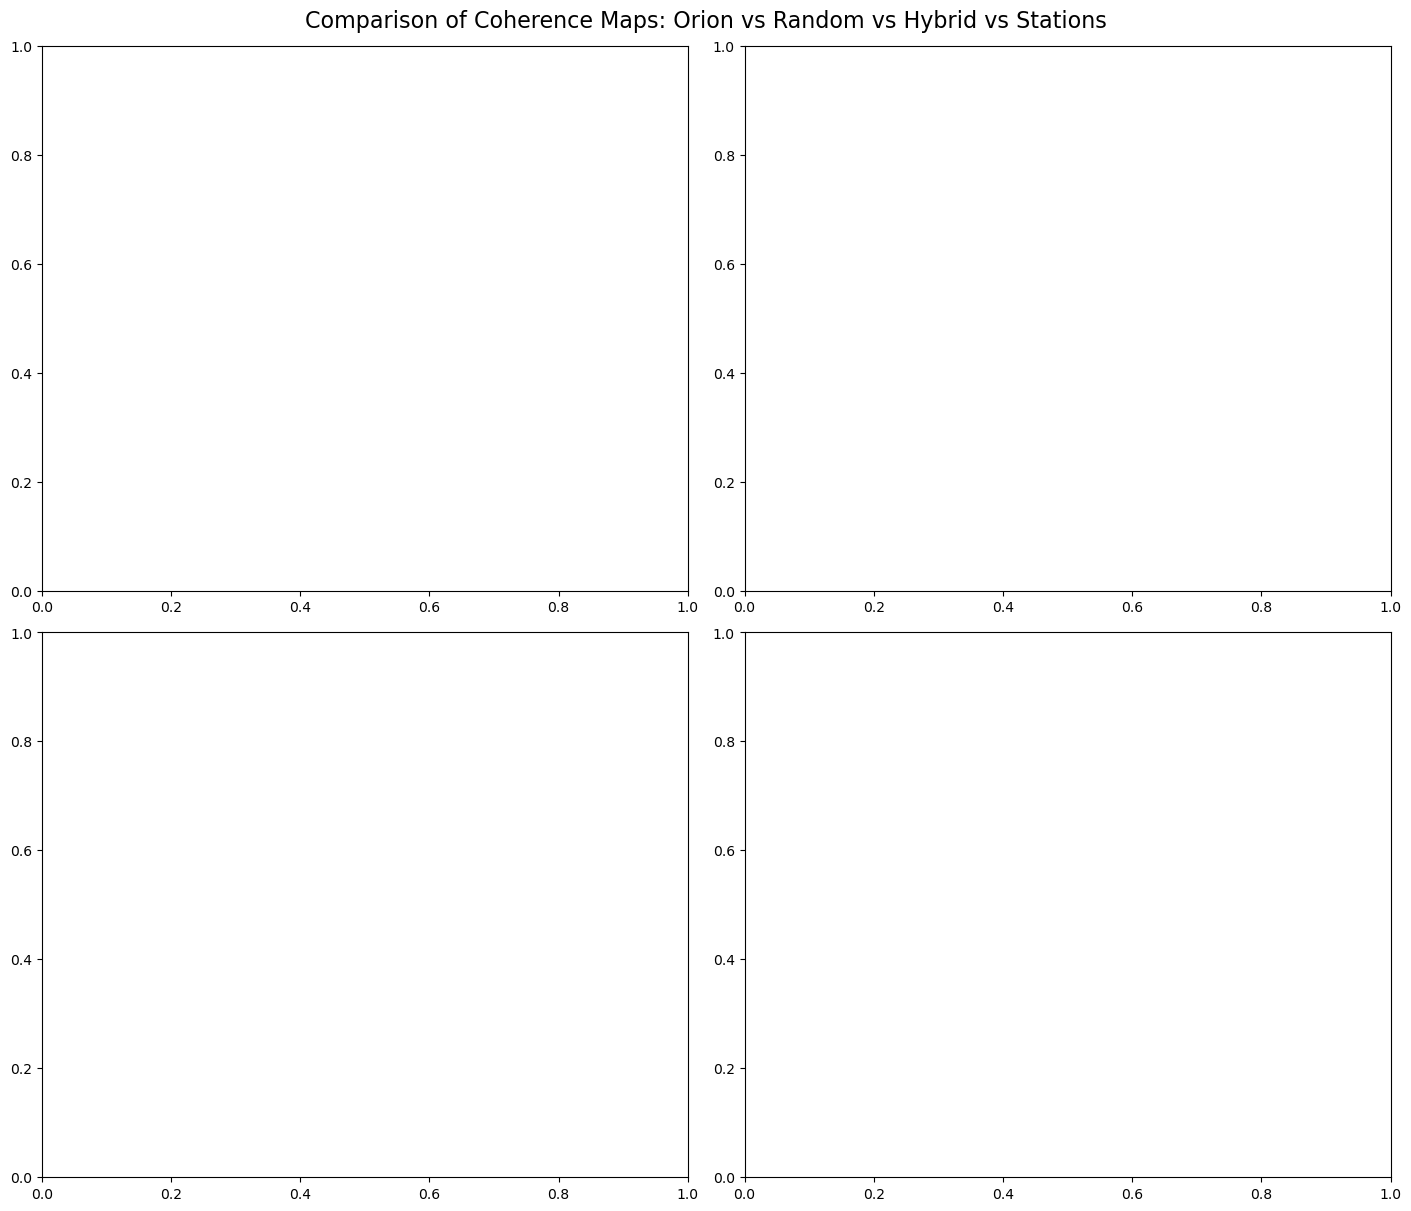

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt

# --- Reference Coordinates ---
ref_lat = 38.10
ref_lon = 20.20

# --- DAS Hybrid Geometry ---
das_hyb = {
    "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
    "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
    "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
    "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
    "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
    "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
    "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
    "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
}

# --- Grid Parameters ---
nx = ny = nz = 151
dx = dz = 0.5

cartesian_grid_x, cartesian_grid_y = np.meshgrid(np.linspace(0, 75.5, nx), np.linspace(0, 75.5, ny))
lat_range = (ref_lat, ref_lat + nx * dx / 111)
lon_range = (ref_lon, ref_lon + ny * dx / (111 * np.cos(np.radians(ref_lat))))

# --- Event List ---
events = {
    'cluster': (38.4140, 20.461, 14.5),
}

# --- Data Roots ---
base_dirs = {
    "Orion": ("/home/emanuele/data/emanuele/loki-das/cefalonia/output_prova_low_srn_OS/kef_0380/fiber_orion", "fiber_orion.loc", "fiber"),
    "Random": ("/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2_gilbert/kef0187/fiber_uniform","fiber_uniform.loc", "fiber"),
    "Hybrid_gilbert": ("/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2_gilbert/kef0187/hybrid_gilbert","hybrid_gilbert.loc", "hybrid"),      # <-- Add path to Hybrid results
    "Stations": ("/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2_gilbert/kef0187/stations", "stations.loc", "stations"),  # <-- Add path to Stations results
}


def select_highest_coherence_file(folder, loc_filename, npy_suffix):
    loc_file = os.path.join(folder, loc_filename)
    if not os.path.isfile(loc_file):
        raise FileNotFoundError(f"Missing .loc file: {loc_file}")

    catalog = np.loadtxt(loc_file)
    if catalog.ndim == 1:
        catalog = catalog[np.newaxis, :]

    coherence = catalog[:, 4]
    max_idx = np.argmax(coherence)

    npy_file = os.path.join(folder, f"corrmatrix_trial_{max_idx}_{npy_suffix}.npy")
    if not os.path.isfile(npy_file):
        raise FileNotFoundError(f"Missing .npy file: {npy_file}")

    return npy_file


# --- Plotting Comparison ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.flatten()

for ax, (label, (base_dir, loc_file, npy_suffix)) in zip(axes, base_dirs.items()):
    try:
        fiber_file = select_highest_coherence_file(base_dir, loc_file, npy_suffix)
        corrmatrix_das = np.load(fiber_file).reshape((nx, ny, nz))
    except Exception as e:
        print(f"Error loading coherence file for {label}: {e}")
        continue

    for name, eq_loc in events.items():
        print(f"\n--- Processing Event '{name}' for '{label}' ---")
        plot_fiber_only_map(
            ref_lat, ref_lon, das_hyb, eq_loc,
            corrmatrix_das, cartesian_grid_x, cartesian_grid_y,
            lat_range, lon_range, fiber_file,
            title=f"{label} - {name}", event_name=name,
            ax=ax
        )


fig.suptitle("Comparison of Coherence Maps: Orion vs Random vs Hybrid vs Stations", fontsize=16)
plt.show()

Error loading coherence file for Orion: Missing .loc file: /home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0140/fiber_orion/fiber/fiber.loc
Error loading coherence file for Random: Missing .loc file: /home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0140/fiber_random/fiber/fiber.loc
Error loading coherence file for Non-Selected: Missing .loc file: /home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0140/_non_selected/fiber/fiber.loc


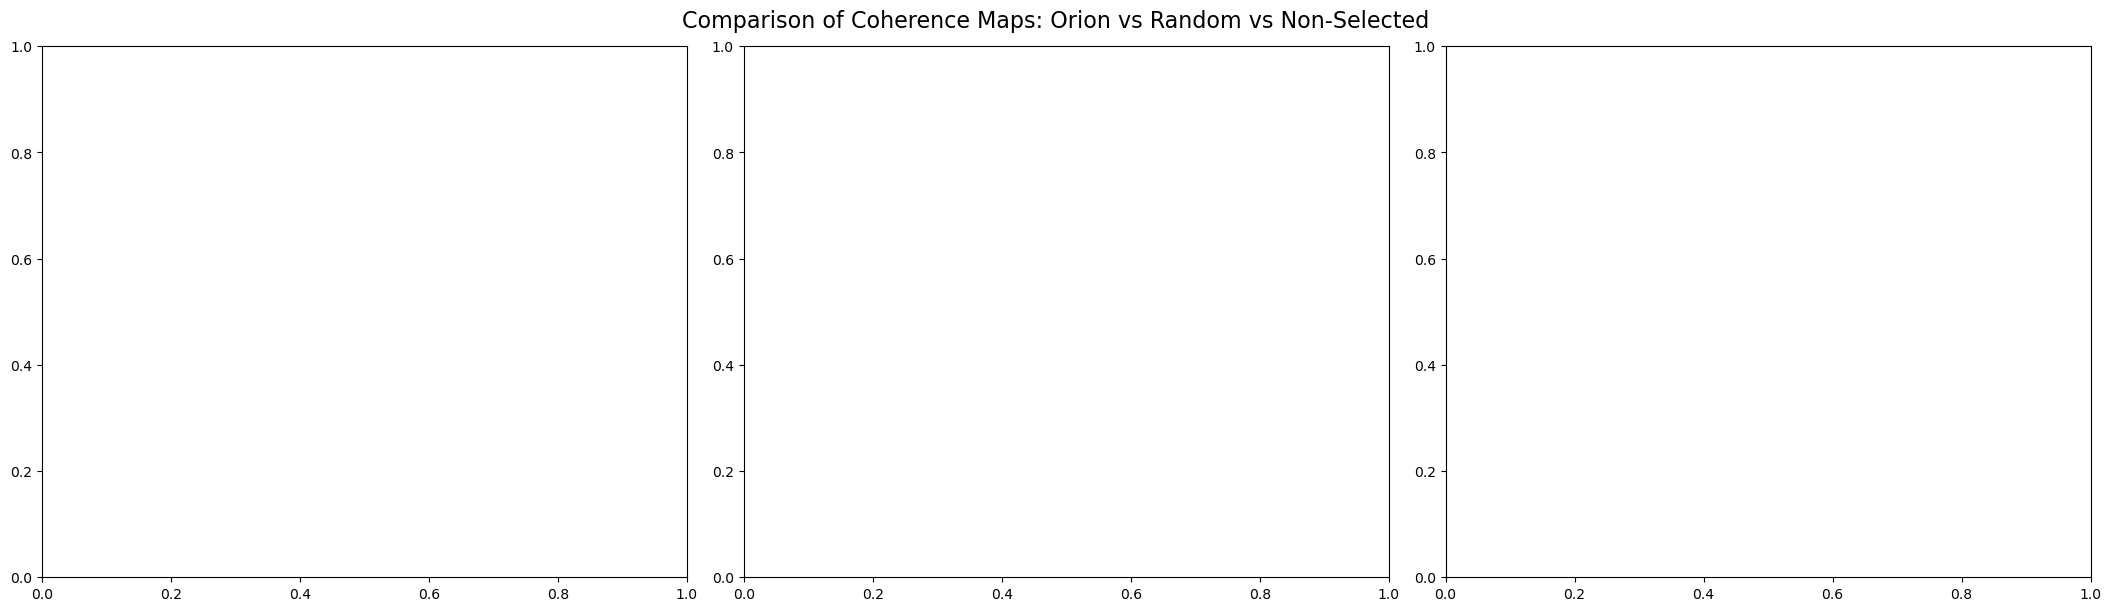

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt

# --- Reference Coordinates ---
#ref_lat = 38.10
#ref_lon = 20.20

# --- DAS Hybrid Geometry ---
#das_hyb = {
#    "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
#    "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
#    "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
#    "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
#    "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
#    "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
#    "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
#    "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
#}

# --- Grid Parameters ---
nx = ny = 201
nz = 101
dx = dz = 0.5

cartesian_grid_x, cartesian_grid_y = np.meshgrid(np.linspace(0, 100, nx), np.linspace(0, 100, ny))
lat_range = (ref_lat, ref_lat + nx * dx / 111)
lon_range = (ref_lon, ref_lon + ny * dx / (111 * np.cos(np.radians(ref_lat))))

# --- Event List ---
#events = {
#    'cluster': (38.3755, 20.4237, 14.5),
#}

# --- Event List ---
#events = {
#    'catalog': (38.4075, 20.4237, 14.5),
#}



# --- Event List ---
#events = {
#    'catalog': (38.4124,20.4601, 14.5),
#}

#events = {
#    'catalog': (38.399,20.4735,14.5),
#}


# --- Data Roots ---
base_dirs = {
    "Orion": "/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0140/fiber_orion",
    "Random": "/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0140/fiber_random",
    "Non-Selected": "/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0140/_non_selected"
}


def select_highest_coherence_file(folder):
    loc_file = os.path.join(folder, "fiber/fiber.loc")
    if not os.path.isfile(loc_file):
        raise FileNotFoundError(f"Missing .loc file: {loc_file}")

    catalog = np.loadtxt(loc_file)
    if catalog.ndim == 1:
        catalog = catalog[np.newaxis, :]

    coherence = catalog[:, 4]
    max_idx = np.argmax(coherence)

    npy_file = os.path.join(folder, f"fiber/corrmatrix_trial_{max_idx}_fiber.npy")
    if not os.path.isfile(npy_file):
        raise FileNotFoundError(f"Missing .npy file: {npy_file}")

    return npy_file


# --- Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(21, 6), constrained_layout=True)

# --- Loop over each data version ---
for i, (label, base_dir) in enumerate(base_dirs.items()):
    ax = axes[i]
    try:
        fiber_file = select_highest_coherence_file(base_dir)
        corrmatrix_das = np.load(fiber_file).reshape((nx, ny, nz))
    except Exception as e:
        print(f"Error loading coherence file for {label}: {e}")
        continue

    for name, eq_loc in events.items():
        print(f"\n--- Processing Event '{name}' for '{label}' ---")
        plot_fiber_only_map(
            ref_lat, ref_lon, das_hyb, eq_loc,
            corrmatrix_das, cartesian_grid_x, cartesian_grid_y,
            lat_range, lon_range, fiber_file,
            title=f"{label} - {name}", event_name=name,
            ax=ax
        )

plt.suptitle("Comparison of Coherence Maps: Orion vs Random vs Non-Selected", fontsize=16)
plt.show()


Error loading coherence file for Orion: Missing .loc file: /home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0021/fiber_orion/fiber/fiber.loc
Error loading coherence file for Random: Missing .loc file: /home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0021/fiber_random/fiber/fiber.loc
Error loading coherence file for Non-Selected: Missing .loc file: /home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0021/_non_selected/fiber/fiber.loc
Error loading non-selected coherence file: Missing .loc file: /home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0021/fiber_orion/fiber/fiber.loc


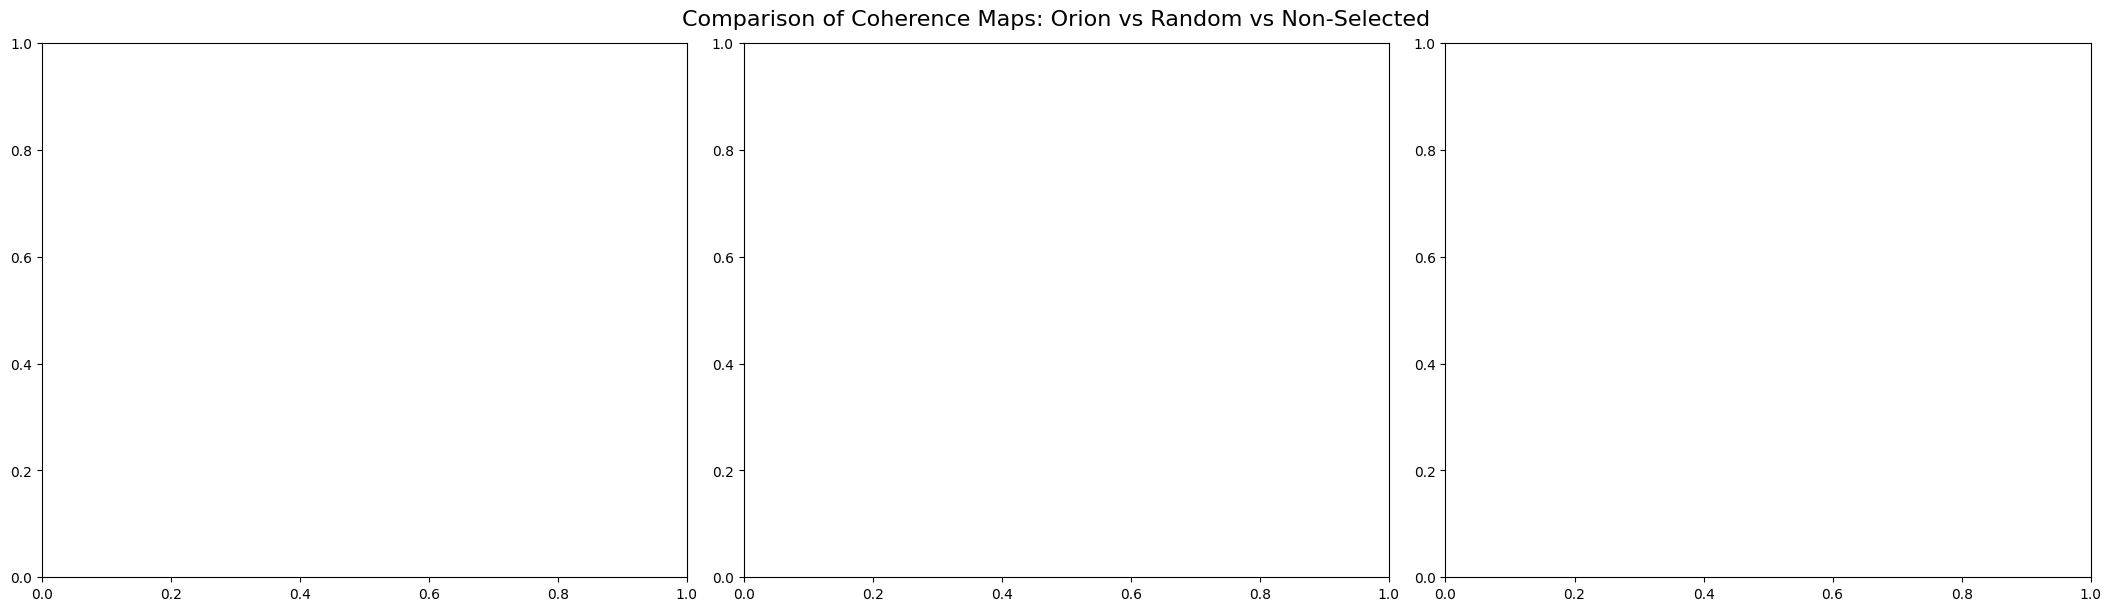

In [4]:
# --- Additional function to select non-maximal coherence file ---
def select_non_max_coherence_file(folder):
    loc_file = os.path.join(folder, "fiber/fiber.loc")
    if not os.path.isfile(loc_file):
        raise FileNotFoundError(f"Missing .loc file: {loc_file}")

    catalog = np.loadtxt(loc_file)
    if catalog.ndim == 1:
        catalog = catalog[np.newaxis, :]

    coherence = catalog[:, 4]
    if len(coherence) < 2:
        raise ValueError("Not enough coherence entries to select a non-maximal value.")

    sorted_indices = np.argsort(coherence)[::-1]  # Descending order
    second_idx = sorted_indices[1]

    npy_file = os.path.join(folder, f"fiber/corrmatrix_trial_{second_idx}_fiber.npy")
    if not os.path.isfile(npy_file):
        raise FileNotFoundError(f"Missing .npy file: {npy_file}")

    return npy_file

# --- Plotting Comparison with Third Panel ---
fig, axes = plt.subplots(1, 3, figsize=(21, 6), constrained_layout=True)

for i, (label, base_dir) in enumerate(base_dirs.items()):
    ax = axes[i]
    try:
        fiber_file = select_highest_coherence_file(base_dir)
        corrmatrix_das = np.load(fiber_file).reshape((nx, ny, nz))
    except Exception as e:
        print(f"Error loading coherence file for {label}: {e}")
        continue

    for name, eq_loc in events.items():
        print(f"\n--- Processing Event '{name}' for '{label}' ---")
        plot_fiber_only_map(
            ref_lat, ref_lon, das_hyb, eq_loc,
            corrmatrix_das, cartesian_grid_x, cartesian_grid_y,
            lat_range, lon_range, fiber_file,
            title=f"{label} - {name}", event_name=name,
            ax=ax
        )

# --- Third subplot for non-selected trial (from Orion, for example) ---
try:
    fiber_file_non_selected = select_non_max_coherence_file(base_dirs["Orion"])
    corrmatrix_das_non_selected = np.load(fiber_file_non_selected).reshape((nx, ny, nz))
    for name, eq_loc in events.items():
        print(f"\n--- Processing Event '{name}' for 'Orion - Non-Selected' ---")
        plot_fiber_only_map(
            ref_lat, ref_lon, das_hyb, eq_loc,
            corrmatrix_das_non_selected, cartesian_grid_x, cartesian_grid_y,
            lat_range, lon_range, fiber_file_non_selected,
            title=f"Orion - Non-Selected - {name}", event_name=name,
            ax=axes[2]
        )
except Exception as e:
    print(f"Error loading non-selected coherence file: {e}")

plt.suptitle("Comparison of Coherence Maps: Orion vs Random vs Non-Selected", fontsize=16)
plt.show()


In [11]:
def plot_fiber_only_map_with_maxima_no_cat(
    ref_lat, ref_lon, das_hyb,
    earthquake_location, cartesian_grid_x,
    cartesian_grid_y, lat_range, lon_range,
    parent_folder,
    title="Fiber Maxima Map",
    magnitude_threshold=0.0
):
    import os, glob, re
    from collections import defaultdict
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from scipy.ndimage import zoom
    from scipy.stats import gaussian_kde
    from matplotlib.lines import Line2D
    from matplotlib import cm
    from matplotlib.colors import Normalize
    from math import radians, sin, cos, sqrt, atan2
    from numpy import median

    # --- Parameters ---
    depth_scale = 0.5  # km per depth index (adjust if different)
    cmap = plt.cm.binary

    # --- Helpers ---
    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        R = 6371.0  # km
        lat = origin_lat + (y / R) * (180.0 / np.pi)
        lon = origin_lon + (x / (R * np.cos(np.radians(origin_lat)))) * (180.0 / np.pi)
        return lat, lon

    def distance_3d(lat1, lon1, depth1, lat2, lon2, depth2):
        """3D Euclidean distance (km) between two geocentric points using lat/lon/depth."""
        R = 6371.0
        lat1_r, lon1_r, lat2_r, lon2_r = map(radians, [lat1, lon1, lat2, lon2])
        x1 = (R - depth1) * cos(lat1_r) * cos(lon1_r)
        y1 = (R - depth1) * cos(lat1_r) * sin(lon1_r)
        z1 = (R - depth1) * sin(lat1_r)
        x2 = (R - depth2) * cos(lat2_r) * cos(lon2_r)
        y2 = (R - depth2) * cos(lat2_r) * sin(lon2_r)
        z2 = (R - depth2) * sin(lat2_r)
        return sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2 + (z1 - z2) ** 2)

    def collect_refined_max_locations_for_variant(parent_folder, event_id, variant_folder_name):
        """
        Returns list of tuples:
          (lat_max, lon_max, depth_cxz_km, depth_cyz_km)
        where depth_* are computed from CXZ and CYZ maxima (converted with depth_scale).
        """
        event_path = os.path.join(parent_folder, event_id, variant_folder_name)
        results = []
        nx, ny = cartesian_grid_x.shape

        if not os.path.isdir(event_path):
            return results

        npy_files = glob.glob(os.path.join(event_path, "corrmatrix_trial_*_fiber.npy"))
        for file in npy_files:
            try:
                corrmatrix_das = np.load(file)
                total_size = corrmatrix_das.size
                if total_size % (nx * ny) != 0:
                    continue

                nz = total_size // (nx * ny)
                corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                # normalize safely
                max_val = np.nanmax(corrmatrix)
                if max_val == 0 or np.isnan(max_val):
                    continue
                corrmatrix = corrmatrix / max_val

                # --- XY coarse + refine ---
                CXY = np.max(corrmatrix, axis=2).T  # shape (ny, nx)
                coarse_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)

                ws = 10
                i_min = max(coarse_idx[0] - ws, 0)
                i_max = min(coarse_idx[0] + ws + 1, CXY.shape[0])
                j_min = max(coarse_idx[1] - ws, 0)
                j_max = min(coarse_idx[1] + ws + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zf = 10
                CXY_fine = zoom(CXY_local, zf, order=3)
                x_fine = zoom(x_local, zf, order=1)
                y_fine = zoom(y_local, zf, order=1)

                fine_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)
                x_max = x_fine[fine_idx]
                y_max = y_fine[fine_idx]
                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)

                # --- Depth from CXZ and CYZ maxima ---
                # CXZ: max along Y => shape (nx, nz)
                CXZ = np.max(corrmatrix, axis=1)
                # CYZ: max along X => shape (ny, nz)
                CYZ = np.max(corrmatrix, axis=0)

                # locate depth index of maxima
                idx_cxz = np.nanargmax(CXZ)
                # np.unravel_index to get (ix, iz)
                ix_cxz, iz_cxz = np.unravel_index(idx_cxz, CXZ.shape)
                iy_cyz, iz_cyz = np.unravel_index(np.nanargmax(CYZ), CYZ.shape)

                depth_cxz_km = iz_cxz * depth_scale
                depth_cyz_km = iz_cyz * depth_scale

                results.append((lat_max, lon_max, depth_cxz_km, depth_cyz_km))

            except Exception as e:
                # skip problematic files but keep processing
                print(f"Skipping file {file}: {e}")
                continue

        return results

    def plot_50pct_contour(ax, coords, color, label):
        """Plot 50% KDE contour and return a legend proxy Line2D or None."""
        if len(coords) < 5:
            return None
        arr = np.array(coords).T  # shape (2, N) with [lon, lat]
        try:
            kde = gaussian_kde(arr)
        except Exception:
            return None
        x_min, x_max = arr[0].min(), arr[0].max()
        y_min, y_max = arr[1].min(), arr[1].max()

        # small padding
        dx = (x_max - x_min) * 0.1 if x_max > x_min else 0.01
        dy = (y_max - y_min) * 0.1 if y_max > y_min else 0.01
        xgrid, ygrid = np.mgrid[x_min - dx:x_max + dx:300j, y_min - dy:y_max + dy:300j]
        grid_coords = np.vstack([xgrid.ravel(), ygrid.ravel()])
        kde_vals = kde(grid_coords).reshape(xgrid.shape)

        # find contour level for 50% probability mass
        vals_sorted = np.sort(kde_vals.ravel())[::-1]
        cumsum = np.cumsum(vals_sorted)
        cumsum /= cumsum[-1]
        idx = np.searchsorted(cumsum, 0.5)
        if idx >= len(vals_sorted):
            level = vals_sorted[-1]
        else:
            level = vals_sorted[idx]

        cs = ax.contour(xgrid, ygrid, kde_vals, levels=[level], colors=[color],
                        linestyles='dashed', linewidths=4, alpha=0.8)
        return Line2D([0], [0], color=color, lw=2, label=label)

    # --- Read catalog ---
    catalog_path = os.path.join(parent_folder, 'catalog_17072025.csv')
    catalog_df = pd.read_csv(catalog_path)
    catalog_df['evid'] = catalog_df['evid'].astype(str)
    magnitude_dict = dict(zip(catalog_df['evid'], catalog_df['ML']))
    lat_dict = dict(zip(catalog_df['evid'], catalog_df['latitude']))
    lon_dict = dict(zip(catalog_df['evid'], catalog_df['longitude']))
    depth_dict = dict(zip(catalog_df['evid'], catalog_df['depth']))

    # --- event folders ---
    event_ids = [f for f in os.listdir(parent_folder)
                 if os.path.isdir(os.path.join(parent_folder, f)) and re.match(r'^kef\d+', f)]

    def marker_size_from_magnitude(mag, base_size=5, scale_factor=25):
        return base_size + scale_factor * mag

    # --- Collect detections and distances ---
    orion_points = []    # list of dicts: {lon, lat, depth, size, event_id}
    uniform_points = []
    per_event_orion_depths = defaultdict(list)
    per_event_uniform_depths = defaultdict(list)
    orion_distances = []
    uniform_distances = []
    orion_coords = []
    uniform_coords = []
    catalog_coords = []
    shown_event_ids = set()

    for event_id in event_ids:
        mag = magnitude_dict.get(event_id, None)
        if mag is None or mag < magnitude_threshold:
            continue
        shown_event_ids.add(event_id)

        cat_lat = lat_dict.get(event_id, None)
        cat_lon = lon_dict.get(event_id, None)
        cat_depth = depth_dict.get(event_id, None)
        # skip if catalog lacks geometry (we still might want to contour later, but distances require coords)
        if cat_lat is None or cat_lon is None or cat_depth is None:
            # still try to collect detections for contours
            cat_valid = False
        else:
            cat_valid = True
            catalog_coords.append((cat_lon, cat_lat))

        ms = marker_size_from_magnitude(mag)

        # UNIFORM detections
        uniform_locs = collect_refined_max_locations_for_variant(parent_folder, event_id, 'fiber_uniform')
        for lat, lon, depth_cxz_km, depth_cyz_km in uniform_locs:
            depth_est = 0.5 * (depth_cxz_km + depth_cyz_km)
            uniform_points.append({'lon': lon, 'lat': lat, 'depth': depth_est, 'size': ms, 'event_id': event_id})
            uniform_coords.append((lon, lat))
            per_event_uniform_depths[event_id].append(depth_est)
            if cat_valid:
                uniform_distances.append(distance_3d(cat_lat, cat_lon, cat_depth, lat, lon, depth_est))

        # ORION detections
        orion_locs = collect_refined_max_locations_for_variant(parent_folder, event_id, 'fiber_orion')
        for lat, lon, depth_cxz_km, depth_cyz_km in orion_locs:
            depth_est = 0.5 * (depth_cxz_km + depth_cyz_km)
            orion_points.append({'lon': lon, 'lat': lat, 'depth': depth_est, 'size': ms, 'event_id': event_id})
            orion_coords.append((lon, lat))
            per_event_orion_depths[event_id].append(depth_est)
            if cat_valid:
                orion_distances.append(distance_3d(cat_lat, cat_lon, cat_depth, lat, lon, depth_est))



    # --- Prepare figure with map, histogram, scatter (depth comparison) ---
    fig, (ax_map, ax_hist, ax_scatter) = plt.subplots(3, 1, figsize=(8, 14),
                                                     gridspec_kw={'height_ratios': [2.5, 1, 1]},
                                                     dpi=300)
    # --- Map base ---
    m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='f', ax=ax_map)
    m.drawcoastlines()
    m.drawcountries()
    m.fillcontinents(color='lightgray', lake_color='whitesmoke')
    m.drawmapboundary(fill_color='whitesmoke')
    # optional grid
    try:
        m.drawparallels(np.arange(lat_range[0], lat_range[1] + 0.01, 0.1), labels=[1, 0, 0, 0], fontsize=8)
        m.drawmeridians(np.arange(lon_range[0], lon_range[1] + 0.01, 0.1), labels=[0, 0, 0, 1], fontsize=8)
    except Exception:
        pass

    # --- Single depth color scale (based on all detected depths) ---
    all_depths = [p['depth'] for p in orion_points] + [p['depth'] for p in uniform_points]

    norm = Normalize(vmin=0, vmax=10)


    if uniform_points:
        xs = [p['lon'] for p in uniform_points]
        ys = [p['lat'] for p in uniform_points]
        depths = [p['depth'] for p in uniform_points]
        sizes = [p['size'] for p in uniform_points]
        sc_uniform = ax_map.scatter(xs, ys, c=depths, cmap=cmap, norm=norm,
                                    s=sizes, marker='o', edgecolors='k', linewidths=0.4,
                                    alpha=0.5, label='Uniform')
    else:
        sc_uniform = None


    # --- Plot ORION and UNIFORM as two different markers but same colormap (depth-coded) ---
    if orion_points:
        xs = [p['lon'] for p in orion_points]
        ys = [p['lat'] for p in orion_points]
        depths = [p['depth'] for p in orion_points]
        sizes = [p['size'] for p in orion_points]
        sc_orion = ax_map.scatter(xs, ys, c=depths, cmap=cmap, norm=norm,
                                  s=sizes, marker='*', edgecolors='k', linewidths=0.4,
                                  alpha=0.5, label='ORION')
    else:
        sc_orion = None

    # --- DAS fiber overlay (if available) ---
    das_csv_path = "/home/emanuele/data/emanuele/loki-das/cefalonia/geometry"
    try:
        if os.path.isdir(das_csv_path):
            for file in os.listdir(das_csv_path):
                if file.endswith(".csv"):
                    df_das = pd.read_csv(os.path.join(das_csv_path, file))
                    if "latitude" in df_das.columns and "longitude" in df_das.columns:
                        sampled_df = df_das.iloc[::100]
                        ax_map.scatter(sampled_df["longitude"], sampled_df["latitude"], marker='^',
                                       color='darkorange', linewidths=0.6, edgecolor='k', s=25, alpha=0.9,
                                       label="DAS fiber")
                    break
    except Exception as e:
        print(f"Error loading DAS CSV: {e}")

    # --- Single colorbar for depth ---
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])  # for colorbar
    cbar = fig.colorbar(sm, ax=ax_map, orientation="vertical", fraction=0.035, pad=0.02)
    cbar.set_label("Estimated depth (km)")

    ax_map.set_title(title, fontsize=14)

    # --- 50% KDE contours (ORION, UNIFORM, catalog) ---
    legend_proxies = []
    proxy = plot_50pct_contour(ax_map, orion_coords, 'darkred', 'ORION 50% contour')
    if proxy:
        legend_proxies.append(proxy)
    proxy = plot_50pct_contour(ax_map, uniform_coords, 'teal', 'UNIFORM 50% contour')
    if proxy:
        legend_proxies.append(proxy)
    proxy = plot_50pct_contour(ax_map, catalog_coords, 'black', 'Catalog 50% contour')


    # --- Legend assembly: avoid duplicates ---
    handles, labels = ax_map.get_legend_handles_labels()
    handles.extend(legend_proxies)
    labels.extend([p.get_label() for p in legend_proxies])

    # add sample magnitude-size legend entries
    sample_mags = [0.5, 1.0, 2.0]
    size_handles = [plt.scatter([], [], s=marker_size_from_magnitude(m), color='gray', alpha=0.6)
                    for m in sample_mags]
    size_labels = [f"ML {m}" for m in sample_mags]

    handles.extend(size_handles)
    labels.extend(size_labels)

    # deduplicate legend entries
    unique = dict(zip(labels, handles))
    ax_map.legend(unique.values(), unique.keys(), loc='lower right', fontsize='small', frameon=True)

    # --- HISTOGRAM of 3D distances from catalog ---
    ax_hist.grid(True, alpha=0.2)
    if len(orion_distances) + len(uniform_distances) > 0:
        maxd = max(orion_distances + uniform_distances + [1.0])
        bins = np.linspace(0, maxd * 1.05, 100)
        if orion_distances:
            ax_hist.hist(orion_distances, bins=bins, alpha=0.6, color='darkred',
                         label=f'ORION (median {median(orion_distances):.2f} km)')
            ax_hist.axvline(median(orion_distances), color='darkred', linestyle='--')
        if uniform_distances:
            ax_hist.hist(uniform_distances, bins=bins, alpha=0.6, color='teal',
                         label=f'UNIFORM (median {median(uniform_distances):.2f} km)')
            ax_hist.axvline(median(uniform_distances), color='teal', linestyle='--')
        ax_hist.set_xlabel("3D distance from catalog location (km)")
        ax_hist.set_ylabel("Count")
        ax_hist.legend(fontsize='small')
    else:
        ax_hist.text(0.5, 0.5, "No distance data to plot", ha='center', va='center')
        ax_hist.set_axis_off()

    # --- Scatter: median depth per event (UNIFORM on x, ORION on y) ---
    paired_orion_medians, paired_uniform_medians, paired_event_ids = [], [], []
    for eid in sorted(shown_event_ids):
        if per_event_orion_depths.get(eid) and per_event_uniform_depths.get(eid):
            paired_orion_medians.append(median(per_event_orion_depths[eid]))
            paired_uniform_medians.append(median(per_event_uniform_depths[eid]))
            paired_event_ids.append(eid)

    if paired_orion_medians and paired_uniform_medians:
        x = np.array(paired_uniform_medians)
        y = np.array(paired_orion_medians)
        ax_scatter.scatter(x, y, marker='o', edgecolor='k', alpha=0.8)
        mx = max(np.nanmax(x), np.nanmax(y))
        ax_scatter.plot([0, mx * 1.05], [0, mx * 1.05], 'k--', lw=1)
        ax_scatter.set_xlabel("UNIFORM median depth (km)")
        ax_scatter.set_ylabel("ORION median depth (km)")
        ax_scatter.set_title("Event-level median depth comparison (ORION vs UNIFORM)")
        ax_scatter.grid(True, alpha=0.2)
    else:
        ax_scatter.text(0.5, 0.5, "Not enough paired events for depth comparison", ha='center', va='center')
        ax_scatter.set_axis_off()

    plt.tight_layout()
    outname = "orion_uniform_map_hist_scatter.pdf"
    fig.savefig(outname, bbox_inches="tight")
    plt.show()
    print(f"Saved {outname}")


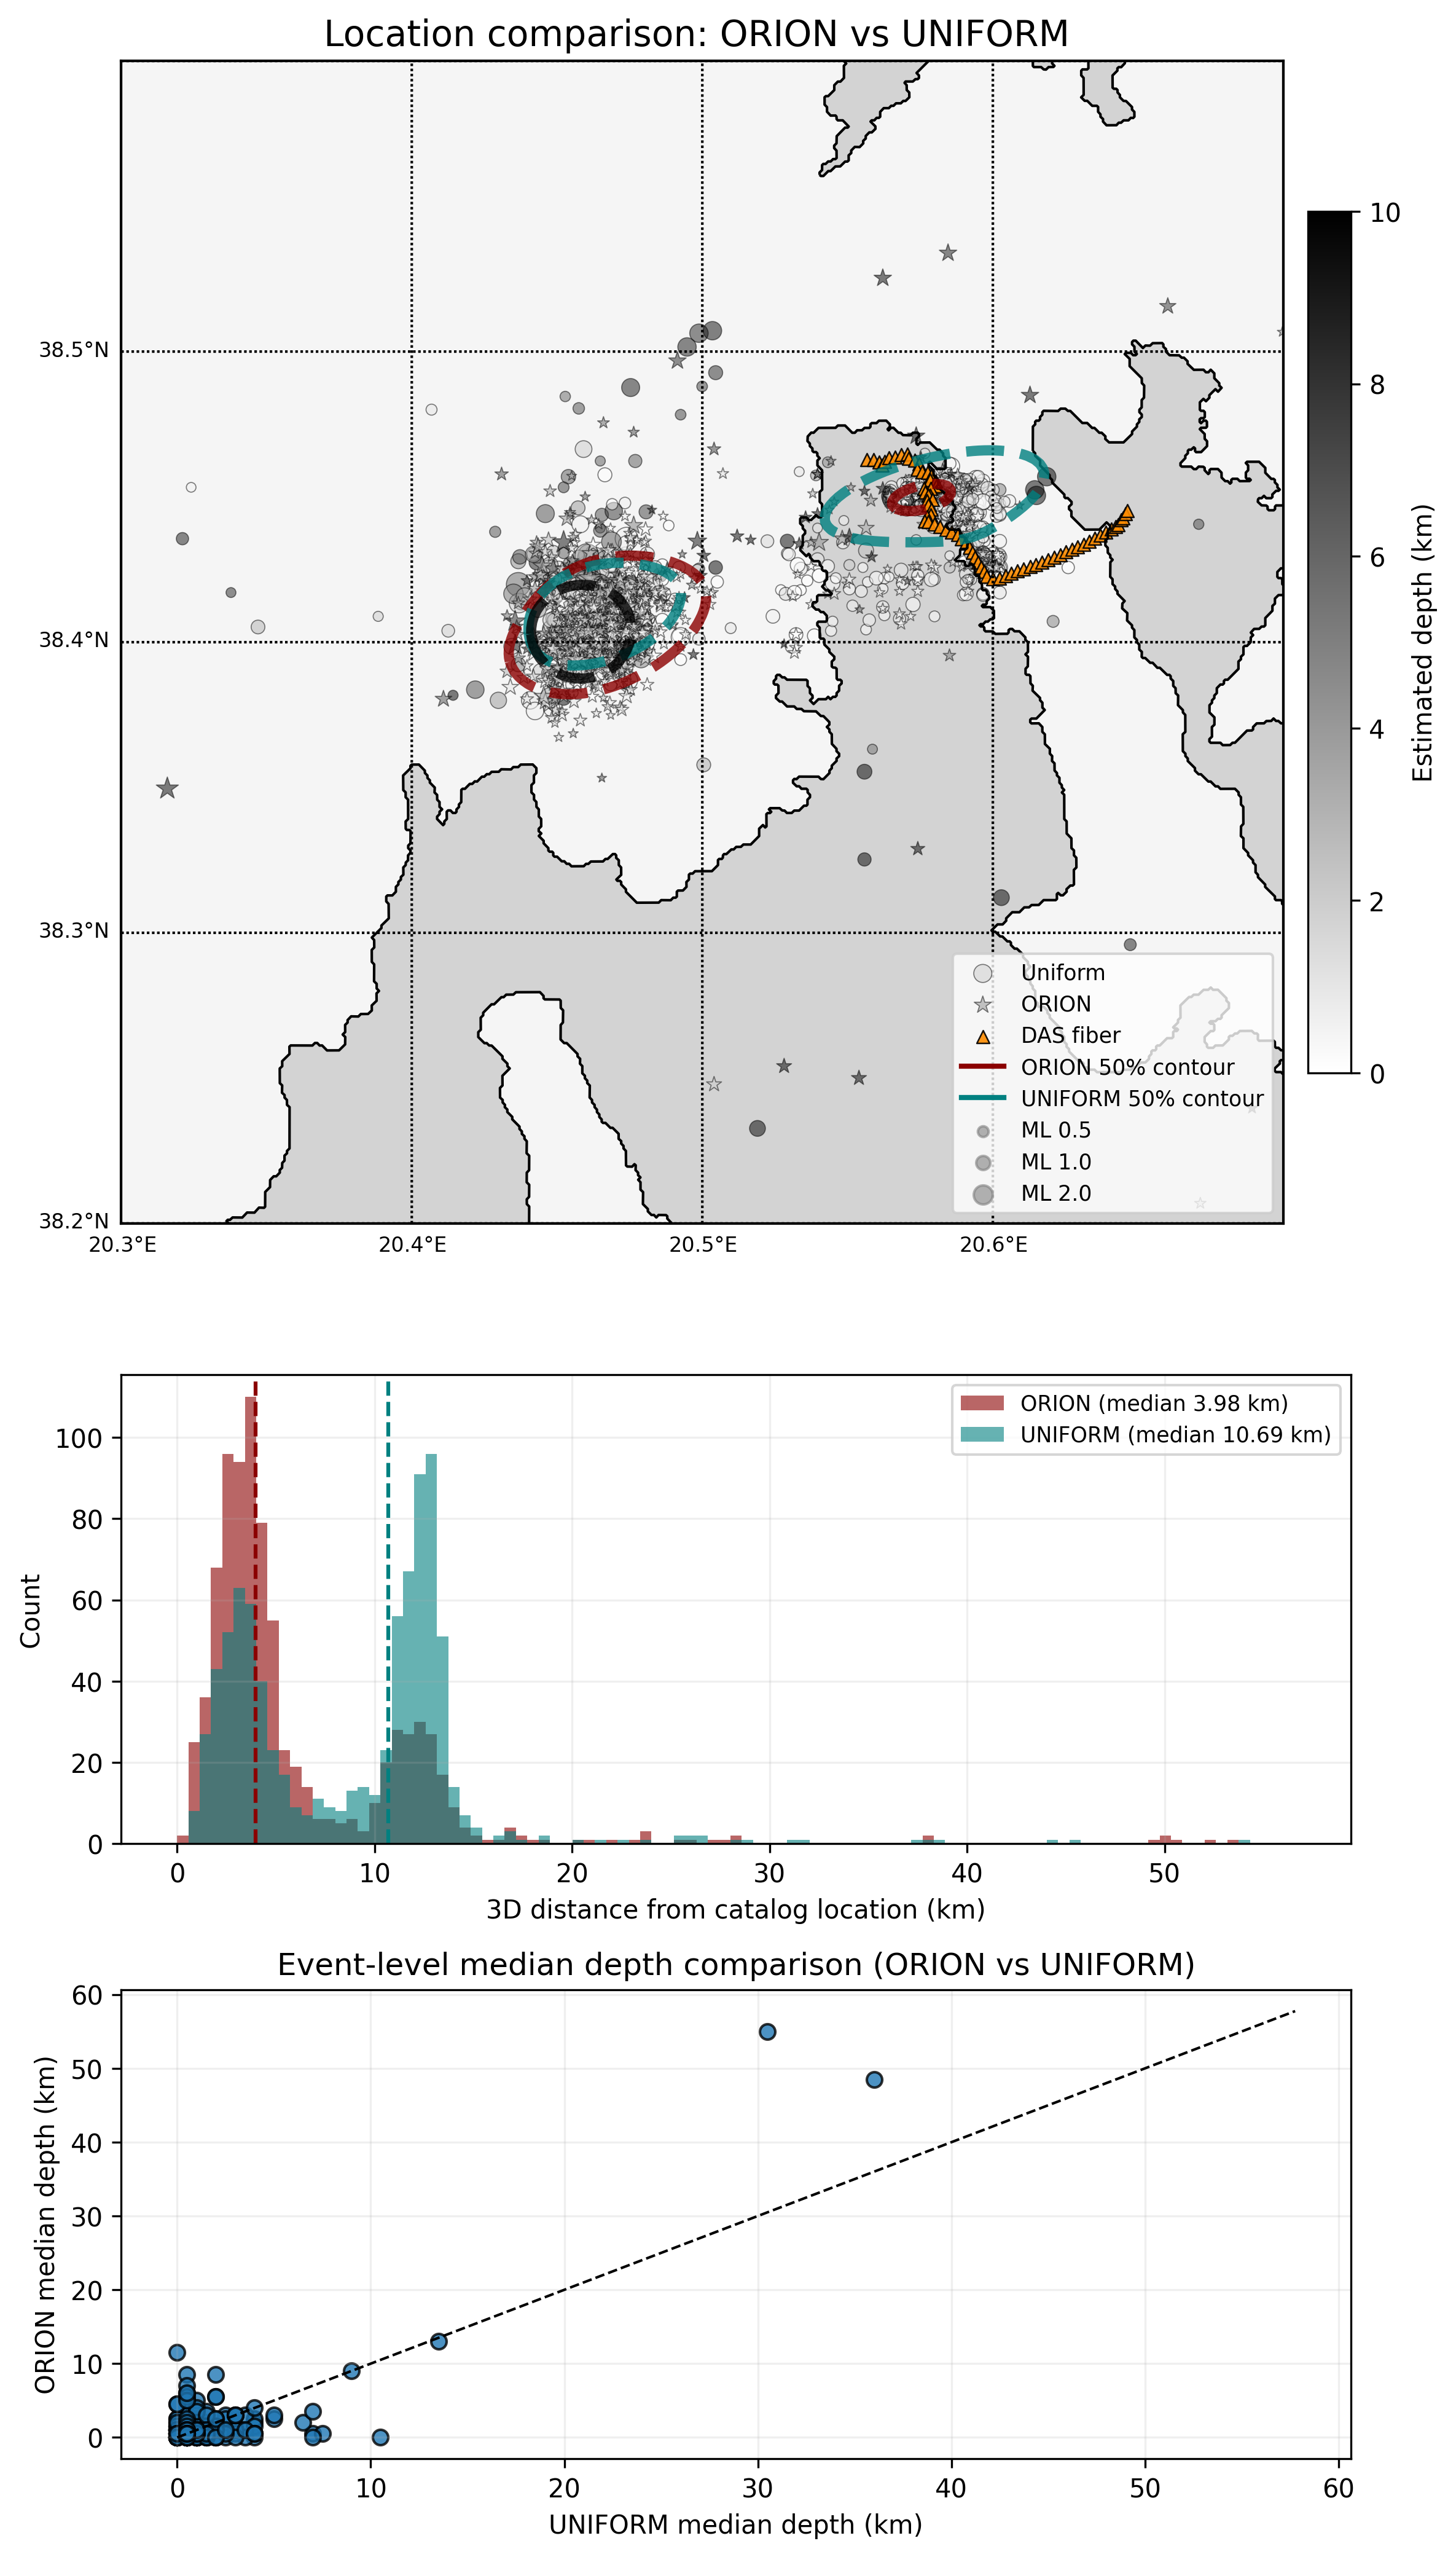

Saved orion_uniform_map_hist_scatter.pdf


In [12]:
plot_fiber_only_map_with_maxima_no_cat(
    ref_lat=38.10,
    ref_lon=20.20,
    das_hyb={
        "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
        "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
        "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
        "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
        "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
        "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
        "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
        "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
    },
    earthquake_location=(38.40435, 20.45875),
    cartesian_grid_x=cartesian_grid_x,
    cartesian_grid_y=cartesian_grid_y,
    lat_range=(38.2, 38.6),
    lon_range=(20.3, 20.7),
    magnitude_threshold=0,
    parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/',
    title="Location comparison: ORION vs UNIFORM "
)


In [1]:
def plot_fiber_only_map_with_maxima_no_cat(ref_lat, ref_lon, das_hyb,
                                           earthquake_location, cartesian_grid_x,
                                           cartesian_grid_y, lat_range, lon_range,
                                           parent_folder,
                                           hybrid2_parent_folder,
                                           title="Fiber Maxima Map",
                                           magnitude_threshold=0.0):

    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from scipy.ndimage import zoom
    import numpy as np
    import os, glob, re
    import pandas as pd
    from math import radians, sin, cos, sqrt, atan2
    from matplotlib.lines import Line2D
    import matplotlib.colors as mcolors
    import colorsys
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize

    # ==========================================================
    # DEPTH GRID
    # ==========================================================
    corr_shape_z = 120
    depths_km = np.linspace(0, 30, corr_shape_z)
    DEPTH_SAT_KM = 5.0

    # ==========================================================
    # COLOR SHADING BY DEPTH
    # ==========================================================
    def shade_by_depth(base_color, depth):
        rgb = mcolors.to_rgb(base_color)
        h, l, s = colorsys.rgb_to_hls(*rgb)
        depth_clip = min(depth, DEPTH_SAT_KM)
        depth_norm = depth_clip / DEPTH_SAT_KM
        l_new = 0.85 - 0.5 * depth_norm
        return colorsys.hls_to_rgb(h, l_new, s)

    # ==========================================================
    # SPARSE NPZ LOADER
    # ==========================================================
    def load_sparse_corrmatrix(file):
        data = np.load(file)
        corr = np.zeros(tuple(data["shape"]), dtype=np.float32)
        indices = data["indices"]
        values = data["values"]

        if indices.ndim == 2 and indices.shape[1] == 3:
            corr[indices[:, 0], indices[:, 1], indices[:, 2]] = values
        else:
            corr[np.unravel_index(indices, corr.shape)] = values

        return corr

    # ==========================================================
    # GEOMETRY
    # ==========================================================
    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        R = 6371.0
        lat = origin_lat + (y / R) * (180 / np.pi)
        lon = origin_lon + (x / (R * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371.0
        dlat = radians(lat2 - lat1)
        dlon = radians(lon2 - lon1)
        a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        return R * c

    # ==========================================================
    # SUB-SAMPLE DEPTH INTERPOLATION
    # ==========================================================
    def refine_depth_parabolic(corr, z_idx, i, j):
        if z_idx <= 0 or z_idx >= corr.shape[2] - 1:
            return float(z_idx)

        v_m1 = corr[i, j, z_idx - 1]
        v_0  = corr[i, j, z_idx]
        v_p1 = corr[i, j, z_idx + 1]

        denom = v_m1 - 2 * v_0 + v_p1
        if denom == 0 or not np.isfinite(denom):
            return float(z_idx)

        delta = 0.5 * (v_m1 - v_p1) / denom
        return float(z_idx) + delta

    # ==========================================================
    # MAXIMA EXTRACTION
    # ==========================================================
    def collect_sparse_max_locations(event_path, pattern):
        out = []
        files = glob.glob(os.path.join(event_path, pattern))
        for file in files:
            try:
                corr = load_sparse_corrmatrix(file)
                corr /= np.nanmax(corr)

                CXY = np.nanmax(corr, axis=2).T
                ZIDX = np.nanargmax(corr, axis=2).T

                w = 15
                i0, j0 = np.unravel_index(np.nanargmax(CXY), CXY.shape)

                CXY_l = CXY[i0-w:i0+w+1, j0-w:j0+w+1]
                Z_l = ZIDX[i0-w:i0+w+1, j0-w:j0+w+1]
                x_l = cartesian_grid_x[i0-w:i0+w+1, j0-w:j0+w+1]
                y_l = cartesian_grid_y[i0-w:i0+w+1, j0-w:j0+w+1]
                corr_l = corr[i0-w:i0+w+1, j0-w:j0+w+1, :]

                CXY_f = zoom(CXY_l, 25, order=3)
                Z_f = zoom(Z_l, 25, order=0)
                x_f = zoom(x_l, 25, order=1)
                y_f = zoom(y_l, 25, order=1)

                idx = np.unravel_index(np.nanargmax(CXY_f), CXY_f.shape)

                zi = int(Z_f[idx])
                z_ref = refine_depth_parabolic(
                    corr_l,
                    zi,
                    int(idx[0] / 25),
                    int(idx[1] / 25)
                )

                depth = np.interp(z_ref,
                                  np.arange(len(depths_km)),
                                  depths_km)

                lat, lon = cartesian_to_geographic(x_f[idx], y_f[idx], ref_lat, ref_lon)

                out.append((lat, lon, depth, x_f[idx], y_f[idx]))
            except Exception:
                continue

        return out

    def collect_variant(parent, evid, folder):
        return collect_sparse_max_locations(
            os.path.join(parent, evid, folder),
            "corrmatrix_sparse*_*.npz"
        )

    def collect_hybrid(parent, evid):
        return collect_sparse_max_locations(
            os.path.join(parent, evid, "hybrid_gilbert"),
            "corrmatrix_sparse*_hybrid.npz"
        )

    # ==========================================================
    # SUM OF NORMALIZED MATRICES (ORION + STATIONS)
    # ==========================================================
    def collect_summed_max_locations(parent, evid, folder1, folder2):
        out = []
        files1 = sorted(glob.glob(os.path.join(parent, evid, folder1, "corrmatrix_sparse*_*.npz")))
        files2 = sorted(glob.glob(os.path.join(parent, evid, folder2, "corrmatrix_sparse*_*.npz")))

        for f1, f2 in zip(files1, files2):
            try:
                corr1 = load_sparse_corrmatrix(f1)
                corr2 = load_sparse_corrmatrix(f2)

                corr1 /= np.nanmax(corr1) if np.nanmax(corr1) != 0 else 1
                corr2 /= np.nanmax(corr2) if np.nanmax(corr2) != 0 else 1

                corr_sum = corr1 + corr2
                corr_sum /= np.nanmax(corr_sum) if np.nanmax(corr_sum) != 0 else 1

                CXY = np.nanmax(corr_sum, axis=2).T
                ZIDX = np.nanargmax(corr_sum, axis=2).T

                w = 15
                i0, j0 = np.unravel_index(np.nanargmax(CXY), CXY.shape)

                CXY_l = CXY[i0-w:i0+w+1, j0-w:j0+w+1]
                Z_l = ZIDX[i0-w:i0+w+1, j0-w:j0+w+1]
                x_l = cartesian_grid_x[i0-w:i0+w+1, j0-w:j0+w+1]
                y_l = cartesian_grid_y[i0-w:i0+w+1, j0-w:j0+w+1]
                corr_l = corr_sum[i0-w:i0+w+1, j0-w:j0+w+1, :]

                CXY_f = zoom(CXY_l, 25, order=3)
                Z_f = zoom(Z_l, 25, order=0)
                x_f = zoom(x_l, 25, order=1)
                y_f = zoom(y_l, 25, order=1)

                idx = np.unravel_index(np.nanargmax(CXY_f), CXY_f.shape)

                zi = int(Z_f[idx])
                z_ref = refine_depth_parabolic(
                    corr_l,
                    zi,
                    int(idx[0] / 25),
                    int(idx[1] / 25)
                )

                depth = np.interp(z_ref,
                                  np.arange(len(depths_km)),
                                  depths_km)

                lat, lon = cartesian_to_geographic(x_f[idx], y_f[idx], ref_lat, ref_lon)

                out.append((lat, lon, depth, x_f[idx], y_f[idx]))
            except Exception:
                continue

        return out

    # ==========================================================
    # CATALOG
    # ==========================================================
    catalog_df = pd.read_csv(os.path.join(parent_folder, "catalog_17072025.csv"))
    catalog_df["evid"] = catalog_df["evid"].astype(str)
    magnitude = dict(zip(catalog_df["evid"], catalog_df["ML"]))

    event_ids = [e for e in os.listdir(parent_folder)
                 if os.path.isdir(os.path.join(parent_folder, e))
                 and re.match(r"^kef\d+", e)]

    def marker_size(m):
        return 1 + 20 * m

    # ==========================================================
    # DEPTH & XY STORAGE
    # ==========================================================
    data_by_network = {
        "stations": {"depth": [], "x": [], "y": []},
        "orion": {"depth": [], "x": [], "y": []},
        "summed": {"depth": [], "x": [], "y": []},
        "hybrid": {"depth": [], "x": [], "y": []},
    }

    # ==========================================================
    # MAP PLOTTING
    # ==========================================================
    fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=400)
    axes = axes.flatten()

    map_titles = [
        "Conventional network",
        "Fiber + ORION",
        "Summed network (ORION+Stations)",
        "Hybrid network",
    ]

    variants = [
        ("stations", "stations", "red", "Conventional network"),
        ("orion", "fiber_orion", "gold", "Fiber-only (ORION)"),
        ("summed", ("fiber_orion", "stations"), "darkorange", "Summed matrices"),
        ("hybrid", None, "darkorange", "Hybrid network"),
    ]

    das_path = "/home/emanuele/data/emanuele/loki-das/cefalonia/geometry"
    stations_csv = os.path.join(das_path, "stations.csv")

    for ax, title_txt, (key, folder, color, label) in zip(axes, map_titles, variants):

        m = Basemap(projection="cyl",
                    llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                    llcrnrlon=lon_range[0], urcrnrlon=lon_range[1],
                    resolution="f", ax=ax)

        m.drawcoastlines()
        m.drawcountries()
        m.fillcontinents(color="whitesmoke", lake_color="lightblue")
        m.drawmapboundary(fill_color="lightblue")
        m.drawparallels(np.arange(lat_range[0], lat_range[1]+0.01, 0.1),
                        labels=[1,0,0,0], fontsize=9)
        m.drawmeridians(np.arange(lon_range[0], lon_range[1]+0.01, 0.1),
                        labels=[0,0,0,1], fontsize=9)

        ax.set_title(title_txt, fontsize=11)

        if key in ["orion", "summed", "hybrid"]:
            for f in os.listdir(das_path):
                if f.endswith(".csv") and f != "stations.csv":
                    df = pd.read_csv(os.path.join(das_path, f))
                    ax.scatter(df.longitude[::100], df.latitude[::100],
                               marker="^", color="gold",
                               edgecolor="black", linewidths=0.1,
                               s=50, alpha=0.9, zorder=2)
                    break

        if key in ["stations", "hybrid", "summed"]:
            df = pd.read_csv(stations_csv)
            ax.scatter(df.longitude, df.latitude,
                       marker="^", color="darkred",
                       edgecolor="black", linewidths=2,
                       s=100, alpha=0.8, zorder=3)

        distances = []

        for evid in event_ids:
            mag = magnitude.get(evid)
            if mag is None or mag < magnitude_threshold:
                continue

            if key == "hybrid":
                pts = collect_hybrid(parent_folder, evid)
            elif key == "summed":
                pts = collect_summed_max_locations(parent_folder, evid, *folder)
            else:
                pts = collect_variant(parent_folder, evid, folder)

            for lat, lon, depth, x, y in pts:
                ax.scatter(lon, lat, s=marker_size(mag),
                           color=shade_by_depth(color, depth),
                           edgecolor="k", alpha=0.5, zorder=1)

                distances.append(
                    haversine(earthquake_location[0],
                              earthquake_location[1], lat, lon)
                )

                data_by_network[key]["depth"].append(depth)
                data_by_network[key]["x"].append(x)
                data_by_network[key]["y"].append(y)

        if distances:
            med = np.median(distances)
            ax.legend([Line2D([0], [0], marker="o", color="w",
                              markerfacecolor=color, markeredgecolor="k",
                              markersize=10)],
                      [f"{label}\n(median: {med:.1f} km)"],
                      loc="upper left", fontsize=10)

    # ==========================================================
    # DEPTH COLORBAR
    # ==========================================================
    sm = ScalarMappable(norm=Normalize(0, DEPTH_SAT_KM), cmap="gray_r")
    sm.set_array([])
    fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.06, label="Depth (km)")

    plt.tight_layout()
    plt.show()

    # ==========================================================
    # DEPTH HISTOGRAM + EASTING/ NORTHING VS DEPTH
    # ==========================================================
    fig2, axs = plt.subplots(3, 4, figsize=(18, 9), sharey='row')
    order = [
        ("stations", "Conventional"),
        ("orion", "Fiber ORION"),
        ("summed", "Summed network"),
        ("hybrid", "Hybrid"),
    ]

    for col, (key, title) in enumerate(order):
        depth_arr = np.array(data_by_network[key]["depth"])
        x_arr = np.array(data_by_network[key]["x"])
        y_arr = np.array(data_by_network[key]["y"])

        axs[0, col].hist(depth_arr, bins=np.linspace(0, 30, 31), color='gray', edgecolor='black')
        axs[0, col].axvline(DEPTH_SAT_KM, color='red', linestyle='--')
        axs[0, col].set_title(title)
        if col == 0:
            axs[0, col].set_ylabel('Count')
        axs[0, col].grid(alpha=0.3)

        axs[1, col].scatter(x_arr, depth_arr, s=10, color='blue', alpha=0.6)
        axs[1, col].invert_yaxis()
        if col == 0:
            axs[1, col].set_ylabel('Depth (km)')
        axs[1, col].set_xlabel('Easting (km)')
        axs[1, col].grid(alpha=0.3)

        axs[2, col].scatter(y_arr, depth_arr, s=10, color='green', alpha=0.6)
        axs[2, col].invert_yaxis()
        if col == 0:
            axs[2, col].set_ylabel('Depth (km)')
        axs[2, col].set_xlabel('Northing (km)')
        axs[2, col].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


In [5]:
def plot_fiber_only_map_with_maxima_no_cat(ref_lat, ref_lon, das_hyb,
                                           earthquake_location, cartesian_grid_x,
                                           cartesian_grid_y, lat_range, lon_range,
                                           parent_folder,
                                           hybrid2_parent_folder,
                                           title="Fiber Maxima Map",
                                           magnitude_threshold=0.0):

    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from scipy.ndimage import zoom
    import numpy as np
    import os, glob, re
    import pandas as pd
    from math import radians, sin, cos, sqrt, atan2
    from matplotlib.lines import Line2D
    import matplotlib.colors as mcolors
    import colorsys
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize

    # ==========================================================
    # DEPTH GRID
    # ==========================================================
    corr_shape_z = 120
    depths_km = np.linspace(0, 30, corr_shape_z)
    DEPTH_SAT_KM = 8.0

    # ==========================================================
    # COLOR SHADING BY DEPTH
    # ==========================================================
    def shade_by_depth(base_color, depth):
        rgb = mcolors.to_rgb(base_color)
        h, l, s = colorsys.rgb_to_hls(*rgb)
        depth_clip = min(depth, DEPTH_SAT_KM)
        depth_norm = depth_clip / DEPTH_SAT_KM
        l_new = 0.85 - 0.5 * depth_norm
        return colorsys.hls_to_rgb(h, l_new, s)

    # ==========================================================
    # SPARSE NPZ LOADER
    # ==========================================================
    def load_sparse_corrmatrix(file):
        data = np.load(file)
        corr = np.zeros(tuple(data["shape"]), dtype=np.float32)
        indices = data["indices"]
        values = data["values"]

        if indices.ndim == 2 and indices.shape[1] == 3:
            corr[indices[:, 0], indices[:, 1], indices[:, 2]] = values
        else:
            corr[np.unravel_index(indices, corr.shape)] = values

        return corr

    # ==========================================================
    # GEOMETRY
    # ==========================================================
    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        R = 6371.0
        lat = origin_lat + (y / R) * (180 / np.pi)
        lon = origin_lon + (x / (R * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371.0
        dlat = radians(lat2 - lat1)
        dlon = radians(lon2 - lon1)
        a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        return R * c

    # ==========================================================
    # MAXIMA EXTRACTION
    # ==========================================================
    def collect_sparse_max_locations(event_path, pattern):
        out = []
        files = glob.glob(os.path.join(event_path, pattern))
        for file in files:
            try:
                corr = load_sparse_corrmatrix(file)
                corr /= np.nanmax(corr)

                CXY = np.nanmax(corr, axis=2).T
                ZIDX = np.nanargmax(corr, axis=2).T

                w = 15
                i0, j0 = np.unravel_index(np.nanargmax(CXY), CXY.shape)

                CXY_l = CXY[i0-w:i0+w+1, j0-w:j0+w+1]
                Z_l = ZIDX[i0-w:i0+w+1, j0-w:j0+w+1]
                x_l = cartesian_grid_x[i0-w:i0+w+1, j0-w:j0+w+1]
                y_l = cartesian_grid_y[i0-w:i0+w+1, j0-w:j0+w+1]

                CXY_f = zoom(CXY_l, 50, order=3)
                Z_f = zoom(Z_l, 50, order=1)
                x_f = zoom(x_l, 50, order=1)
                y_f = zoom(y_l, 50, order=1)

                idx = np.unravel_index(np.nanargmax(CXY_f), CXY_f.shape)
                lat, lon = cartesian_to_geographic(x_f[idx], y_f[idx], ref_lat, ref_lon)
                depth = depths_km[min(int(Z_f[idx]), len(depths_km)-1)]

                out.append((lat, lon, depth, x_f[idx], y_f[idx]))
            except Exception:
                continue

        return out

    def collect_variant(parent, evid, folder):
        return collect_sparse_max_locations(
            os.path.join(parent, evid, folder),
            "corrmatrix_sparse*_*.npz"
        )

    def collect_hybrid(parent, evid):
        return collect_sparse_max_locations(
            os.path.join(parent, evid, "hybrid_gilbert"),
            "corrmatrix_sparse*_hybrid.npz"
        )

    # ==========================================================
    # SUM OF NORMALIZED MATRICES (ORION + STATIONS)
    # ==========================================================
    def collect_summed_max_locations(parent, evid, folder1, folder2):
        out = []
        files1 = sorted(glob.glob(os.path.join(parent, evid, folder1, "corrmatrix_sparse*_*.npz")))
        files2 = sorted(glob.glob(os.path.join(parent, evid, folder2, "corrmatrix_sparse*_*.npz")))

        for f1, f2 in zip(files1, files2):
            try:
                corr1 = load_sparse_corrmatrix(f1)
                corr2 = load_sparse_corrmatrix(f2)

                # normalize 0-1
                corr1 /= np.nanmax(corr1) if np.nanmax(corr1) != 0 else 1
                corr2 /= np.nanmax(corr2) if np.nanmax(corr2) != 0 else 1

                corr_sum = corr1 + corr2
                corr_sum /= np.nanmax(corr_sum) if np.nanmax(corr_sum) != 0 else 1

                CXY = np.nanmax(corr_sum, axis=2).T
                ZIDX = np.nanargmax(corr_sum, axis=2).T

                w = 15
                i0, j0 = np.unravel_index(np.nanargmax(CXY), CXY.shape)

                CXY_l = CXY[i0-w:i0+w+1, j0-w:j0+w+1]
                Z_l = ZIDX[i0-w:i0+w+1, j0-w:j0+w+1]
                x_l = cartesian_grid_x[i0-w:i0+w+1, j0-w:j0+w+1]
                y_l = cartesian_grid_y[i0-w:i0+w+1, j0-w:j0+w+1]

                CXY_f = zoom(CXY_l, 25, order=3)
                Z_f = zoom(Z_l, 25, order=3)
                x_f = zoom(x_l, 25, order=3)
                y_f = zoom(y_l, 25, order=3)

                idx = np.unravel_index(np.nanargmax(CXY_f), CXY_f.shape)
                lat, lon = cartesian_to_geographic(x_f[idx], y_f[idx], ref_lat, ref_lon)
                depth = depths_km[min(int(Z_f[idx]), len(depths_km)-1)]

                out.append((lat, lon, depth, x_f[idx], y_f[idx]))
            except Exception:
                continue

        return out

    # ==========================================================
    # CATALOG
    # ==========================================================
    catalog_df = pd.read_csv(os.path.join(parent_folder, "catalog_17072025.csv"))
    catalog_df["evid"] = catalog_df["evid"].astype(str)
    magnitude = dict(zip(catalog_df["evid"], catalog_df["ML"]))

    event_ids = [e for e in os.listdir(parent_folder)
                 if os.path.isdir(os.path.join(parent_folder, e))
                 and re.match(r"^kef\d+", e)]

    def marker_size(m, smin=2, smax=50):
        m = np.asarray(m, dtype=float)

        # shift to crush low magnitudes
        s = 5 * (10 ** (0.6 * (m - 1.5)))

        return np.clip(s, smin, smax)


    #def marker_size(m, smin=0.1, smax=30):
        #m = np.array(m)
#
#        s = 10 ** (m - 3)        # shift scale hard left
#        s = np.clip(s, 0, None)
#        s = smin + (smax - smin) * (s / s.max())
#        return s


    # ==========================================================
    # DEPTH & XY STORAGE
    # ==========================================================
    data_by_network = {
        "stations": {"depth": [], "x": [], "y": [], "mag": []},
        "orion": {"depth": [], "x": [], "y": [], "mag": []},
        "summed": {"depth": [], "x": [], "y": [], "mag": []},
        "hybrid": {"depth": [], "x": [], "y": [], "mag": []},
    }

    # ==========================================================
    # MAP PLOTTING
    # ==========================================================
    fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=400)


    from matplotlib.colors import Normalize, LinearSegmentedColormap
    from matplotlib.cm import ScalarMappable
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    def depth_colormap(base_color, n=256):
        depths = np.linspace(0, DEPTH_SAT_KM, n)
        colors = [shade_by_depth(base_color, d) for d in depths]
        return LinearSegmentedColormap.from_list(
            f"depth_{base_color}", colors
        )


    
    
    axes = axes.flatten()

    map_titles = [
        "Conventional network",
        "Fiber + ORION",
        "Stations + DAS (sum matrices)",
        "Pure hybrid network",
    ]

    variants = [
        ("stations", "stations", "red", "Conventional network"),
        ("orion", "fiber_orion", "gold", "Fiber-only (ORION)"),
        ("summed", ("fiber_orion", "stations"), "darkorange", "Summed matrices"),
        ("hybrid", None, "darkorange", "Hybrid network"),
    ]

    das_path = "/home/emanuele/data/emanuele/loki-das/cefalonia/geometry"
    stations_csv = os.path.join(das_path, "stations.csv")

    for ax, title_txt, (key, folder, color, label) in zip(axes, map_titles, variants):

        m = Basemap(
            projection="cyl",
            llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
            llcrnrlon=lon_range[0], urcrnrlon=lon_range[1],
            resolution="f", ax=ax
        )

        m.drawcoastlines()
        m.drawcountries()
        m.fillcontinents(color="whitesmoke", lake_color="lightblue")
        m.drawmapboundary(fill_color="lightblue")
        m.drawparallels(np.arange(lat_range[0], lat_range[1] + 0.01, 0.1),
                        labels=[1, 0, 0, 0], fontsize=9)
        m.drawmeridians(np.arange(lon_range[0], lon_range[1] + 0.01, 0.1),
                        labels=[0, 0, 0, 1], fontsize=9)

        ax.set_title(title_txt, fontsize=11)

        # --------------------------------------------------
        # DAS fiber
        # --------------------------------------------------
        if key in ["orion", "summed", "hybrid"]:
            for f in os.listdir(das_path):
                if f.endswith(".csv") and f != "stations.csv":
                    df = pd.read_csv(os.path.join(das_path, f))
                    ax.scatter(
                        df.longitude[::100], df.latitude[::100],
                        marker="^", color="gold",
                        edgecolor="black", linewidths=0.1,
                        s=50, alpha=0.9, zorder=2
                    )
                    break

        # --------------------------------------------------
        # Stations
        # --------------------------------------------------
        if key in ["stations", "hybrid", "summed"]:
            df = pd.read_csv(stations_csv)
            ax.scatter(
                df.longitude, df.latitude,
                marker="^", color="darkred",
                edgecolor="black", linewidths=2,
                s=100, alpha=0.8, zorder=3
            )


        distances = []
        lats_panel = []
        lons_panel = []


        # --------------------------------------------------
        # Events
        # --------------------------------------------------
        for evid in event_ids:
            mag = magnitude.get(evid)
            if mag is None or mag < magnitude_threshold:
                continue

            if key == "hybrid":
                pts = collect_hybrid(parent_folder, evid)
            elif key == "summed":
                pts = collect_summed_max_locations(parent_folder, evid, *folder)
            else:
                pts = collect_variant(parent_folder, evid, folder)

            for lat, lon, depth, x, y in pts:
                ax.scatter(
                    lon, lat,
                    s=marker_size(mag),
                    color=shade_by_depth(color, depth),
                    edgecolor="k",
                    linewidths=0.2,
                    alpha=0.7,
                    zorder=1
                )

                lats_panel.append(lat)
                lons_panel.append(lon)


                distances.append(
                    haversine(
                        earthquake_location[0],
                        earthquake_location[1],
                        lat, lon
                    )
                )

                data_by_network[key]["depth"].append(depth)
                data_by_network[key]["x"].append(x)
                data_by_network[key]["y"].append(y)
                data_by_network[key]["mag"].append(mag)

        # --------------------------------------------------
        # Legend
        # --------------------------------------------------

        if len(lats_panel) > 1:
            # Centroid of inferred locations
            centroid_lat = np.mean(lats_panel)
            centroid_lon = np.mean(lons_panel)

            # Distances from centroid
            centroid_distances = [
                haversine(centroid_lat, centroid_lon, lat, lon)
                for lat, lon in zip(lats_panel, lons_panel)
            ]

            med_centroid = np.median(centroid_distances)
        else:
            med_centroid = np.nan


        if distances:
            med = np.median(distances)
            ax.legend(
                [Line2D([0], [0], marker="o", color="w",
                        markerfacecolor=color, markeredgecolor="k",
                        markersize=10)],
                [f"{label}\n"
                f"Median from catalog: {med:.1f} km\n"
                f"Median spread: {med_centroid:.1f} km"],
                loc="upper left",
                fontsize=9
            )


        # --------------------------------------------------
        # PANEL-SPECIFIC DEPTH COLORBAR
        # --------------------------------------------------
        cmap = depth_colormap(color)
        norm = Normalize(0, DEPTH_SAT_KM)

        sm = ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])

        cax = inset_axes(
            ax,
            width="3%",
            height="45%",
            loc="lower right",
            borderpad=1.2
        )

        cb = plt.colorbar(sm, cax=cax)
        cb.set_label("Depth (km)", fontsize=8)
        cb.ax.tick_params(labelsize=7)
        cb.set_ticks([0, DEPTH_SAT_KM])

    # ==========================================================
    # DEPTH HISTOGRAM + EASTING/ NORTHING VS DEPTH
    # ==========================================================
    fig2, axs = plt.subplots(3, 4, figsize=(18, 9), sharey='row', dpi = 400)
    order = [
        ("stations", "Conventional"),
        ("orion", "Fiber ORION"),
        ("summed", "Stations + DAS matrces"),
        ("hybrid", "Pure Hybrid"),
    ]




    all_x = np.concatenate([data_by_network[k]["x"] for k, _ in order])
    all_y = np.concatenate([data_by_network[k]["y"] for k, _ in order])

    xlim = (all_x.min(), all_x.max())
    ylim = (0,15)


    for col, (key, title) in enumerate(order):

        x_arr = np.array(data_by_network[key]["x"])
        y_arr = np.array(data_by_network[key]["y"])
        depth_arr = np.array(data_by_network[key]["depth"])
        mag_arr = np.array(data_by_network[key]["mag"])


        # Compute marker sizes
        sizes = marker_size(mag_arr)

        # =========================
        # Depth histogram (colored)
        # =========================

        bins = np.linspace(0, 30, 31)
        counts, edges = np.histogram(depth_arr, bins=bins)

        # Use BASE COLOR from variants (same as maps)
        base_color = variants[col][2]

        # Bin centers → depth-based shading
        bin_centers = 0.5 * (edges[:-1] + edges[1:])
        colors = [
            shade_by_depth(base_color, np.clip(d, 0, DEPTH_SAT_KM))
            for d in bin_centers
        ]

        # Plot histogram manually with colored bars
        for count, edge, colr in zip(counts, edges[:-1], colors):
            axs[0, col].bar(
                edge,
                count,
                width=edges[1] - edges[0],
                color=colr,
                edgecolor="black",
                align="edge"
            )

        # Optional saturation marker
        # axs[0, col].axvline(DEPTH_SAT_KM, color='red', linestyle='--')

        axs[0, col].set_title(title)
        if col == 0:
            axs[0, col].set_ylabel("Count")
        axs[0, col].grid(alpha=0.3)

            
        # Easting vs Depth with depth-shaded colors
        colors = [shade_by_depth(variants[col][2], d) for d in depth_arr]  # use base color for network
        axs[1, col].scatter(
            x_arr, depth_arr,
            s=sizes,
            c=colors,
            edgecolor="k",
            linewidths=0.2,
            alpha=0.6
        )
        axs[1, col].invert_yaxis()
        axs[1, col].set_xlim(xlim)
        axs[1, col].set_ylim(ylim)
        axs[1, col].set_xlabel('Easting (km)')
        if col == 0:
            axs[1, col].set_ylabel('Depth (km)')
        axs[1, col].grid(alpha=0.3)
        
        # Northing vs Depth
        colors = [shade_by_depth(variants[col][2], d) for d in depth_arr]
        axs[2, col].scatter(
            y_arr, depth_arr,
            s=sizes,
            c=colors,
            edgecolor="k",
            linewidths=0.2,
            alpha=0.6
        )
        axs[2, col].invert_yaxis()
        axs[2, col].set_xlim(xlim)
        axs[2, col].set_ylim(ylim)
        axs[2, col].set_xlabel('Northing (km)')
        if col == 0:
            axs[2, col].set_ylabel('Depth (km)')
        axs[2, col].grid(alpha=0.3)




    plt.tight_layout()
    plt.show()


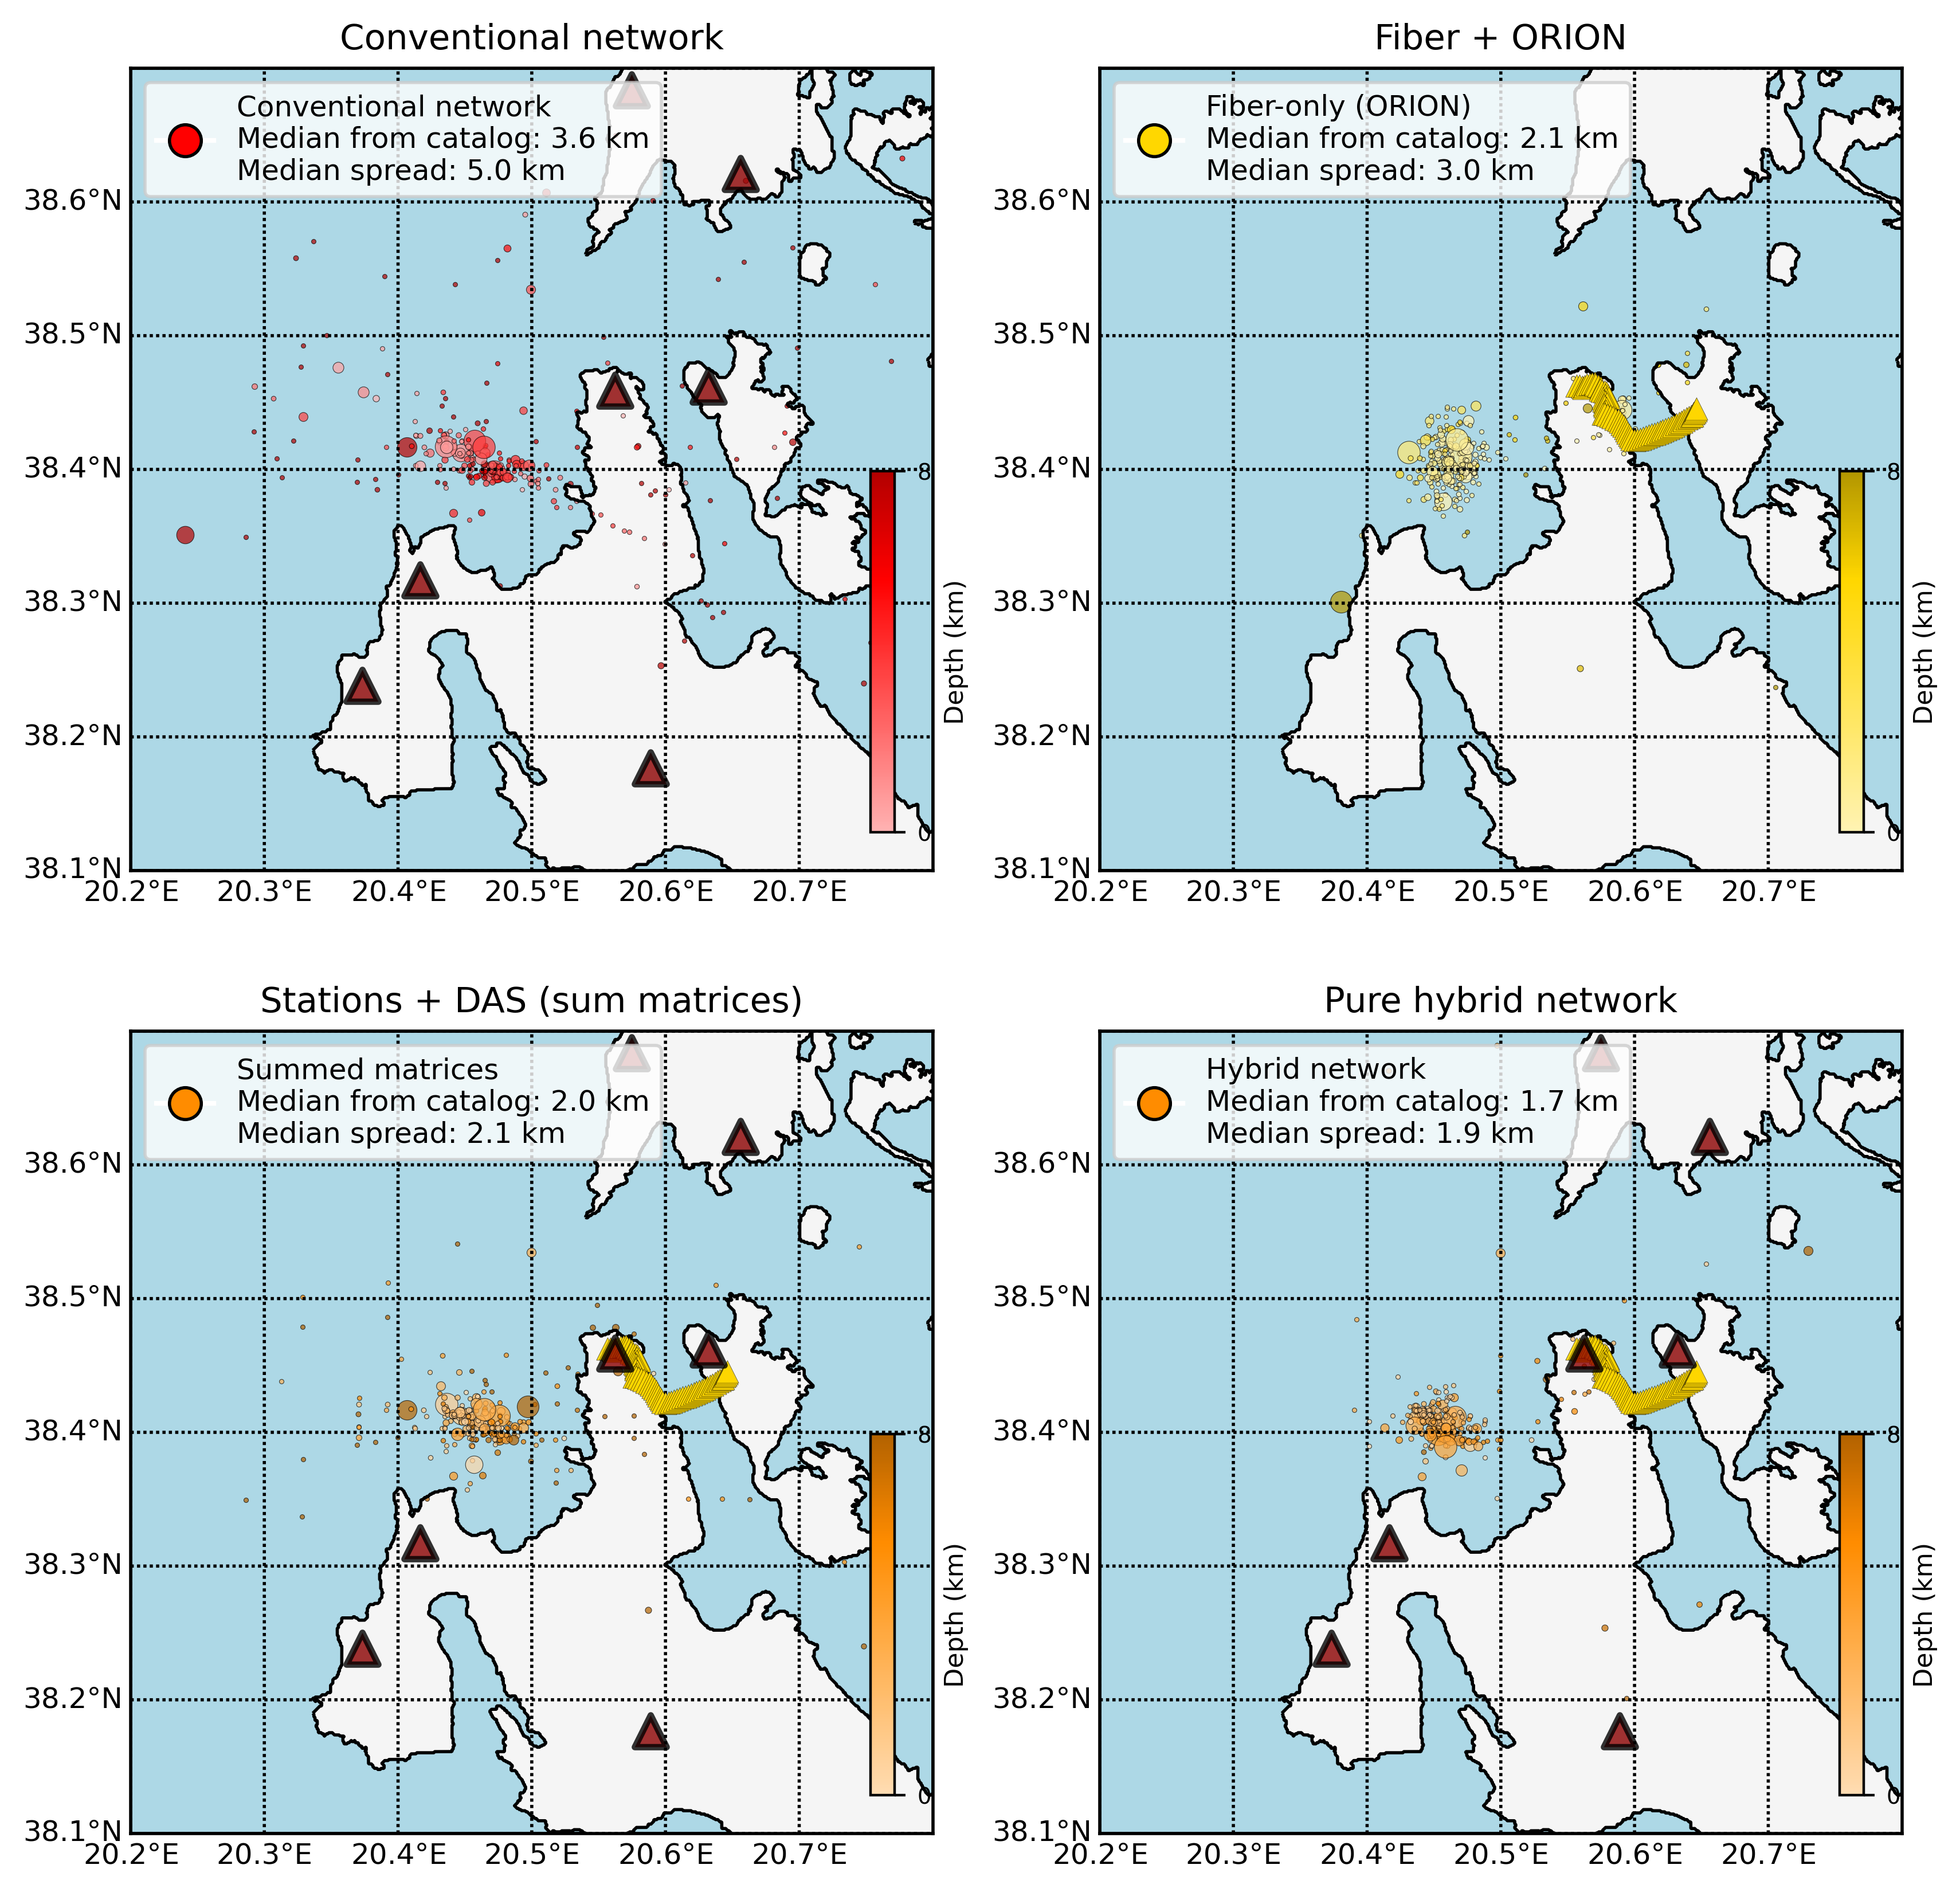

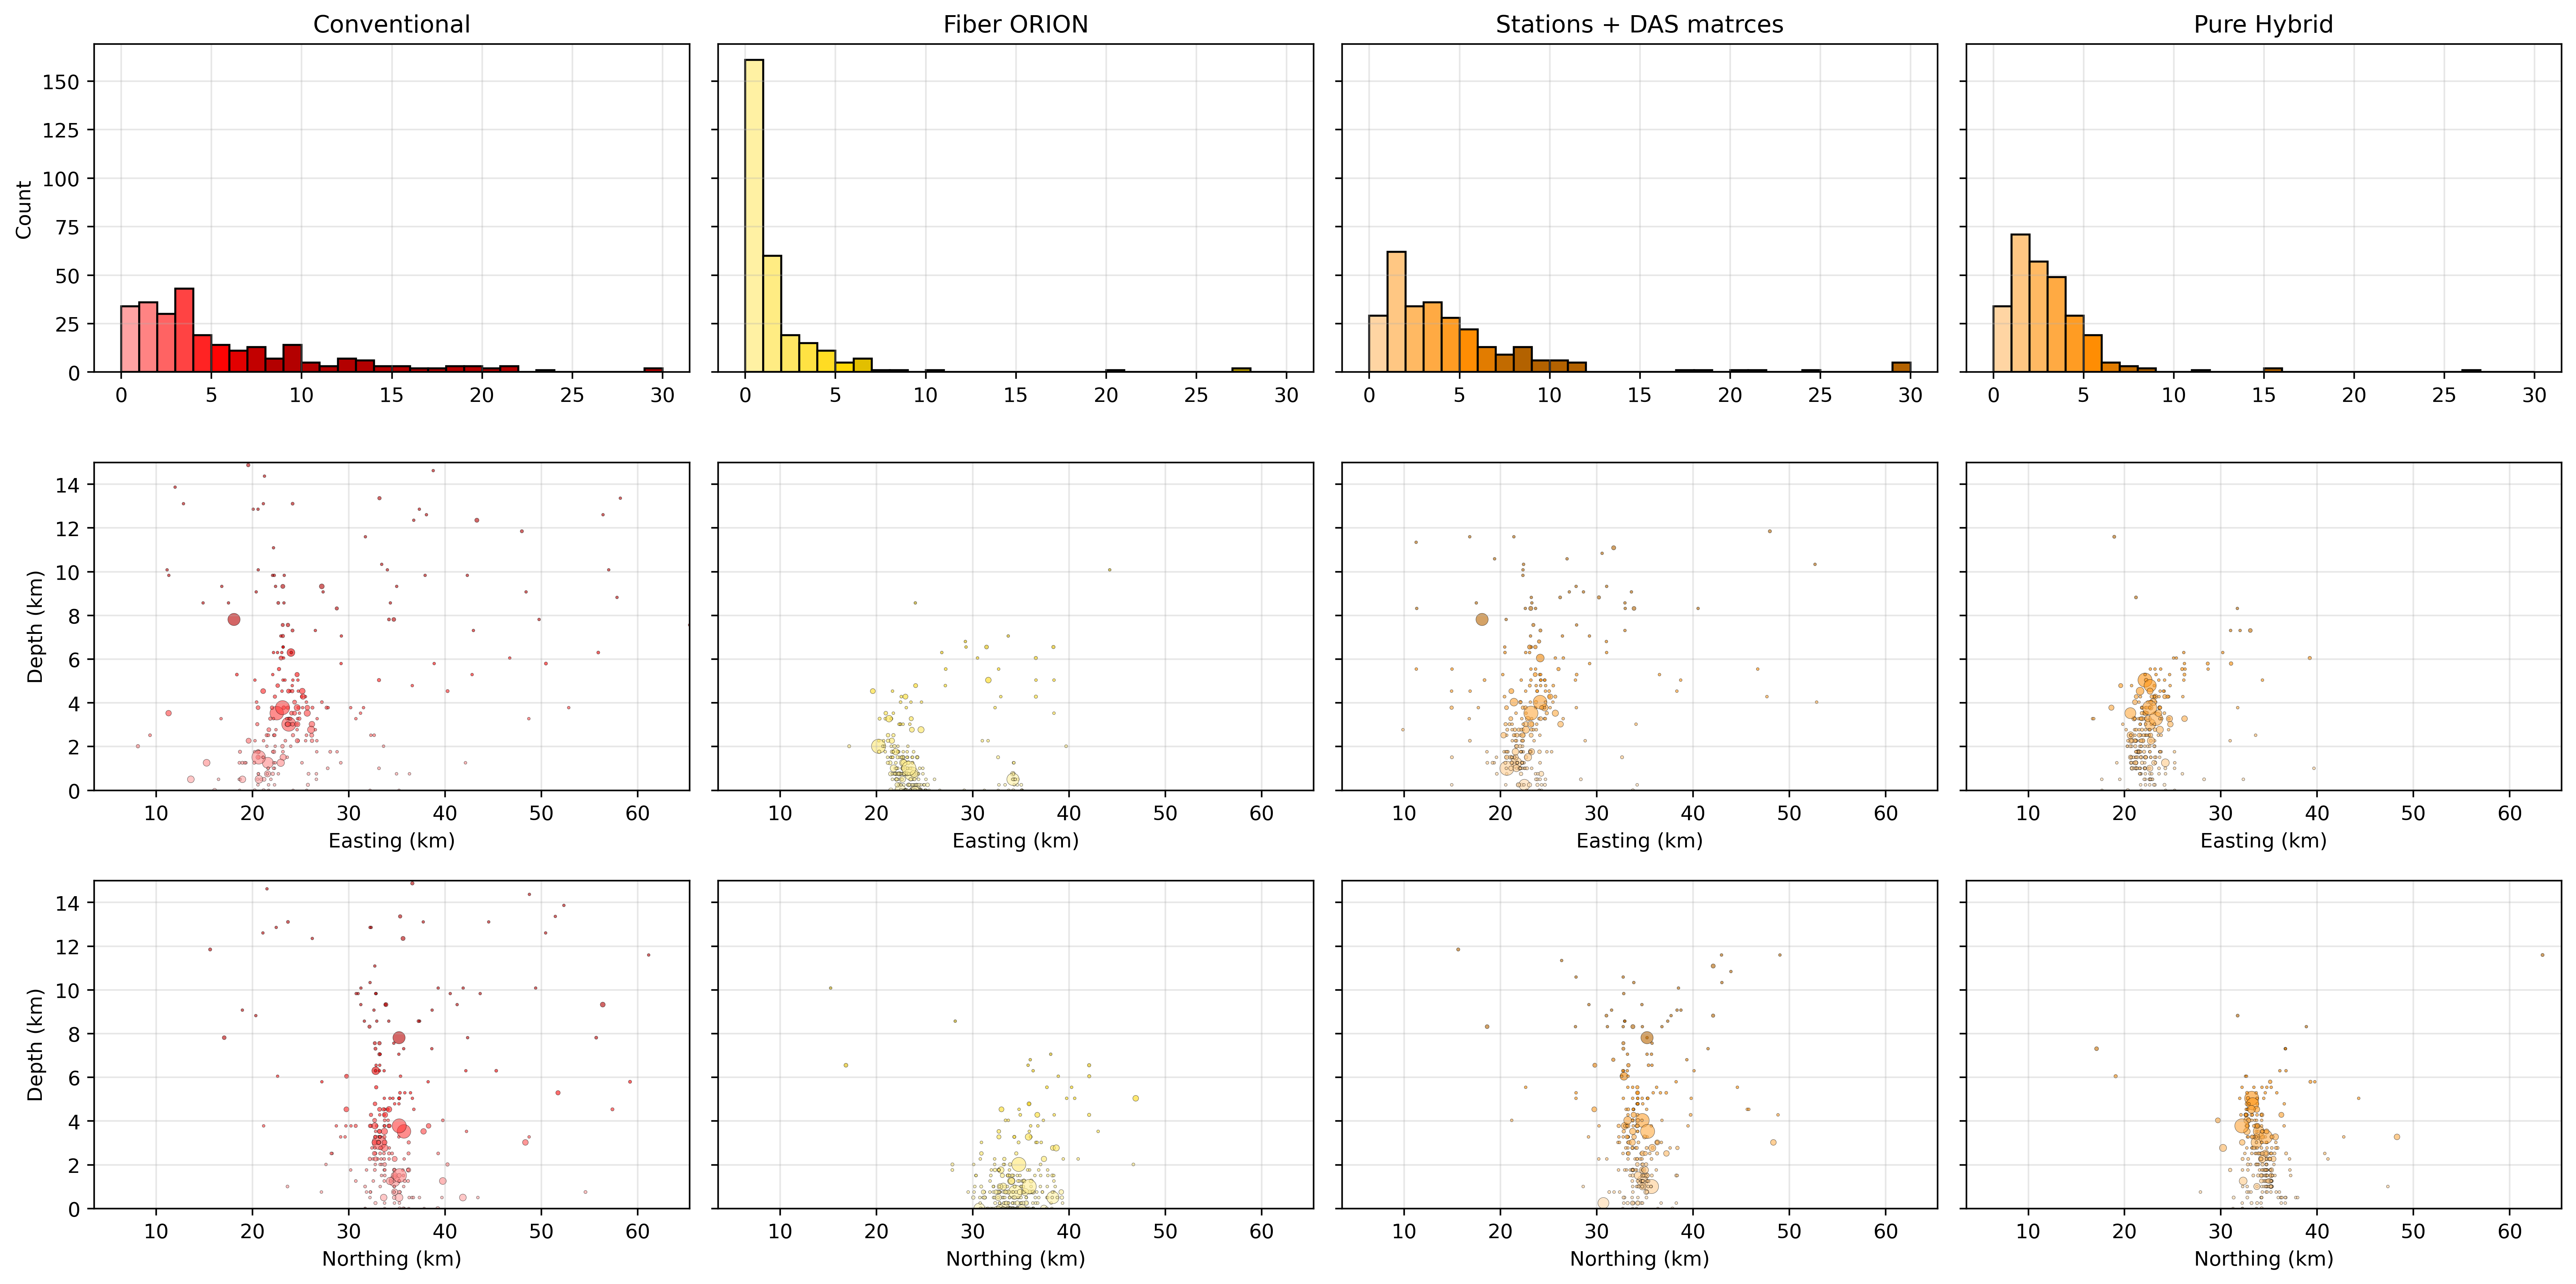

In [6]:
import numpy as np
import os
import matplotlib.pyplot as plt

nx = ny = nz = 151
dx = dz = 0.5

cartesian_grid_x, cartesian_grid_y = np.meshgrid(np.linspace(0, 75.5, nx), np.linspace(0, 75.5, ny))

plot_fiber_only_map_with_maxima_no_cat(
    ref_lat=38.10,
    ref_lon=20.20,
    das_hyb={
        "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
        "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
        "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
        "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
        "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
        "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
        "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
        "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
    },
    earthquake_location=(38.40435, 20.45875),
    cartesian_grid_x=cartesian_grid_x,
    cartesian_grid_y=cartesian_grid_y,
    lat_range=(38.1, 38.7),
    lon_range=(20.2, 20.8),
    magnitude_threshold=0,
    parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_new_hybrid_4/',
    hybrid2_parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_new_hybrid_4/',  # <-- new argument
    title="Epicenters with selected DAS channels (tot. catalog)"
)



In [ ]:



plot_fiber_only_map_with_maxima_no_cat(
    ref_lat=38.10,
    ref_lon=20.20,
    das_hyb={
        "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
        "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
        "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
        "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
        "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
        "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
        "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
        "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
    },
    earthquake_location=(38.40435, 20.45875),
    cartesian_grid_x=cartesian_grid_x,
    cartesian_grid_y=cartesian_grid_y,
    lat_range=(38.2, 38.6),
    lon_range=(20.3, 20.7),
    magnitude_threshold=0,
    parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/',
    hybrid2_parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2_prova/',  # <-- new argument
    title="Epicenters with selected DAS channels (tot. catalog)"
)



/home/emanuele/miniconda3/envs/loki-DAS-ema/lib/python3.7/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


FileNotFoundError: [Errno 2] No such file or directory: '/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/catalog_17072025.csv'

In [ ]:
def plot_fiber_only_map_with_maxima_no_cat(
    ref_lat, ref_lon, das_hyb,
    earthquake_location, cartesian_grid_x,
    cartesian_grid_y, lat_range, lon_range,
    parent_folder,
    hybrid2_parent_folder,
    title="Fiber Maxima Map",
    magnitude_threshold=0.0
):
    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from scipy.ndimage import zoom
    import numpy as np
    import os
    import glob
    import pandas as pd
    import re
    from math import radians, sin, cos, sqrt, atan2
    from scipy.stats import gaussian_kde
    from matplotlib.lines import Line2D

    # ---------------------- HELPER FUNCTIONS ----------------------
    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        earth_radius = 6371
        lat = origin_lat + (y / earth_radius) * (180 / np.pi)
        lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371.0
        dlat = radians(lat2 - lat1)
        dlon = radians(lon2 - lon1)
        a = sin(dlat / 2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2)**2
        c = 2 * atan2(sqrt(a), sqrt(1 - a))
        return R * c

    def collect_refined_max_locations_for_variant(parent_folder, event_id, variant_folder_name, variant_suffix):
        event_path = os.path.join(parent_folder, event_id, variant_folder_name)
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        if not os.path.isdir(event_path):
            return max_locations

        pattern = f"corrmatrix_trial_*_{variant_suffix}.npy"
        npy_files = glob.glob(os.path.join(event_path, pattern))

        for file in npy_files:
            try:
                corrmatrix_das = np.load(file)
                total_size = corrmatrix_das.size
                if total_size % (nx * ny) != 0:
                    continue

                nz = total_size // (nx * ny)
                corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                corrmatrix = corrmatrix / np.nanmax(corrmatrix)
                CXY = np.max(corrmatrix, axis=2).T

                window_size = 15
                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 25
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)
                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]
                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)

                max_locations.append((lat_max, lon_max))
            except Exception:
                continue

        return max_locations

    def collect_refined_max_locations_for_hybrid_sum(parent_folder, event_id):
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        event_orion_path = os.path.join(parent_folder, event_id, 'fiber_orion')
        event_stations_path = os.path.join(parent_folder, event_id, 'stations')

        if not os.path.isdir(event_orion_path) or not os.path.isdir(event_stations_path):
            return max_locations

        orion_files = sorted(glob.glob(os.path.join(event_orion_path, 'corrmatrix_trial_*_fiber.npy')))
        stations_files = sorted(glob.glob(os.path.join(event_stations_path, 'corrmatrix_trial_*_stations.npy')))

        def get_trial_num(filename):
            m = re.search(r'corrmatrix_trial_(\d+)_', filename)
            return int(m.group(1)) if m else -1

        orion_files = sorted(orion_files, key=get_trial_num)
        stations_files = sorted(stations_files, key=get_trial_num)

        for ofile, sfile in zip(orion_files, stations_files):
            if get_trial_num(ofile) != get_trial_num(sfile):
                continue

            try:
                corr_orion = np.load(ofile)
                corr_stations = np.load(sfile)

                if corr_orion.size != corr_stations.size or corr_orion.size % (nx * ny) != 0:
                    continue

                nz = corr_orion.size // (nx * ny)
                corr_orion = corr_orion.reshape((nx, ny, nz))
                corr_stations = corr_stations.reshape((nx, ny, nz))

                corr_sum = corr_orion + corr_stations
                corr_sum = corr_sum / np.nanmax(corr_sum)
                CXY = np.max(corr_sum, axis=2).T

                window_size = 15
                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 25
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)
                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]
                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)
                max_locations.append((lat_max, lon_max))
            except Exception:
                continue

        return max_locations

    def collect_refined_max_locations_for_hybrid2(hybrid2_parent_folder, event_id):
        event_path = os.path.join(hybrid2_parent_folder, event_id, 'hybrid2')
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        if not os.path.isdir(event_path):
            return max_locations

        pattern = "corrmatrix_trial_*_hybrid.npy"
        npy_files = glob.glob(os.path.join(event_path, pattern))

        for file in npy_files:
            try:
                corrmatrix_das = np.load(file)
                total_size = corrmatrix_das.size
                if total_size % (nx * ny) != 0:
                    continue

                nz = total_size // (nx * ny)
                corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                corrmatrix = corrmatrix / np.nanmax(corrmatrix)
                CXY = np.max(corrmatrix, axis=2).T

                window_size = 15
                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 25
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)
                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]
                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)
                max_locations.append((lat_max, lon_max))
            except Exception:
                continue

        return max_locations

    def plot_50pct_contour(ax, coords, color, label, **kwargs):
        if len(coords) < 10:
            return None
        xy = np.array(coords).T
        kde = gaussian_kde(xy)

        x_min, y_min = xy.min(axis=1)
        x_max, y_max = xy.max(axis=1)
        x_grid = np.linspace(x_min, x_max, 200)
        y_grid = np.linspace(y_min, y_max, 200)
        xgrid, ygrid = np.meshgrid(x_grid, y_grid)
        grid_coords = np.vstack([xgrid.ravel(), ygrid.ravel()])
        kde_vals = kde(grid_coords).reshape(xgrid.shape)

        sorted_kde = np.sort(kde_vals.ravel())[::-1]
        cumsum = np.cumsum(sorted_kde) / np.sum(sorted_kde)
        level = sorted_kde[np.searchsorted(cumsum, 0.5)]

        contour = ax.contour(xgrid, ygrid, kde_vals, levels=[level],
                             colors=[color], linestyles='dashed', linewidths=5, alpha=0.9, **kwargs)
        if contour.collections:
            return contour.collections[0]
        return None

    # ---------------------- DATA LOADING ----------------------
    catalog_path = os.path.join(parent_folder, 'catalog_17072025.csv')
    catalog_df = pd.read_csv(catalog_path)
    catalog_df['evid'] = catalog_df['evid'].astype(str)
    magnitude_dict = dict(zip(catalog_df['evid'], catalog_df['ML']))

    event_ids = [f for f in os.listdir(parent_folder)
                 if os.path.isdir(os.path.join(parent_folder, f)) and re.match(r'^kef\d+', f)]

    def marker_size_from_magnitude(mag, base_size=2, scale_factor=50):
        return base_size + scale_factor * mag

    map_titles = [
        'Stations',
        'Fiber + ORION',
        'Hybrid (sum)',
        'Fiber + uniform',
        'Hybrid (same num. sensors)',
        'Hybrid2 (ORION + stations)'
    ]
    variant_groups = [
        [('stations', 'stations', 'stations', 'royalblue', 'Stations')],
        [('orion', 'fiber_orion', 'fiber', 'darkred', 'ORION')],
        [('hybrid_sum', None, None, 'darkorange', 'Hybrid (sum)')],
        [('uniform', 'fiber_uniform', 'fiber', 'teal', 'Uniform')],
        [('hybrid', 'hybrid', 'hybrid', 'mediumorchid', 'Hybrid')],
        [('hybrid2', None, None, 'green', 'Hybrid2')]
    ]

    das_csv_path = "/home/emanuele/data/emanuele/loki-das/cefalonia/geometry"
    stations_csv_path = os.path.join(das_csv_path, "stations.csv")

    # ---------------------- PLOTTING ----------------------
    for idx, (variants, map_title) in enumerate(zip(variant_groups, map_titles)):
        fig, ax = plt.subplots(figsize=(7, 5), dpi=400)

        m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                    llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='f', ax=ax)
        m.drawcoastlines()
        m.drawcountries()
        m.fillcontinents(color='whitesmoke', lake_color='lightblue')
        m.drawmapboundary(fill_color='lightblue')
        m.drawparallels(np.arange(lat_range[0], lat_range[1] + 0.01, 0.1),
                        labels=[1, 0, 0, 0], fontsize=9)
        m.drawmeridians(np.arange(lon_range[0], lon_range[1] + 0.01, 0.1),
                        labels=[0, 0, 0, 1], fontsize=9)
        ax.set_title(map_title, fontsize=11)

        distances = {}
        coords = {}
        legend_elements = []

        try:
            for file in os.listdir(das_csv_path):
                if file.endswith(".csv") and file != "stations.csv":
                    df_das = pd.read_csv(os.path.join(das_csv_path, file))
                    if "latitude" in df_das.columns and "longitude" in df_das.columns:
                        sampled_df = df_das.iloc[::100]
                        if idx in [1, 2, 3, 4, 5]:
                            ax.scatter(sampled_df["longitude"], sampled_df["latitude"], marker='^',
                                       color='darkorange', linewidths=0.7, edgecolor='k', s=50, alpha=0.9,
                                       label="DAS fiber")
                    break
        except Exception as e:
            print(f"Error loading DAS CSV: {e}")

        if idx in [0, 2, 4, 5]:
            try:
                df_stations = pd.read_csv(stations_csv_path)
                ax.scatter(df_stations["longitude"], df_stations["latitude"], marker='^',
                           color='darkred', edgecolor='k', s=100, alpha=0.8, label="Conventional seismic stations")
            except Exception as e:
                print(f"Error loading stations.csv: {e}")

        catalog_lats = catalog_df['latitude'].values
        catalog_lons = catalog_df['longitude'].values
        ax.scatter(catalog_lons, catalog_lats, marker='o', color='black', s=30,
                   label='Catalog', alpha=0.7, edgecolor='k', linewidth=0.5)

        for event_id in event_ids:
            magnitude = magnitude_dict.get(event_id, None)
            if magnitude is None or magnitude < magnitude_threshold:
                continue
            marker_size = marker_size_from_magnitude(magnitude)

            for key, folder, suffix, color, label in variants:
                if key == 'hybrid_sum':
                    points = collect_refined_max_locations_for_hybrid_sum(parent_folder, event_id)
                elif key == 'hybrid2':
                    points = collect_refined_max_locations_for_hybrid2(hybrid2_parent_folder, event_id)
                else:
                    points = collect_refined_max_locations_for_variant(parent_folder, event_id, folder, suffix)

                for lat, lon in points:
                    ax.scatter(lon, lat, marker='o', color=color, edgecolor='k', linewidths=0.5,
                               s=marker_size, alpha=0.5)
                    distances.setdefault(key, []).append(
                        haversine(earthquake_location[0], earthquake_location[1], lat, lon))
                    coords.setdefault(key, []).append((lon, lat))

        for key, _, _, color, label in variants:
            if key in coords:
                contour = plot_50pct_contour(ax, coords[key], color, f"{label} 50% KDE")
                if distances[key]:
                    med = np.median(distances[key])
                    label_with_med = f"{label} (med: {med:.1f} km)"
                else:
                    label_with_med = label

                # Marker legend (points)
                legend_elements.append(Line2D([0], [0], marker='o', color='w', label=label_with_med,
                                            markerfacecolor=color, markeredgecolor='k', markersize=10))

                # Contour legend (50% KDE line)
                legend_elements.append(Line2D([0], [0], color=color, linestyle='--', linewidth=1.5,
                                            label=f"{label} 50% KDE"))


        if idx in [1, 2, 3, 4, 5]:
            legend_elements.append(Line2D([0], [0], marker='^', color='w', label='DAS fiber',
                                          markerfacecolor='darkorange', markeredgecolor='k', markersize=10))
        if idx in [0, 2, 4, 5]:
            legend_elements.append(Line2D([0], [0], marker='^', color='w', label='Conventional seismic network',
                                          markerfacecolor='darkred', markeredgecolor='k', markersize=10))
        legend_elements.append(Line2D([0], [0], marker='o', color='w',
                                      label='Catalog earthquake locations \n (Bocchini et al., 2025 in prep.)',
                                      markerfacecolor='black', markeredgecolor='k', markersize=2))
        
        # Example: magnitude legend
        example_mags = [0.5, 1.0, 2.0, 3.0]  # you can adjust these
        size_scale = 20  # this must match your actual size scaling
        mag_handles = [
            Line2D([0], [0], marker='o', color='w', label=f"M {mag}",
                markerfacecolor='gray', markeredgecolor='k',
                markersize=np.sqrt(mag * size_scale))
            for mag in example_mags
        ]

        # Combine the magnitude legend with the dataset legend
        all_legend_elements = legend_elements + mag_handles
        ax.legend(handles=all_legend_elements, loc='upper right', fontsize=8, title="Legend")



        ax.legend(handles=legend_elements, fontsize=10, loc='upper right')

        plt.tight_layout()
        plt.show()  # Show each plot separately



In [5]:
def plot_fiber_only_map_with_maxima_no_cat(
        ref_lat, ref_lon, das_hyb,
        earthquake_location, cartesian_grid_x,
        cartesian_grid_y, lat_range, lon_range,
        parent_folder,
        hybrid_base_folder=None,  # NEW PARAM
        title="Fiber Maxima Map",
        magnitude_threshold=0.0):

    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from scipy.ndimage import zoom
    import numpy as np
    import os
    import glob
    import pandas as pd
    import re
    from math import radians, sin, cos, sqrt, atan2
    from scipy.stats import gaussian_kde
    from matplotlib.lines import Line2D

    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        earth_radius = 6371
        lat = origin_lat + (y / earth_radius) * (180 / np.pi)
        lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371.0
        dlat = radians(lat2 - lat1)
        dlon = radians(lon2 - lon1)
        a = sin(dlat / 2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2)**2
        c = 2 * atan2(sqrt(a), sqrt(1 - a))
        return R * c

    def collect_refined_max_locations_for_variant(base_folder, event_id, variant_folder_name, variant_suffix):
        event_path = os.path.join(base_folder, event_id, variant_folder_name)
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        if not os.path.isdir(event_path):
            return max_locations

        pattern = f"corrmatrix_trial_*_{variant_suffix}.npy"
        npy_files = glob.glob(os.path.join(event_path, pattern))

        for file in npy_files:
            try:
                corrmatrix_das = np.load(file)
                total_size = corrmatrix_das.size
                if total_size % (nx * ny) != 0:
                    continue

                nz = total_size // (nx * ny)
                corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                corrmatrix = corrmatrix / np.nanmax(corrmatrix)
                CXY = np.max(corrmatrix, axis=2).T

                window_size = 15
                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 25
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)

                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]

                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)
                max_locations.append((lat_max, lon_max))

            except Exception:
                continue

        return max_locations

    def collect_refined_max_locations_for_hybrid_sum(base_folder, event_id):
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        event_orion_path = os.path.join(base_folder, event_id, 'fiber_orion')
        event_stations_path = os.path.join(base_folder, event_id, 'stations')

        if not os.path.isdir(event_orion_path) or not os.path.isdir(event_stations_path):
            return max_locations

        orion_files = sorted(glob.glob(os.path.join(event_orion_path, 'corrmatrix_trial_*_fiber.npy')))
        stations_files = sorted(glob.glob(os.path.join(event_stations_path, 'corrmatrix_trial_*_stations.npy')))

        def get_trial_num(filename):
            m = re.search(r'corrmatrix_trial_(\d+)_', filename)
            return int(m.group(1)) if m else -1

        orion_files = sorted(orion_files, key=get_trial_num)
        stations_files = sorted(stations_files, key=get_trial_num)

        for ofile, sfile in zip(orion_files, stations_files):
            if get_trial_num(ofile) != get_trial_num(sfile):
                continue

            try:
                corr_orion = np.load(ofile)
                corr_stations = np.load(sfile)

                if corr_orion.size != corr_stations.size or corr_orion.size % (nx * ny) != 0:
                    continue

                nz = corr_orion.size // (nx * ny)
                corr_orion = corr_orion.reshape((nx, ny, nz))
                corr_stations = corr_stations.reshape((nx, ny, nz))

                corr_sum = corr_orion + corr_stations
                corr_sum = corr_sum / np.nanmax(corr_sum)
                CXY = np.max(corr_sum, axis=2).T

                window_size = 15
                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 25
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)

                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]

                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)
                max_locations.append((lat_max, lon_max))

            except Exception:
                continue

        return max_locations

    def plot_50pct_contour(ax, coords, color, label, **kwargs):
        if len(coords) < 10:
            return None
        xy = np.array(coords).T
        kde = gaussian_kde(xy)

        x_min, y_min = xy.min(axis=1)
        x_max, y_max = xy.max(axis=1)
        x_grid = np.linspace(x_min, x_max, 200)
        y_grid = np.linspace(y_min, y_max, 200)
        xgrid, ygrid = np.meshgrid(x_grid, y_grid)
        grid_coords = np.vstack([xgrid.ravel(), ygrid.ravel()])
        kde_vals = kde(grid_coords).reshape(xgrid.shape)

        sorted_kde = np.sort(kde_vals.ravel())[::-1]
        cumsum = np.cumsum(sorted_kde) / np.sum(sorted_kde)
        level = sorted_kde[np.searchsorted(cumsum, 0.5)]
        contour = ax.contour(xgrid, ygrid, kde_vals, levels=[level], colors=[color],
                             linestyles='dashed', alpha=0.7, **kwargs)
        return contour

    catalog_path = os.path.join(parent_folder, 'catalog_17072025.csv')
    catalog_df = pd.read_csv(catalog_path)
    catalog_df['evid'] = catalog_df['evid'].astype(str)
    magnitude_dict = dict(zip(catalog_df['evid'], catalog_df['ML']))

    event_ids = [f for f in os.listdir(parent_folder)
                 if os.path.isdir(os.path.join(parent_folder, f)) and re.match(r'^kef\d+', f)]

    def marker_size_from_magnitude(mag, base_size=5, scale_factor=25):
        return base_size + scale_factor * mag

    fig, axes = plt.subplots(2, 3, figsize=(25, 12), dpi=300)
    axes = axes.flatten()

    map_titles = ['Stations', 'Fiber + ORION seletion', 'Hybrid (sum)', 
                  'Fiber + uniform selection', 'Hybrid (mix horiz. comp)']
    variant_groups = [
        [('stations', 'stations', 'stations', 'royalblue', 'Stations')],
        [('orion', 'fiber_orion', 'fiber', 'darkred', 'ORION')],
        [('hybrid_sum', None, None, 'darkorange', 'Hybrid (sum)')],
        [('uniform', 'fiber_uniform', 'fiber', 'teal', 'Uniform')],
        [('hybrid', 'hybrid', 'hybrid', 'mediumorchid', 'Hybrid')],
    ]

    das_csv_path = "/home/emanuele/data/emanuele/loki-das/cefalonia/geometry"
    stations_csv_path = os.path.join(das_csv_path, "stations.csv")

    for idx, (ax, variants, map_title) in enumerate(zip(axes, variant_groups, map_titles)):
        m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                    llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='f', ax=ax)
        m.drawcoastlines()
        m.drawcountries()
        m.fillcontinents(color='whitesmoke', lake_color='lightblue')
        m.drawmapboundary(fill_color='lightblue')
        m.drawparallels(np.arange(lat_range[0], lat_range[1] + 0.01, 0.1), labels=[1, 0, 0, 0], fontsize=9)
        m.drawmeridians(np.arange(lon_range[0], lon_range[1] + 0.01, 0.1), labels=[0, 0, 0, 1], fontsize=9)
        ax.set_title(map_title, fontsize=11)

        distances = {}
        coords = {}
        legend_elements = []

        # Plot DAS fiber
        try:
            for file in os.listdir(das_csv_path):
                if file.endswith(".csv") and file != "stations.csv":
                    df_das = pd.read_csv(os.path.join(das_csv_path, file))
                    if "latitude" in df_das.columns and "longitude" in df_das.columns:
                        sampled_df = df_das.iloc[::100]
                        ax.scatter(sampled_df["longitude"], sampled_df["latitude"], marker='^',
                                   color='darkorange', linewidths=0.7, edgecolor='k', s=50, alpha=0.9,
                                   label="DAS fiber")
                    break
        except Exception as e:
            print(f"Error loading DAS CSV: {e}")

        # Plot stations (only in 1st, 3rd, 5th plot)
        if idx in [0, 2, 4]:
            try:
                df_stations = pd.read_csv(stations_csv_path)
                ax.scatter(df_stations["lon"], df_stations["lat"], marker='s',
                           color='darkred', edgecolor='k', s=100, alpha=0.8, label="Conventional seismic stations")
            except Exception as e:
                print(f"Error loading stations.csv: {e}")

        for event_id in event_ids:
            magnitude = magnitude_dict.get(event_id, None)
            if magnitude is None or magnitude < magnitude_threshold:
                continue

            marker_size = marker_size_from_magnitude(magnitude)

            for key, folder, suffix, color, label in variants:
                if key == 'hybrid_sum':
                    points = collect_refined_max_locations_for_hybrid_sum(parent_folder, event_id)
                else:
                    if folder == 'hybrid' and hybrid_base_folder is not None:
                        points = collect_refined_max_locations_for_variant(hybrid_base_folder, event_id, folder, suffix)
                    else:
                        points = collect_refined_max_locations_for_variant(parent_folder, event_id, folder, suffix)

                for lat, lon in points:
                    ax.scatter(lon, lat, marker='o', color=color, edgecolor='k', linewidths=0.5,
                               s=marker_size, alpha=0.5)
                    distances.setdefault(key, []).append(haversine(earthquake_location[0], earthquake_location[1], lat, lon))
                    coords.setdefault(key, []).append((lon, lat))

        for key, _, _, color, label in variants:
            if key in coords:
                plot_50pct_contour(ax, coords[key], color, f"{label} 50% KDE", linewidth=10)
                if distances[key]:
                    med = np.median(distances[key])
                    label_with_med = f"{label} (med: {med:.1f} km)"
                else:
                    label_with_med = label
                legend_elements.append(Line2D([0], [0], marker='o', color='w', label=label_with_med,
                                              markerfacecolor=color, markeredgecolor='k', markersize=10))

        if idx in [1, 2, 3, 4]:
            legend_elements.append(Line2D([0], [0], marker='^', color='w', label='DAS fiber',
                                          markerfacecolor='darkorange', markeredgecolor='k', markersize=10))
        if idx in [0, 2, 4]:
            legend_elements.append(Line2D([0], [0], marker='^', color='w', label='Conventional seismic network',
                                          markerfacecolor='darkred', markeredgecolor='k', markersize=10))

        ax.legend(handles=legend_elements, fontsize=10, loc='upper right')

    if len(variant_groups) < len(axes):
        for i in range(len(variant_groups), len(axes)):
            fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()


In [6]:
plot_fiber_only_map_with_maxima_no_cat_single_color(
    ref_lat=38.10,
    ref_lon=20.20,
    das_hyb={
        "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
        "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
        "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
        "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
        "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
        "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
        "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
        "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
    },
    earthquake_location=(38.40435, 20.45875),
    cartesian_grid_x=cartesian_grid_x,
    cartesian_grid_y=cartesian_grid_y,
    lat_range=(38.2, 38.6),
    lon_range=(20.3, 20.7),
    parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection/',
    title="LION with auto-selected DAS channels"
)


NameError: name 'plot_fiber_only_map_with_maxima_no_cat_single_color' is not defined

In [ ]:
def plot_fiber_only_map_with_maxima(ref_lat, ref_lon, das_hyb,
                                    earthquake_location, cartesian_grid_x,
                                    cartesian_grid_y, lat_range, lon_range,
                                    parent_folder,
                                    title="Fiber Maxima Map (with non-selected)"):
    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from matplotlib.lines import Line2D
    from scipy.ndimage import zoom
    import numpy as np
    import os
    import glob
    import pandas as pd
    import re
    from matplotlib import cm

    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        earth_radius = 6371  # km
        lat = origin_lat + (y / earth_radius) * (180 / np.pi)
        lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371
        phi1 = np.radians(lat1)
        phi2 = np.radians(lat2)
        dphi = np.radians(lat2 - lat1)
        dlambda = np.radians(lon2 - lon1)

        a = np.sin(dphi / 2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
        return R * c

    def collect_refined_max_locations_for_variant(parent_folder, event_id, variant_suffix):
        folder_name = f"{event_id}{variant_suffix}"
        event_path = os.path.join(parent_folder, folder_name, 'fiber')
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        if not os.path.isdir(event_path):
            return max_locations

        npy_files = glob.glob(os.path.join(event_path, "corrmatrix_trial_*_fiber.npy"))

        for file in npy_files:
            try:
                corrmatrix_das = np.load(file)
                total_size = corrmatrix_das.size
                if total_size % (nx * ny) != 0:
                    continue

                nz = total_size // (nx * ny)
                corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                corrmatrix = corrmatrix / np.nanmax(corrmatrix)
                CXY = np.max(corrmatrix, axis=2).T

                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)

                window_size = 10
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 10
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)

                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]

                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)
                max_locations.append((lat_max, lon_max))
            except Exception:
                continue

        return max_locations

    # Load catalog
    catalog_path = os.path.join(parent_folder, 'catalog_17072025.csv')
    catalog_df = pd.read_csv(catalog_path)
    valid_evids = set(catalog_df['evid'].astype(str))
    evid_to_coords = {str(row['evid']): (row['latitude'], row['longitude']) for _, row in catalog_df.iterrows()}

    # Detect event IDs from folder names with _variant suffix
    folder_list = os.listdir(parent_folder)
    pattern = re.compile(r'^(.*)_(orion|random|non_selected)$')
    event_ids = set()
    for folder in folder_list:
        m = pattern.match(folder)
        if m:
            event_ids.add(m.group(1))

    event_ids = sorted(list(event_ids))
# Filter to IDs <= '0844' (preserving leading zeros)
# Filter event IDs from '0191' to '0844' inclusive
    #event_ids = sorted([
    #    eid for eid in event_ids
    #    if re.search(r'\d+', eid) and int(re.search(r'\d+', eid).group()) <= 845
    #])

    total_events = len(event_ids)

    # Assign colors
    tab20c_colors = cm.get_cmap('tab20').colors
    event_color_map = {}
    for i, eid in enumerate(event_ids):
        color = tab20c_colors[i % len(tab20c_colors)] if i < len(tab20c_colors) else (0.5, 0.5, 0.5)
        event_color_map[eid] = color

    fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
    m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='h', ax=ax)

    m.drawcoastlines()
    m.drawcountries()
    m.fillcontinents(color='lightgray', lake_color='lightblue')
    m.drawmapboundary(fill_color='lightblue')
    m.drawparallels(np.arange(lat_range[0], lat_range[1] + 0.01, 0.2), labels=[1, 0, 0, 0], fontsize=8)
    m.drawmeridians(np.arange(lon_range[0], lon_range[1] + 0.01, 0.2), labels=[0, 0, 0, 1], fontsize=8)

    # Global distance lists
    all_dists_orion = []
    all_dists_random = []
    all_dists_non_selected = []

    for event_id in event_ids:
        color = event_color_map[event_id]
        has_catalog = event_id in evid_to_coords

        if has_catalog:
            lat_cat, lon_cat = evid_to_coords[event_id]
            ax.scatter(lon_cat, lat_cat, marker='*', color=color, edgecolor='k', linewidths=1, s=40, alpha=0.7, label=f"{event_id} Catalog")
        else:
            print(f"[info] No catalog location for event {event_id}")
            lat_cat, lon_cat = None, None

        # Orion
        orion_pts = collect_refined_max_locations_for_variant(parent_folder, event_id, '_orion')
        for lat, lon in orion_pts:
            ax.scatter(lon, lat, marker='o', color=color, edgecolor='k', linewidths=0.5, s=20, alpha=0.7, label=f"{event_id} Orion")
            if lat_cat is not None:
                all_dists_orion.append(haversine(lat_cat, lon_cat, lat, lon))

        # Random
        random_pts = collect_refined_max_locations_for_variant(parent_folder, event_id, '_random')
        for lat, lon in random_pts:
            ax.scatter(lon, lat, marker='s', color=color, edgecolor='k', linewidths=0.5, s=20, alpha=0.7, label=f"{event_id} Random")
            if lat_cat is not None:
                all_dists_random.append(haversine(lat_cat, lon_cat, lat, lon))

        # Non-selected
        non_selected_pts = collect_refined_max_locations_for_variant(parent_folder, event_id, '_non_selected')
        for lat, lon in non_selected_pts:
            ax.scatter(lon, lat, marker='x', color=color, edgecolor='k', linewidths=0.5, s=20, alpha=0.7, label=f"{event_id} Non-selected")
            if lat_cat is not None:
                all_dists_non_selected.append(haversine(lat_cat, lon_cat, lat, lon))

    # Distance stats
    if all_dists_orion:
        print(f"[GLOBAL] Mean Orion distance: {np.mean(all_dists_orion):.2f} km")
    if all_dists_random:
        print(f"[GLOBAL] Mean Random distance: {np.mean(all_dists_random):.2f} km")
    if all_dists_non_selected:
        print(f"[GLOBAL] Mean Non-selected distance: {np.mean(all_dists_non_selected):.2f} km")

    # DAS station locations
    for name, (lat, lon) in das_hyb.items():
        ax.scatter(lon, lat, marker='^', color='black', edgecolor='k', s=25, label='DAS fiber')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    #ax.legend(unique.values(), unique.keys(), loc='upper right', fontsize='x-small', frameon=True)

    # Orion histogram
    if all_dists_orion:
        fig_orion, ax_orion = plt.subplots(figsize=(6, 4), dpi=150)
        ax_orion.hist(all_dists_orion, bins=20, color='blue', edgecolor='black', alpha=0.7)
        ax_orion.axvline(np.median(all_dists_orion), color='red', linestyle='--', label=f"Median = {np.median(all_dists_orion):.2f} km")
        ax_orion.set_title("Histogram of Orion Maxima Distances")
        ax_orion.set_xlabel("Distance from Catalog Location (km)")
        ax_orion.set_ylabel("Number of Maxima")
        ax_orion.set_ylim([0, 100])
        ax_orion.legend()
        ax_orion.grid(True)

    # Random histogram
    if all_dists_random:
        fig_random, ax_random = plt.subplots(figsize=(6, 4), dpi=150)
        ax_random.hist(all_dists_random, bins=20, color='green', edgecolor='black', alpha=0.7)
        ax_random.axvline(np.median(all_dists_random), color='red', linestyle='--', label=f"Median = {np.median(all_dists_random):.2f} km")
        ax_random.set_title("Histogram of Random Maxima Distances")
        ax_random.set_xlabel("Distance from Catalog Location (km)")
        ax_random.set_ylabel("Number of Maxima")
        ax_random.set_ylim([0, 100])
        ax_random.legend()
        ax_random.grid(True)

    # Non-selected histogram
    if all_dists_non_selected:
        fig_non, ax_non = plt.subplots(figsize=(6, 4), dpi=150)
        ax_non.hist(all_dists_non_selected, bins=20, color='orange', edgecolor='black', alpha=0.7)
        ax_non.axvline(np.median(all_dists_non_selected), color='red', linestyle='--', label=f"Median = {np.median(all_dists_non_selected):.2f} km")
        ax_non.set_title("Histogram of Non-selected Maxima Distances")
        ax_non.set_xlabel("Distance from Catalog Location (km)")
        ax_non.set_ylabel("Number of Maxima")
        ax_non.set_ylim([0, 100])
        ax_non.legend()
        ax_non.grid(True)

    plt.show()


[info] No catalog location for event kef0021


/home/emanuele/miniconda3/envs/loki-DAS-ema/lib/python3.7/site-packages/ipykernel_launcher.py:162: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.


[info] No catalog location for event kef0191
[info] No catalog location for event kef0200
[info] No catalog location for event kef0225
[info] No catalog location for event kef0273
[info] No catalog location for event kef0279
[info] No catalog location for event kef0413
[info] No catalog location for event kef0584
[info] No catalog location for event kef0752
[info] No catalog location for event kef1379
[info] No catalog location for event kef1401
[info] No catalog location for event kef1449
[info] No catalog location for event kef1677
[GLOBAL] Mean Orion distance: 4.60 km
[GLOBAL] Mean Random distance: 5.86 km
[GLOBAL] Mean Non-selected distance: 4.22 km


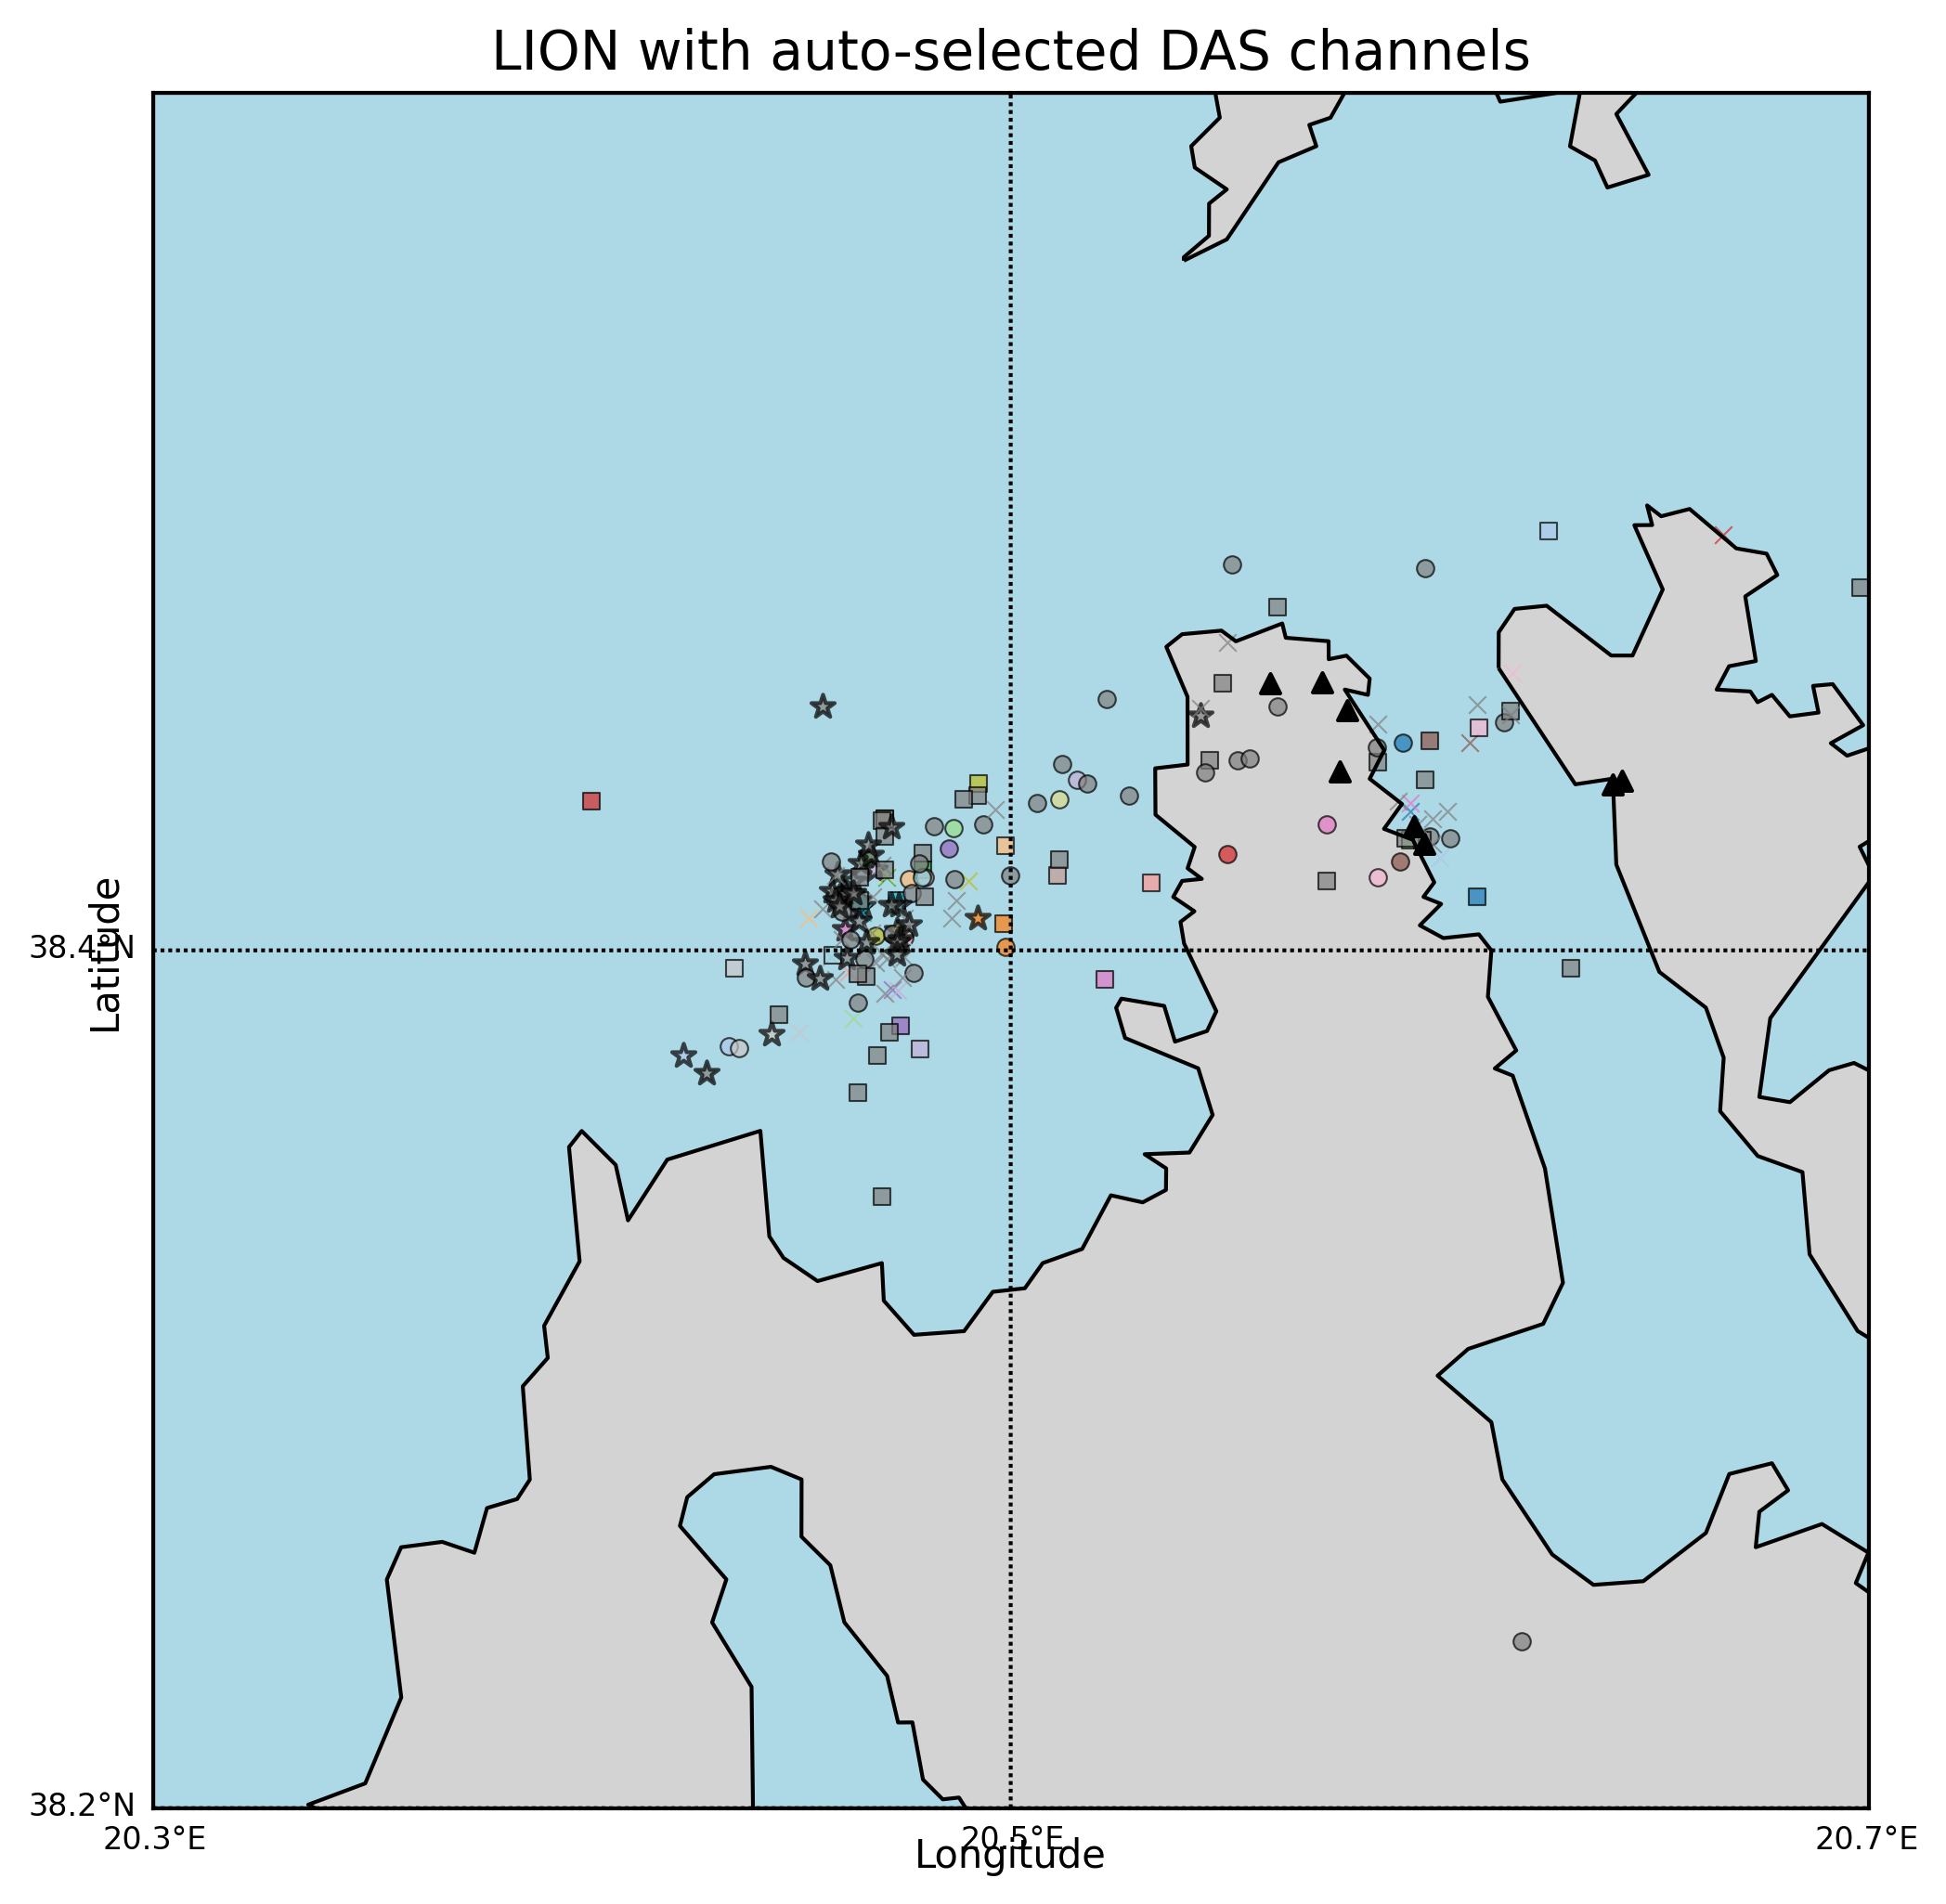

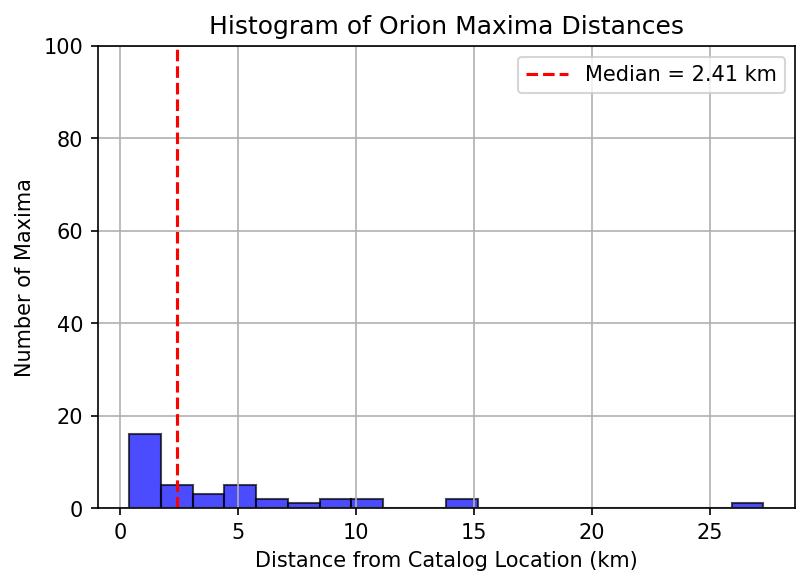

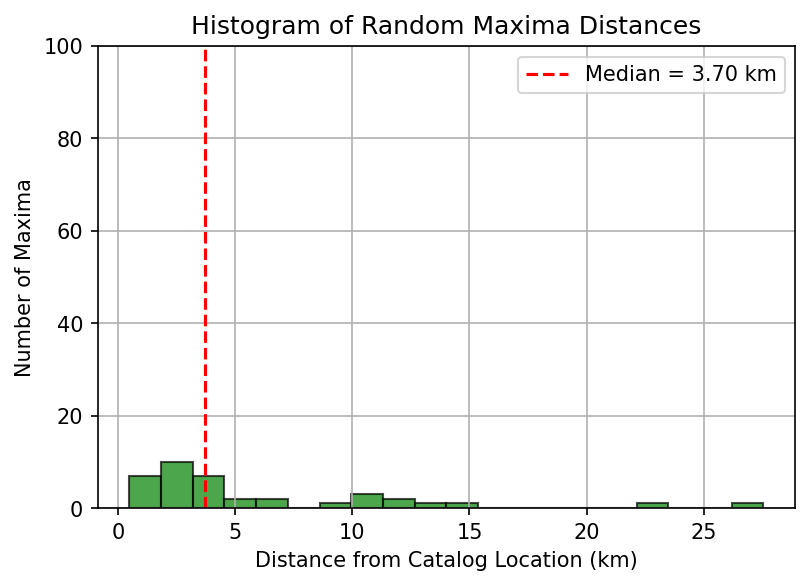

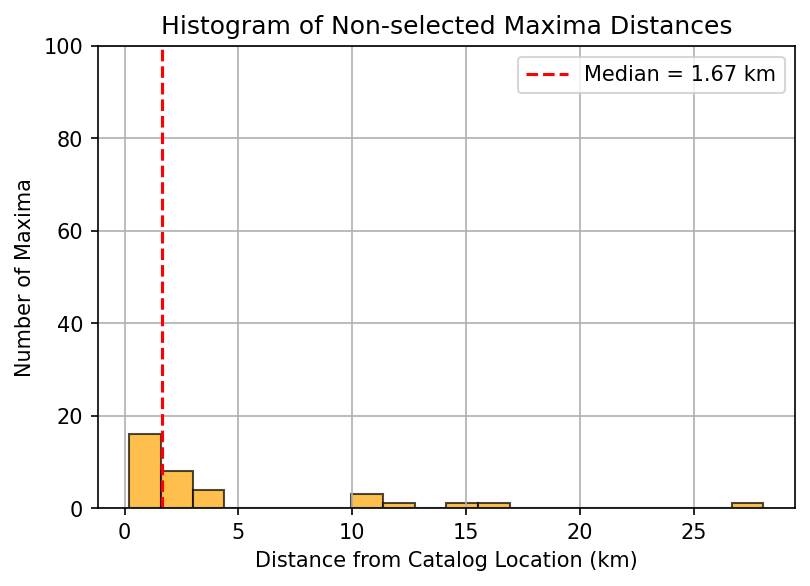

In [9]:
plot_fiber_only_map_with_maxima(
    ref_lat=38.10,
    ref_lon=20.20,
    das_hyb={
        "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
        "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
        "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
        "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
        "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
        "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
        "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
        "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
    },
    earthquake_location=(38.40435, 20.45875),
    cartesian_grid_x=cartesian_grid_x,
    cartesian_grid_y=cartesian_grid_y,
    lat_range=(38.2, 38.6),
    lon_range=(20.3, 20.7),
    parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected/',
    title="LION with auto-selected DAS channels"
)


In [37]:
def plot_fiber_only_map_with_percentile_sum(ref_lat, ref_lon, das_hyb,
                                            earthquake_location, cartesian_grid_x,
                                            cartesian_grid_y, lat_range, lon_range,
                                            parent_folder, title="Fiber 99th Percentile Sum Map"):
    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from matplotlib.colors import Normalize
    from matplotlib import cm
    from scipy.interpolate import griddata
    import numpy as np
    import os
    import glob

    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        earth_radius = 6371  # km
        lat = origin_lat + (y / earth_radius) * (180 / np.pi)
        lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    def collect_percentile_sum(folder_path):
        nx, ny = cartesian_grid_x.shape
        percentile_sum = np.zeros((ny, nx))  # Shape: (lat, lon)

        for event_folder in os.listdir(folder_path):
            event_path = os.path.join(folder_path, event_folder, 'fiber')
            if not os.path.isdir(event_path):
                continue

            npy_files = glob.glob(os.path.join(event_path, "corrmatrix_trial_*_fiber.npy"))
            for file in npy_files:
                try:
                    corrmatrix_das = np.load(file)
                    total_size = corrmatrix_das.size
                    if total_size % (nx * ny) != 0:
                        raise ValueError(f"File {file} shape is incompatible with grid size.")

                    nz = total_size // (nx * ny)
                    corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                    corrmatrix = corrmatrix / np.nanmax(corrmatrix)
                    CXY = np.nanpercentile(corrmatrix, 99, axis=2).T  # Shape: (ny, nx)
                    percentile_sum += np.nan_to_num(CXY)
                except Exception as e:
                    print(f"Failed to process {file}: {e}")
        return percentile_sum

    percentile_sum = collect_percentile_sum(parent_folder)

    fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
    m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='h', ax=ax)

    m.drawcoastlines()
    m.drawcountries()
    m.fillcontinents(color='lightgray', lake_color='lightblue')
    m.drawmapboundary(fill_color='lightblue')
    m.drawparallels(np.arange(lat_range[0], lat_range[1] + 0.01, 0.2), labels=[1,0,0,0], fontsize=8)
    m.drawmeridians(np.arange(lon_range[0], lon_range[1] + 0.01, 0.2), labels=[0,0,0,1], fontsize=8)

    # Convert grid to lat/lon
    lat_grid, lon_grid = cartesian_to_geographic(cartesian_grid_x, cartesian_grid_y, ref_lat, ref_lon)

    # Plot 99th percentile summed heatmap
    norm = Normalize(vmin=np.min(percentile_sum), vmax=np.max(percentile_sum))
    sc = ax.pcolormesh(lon_grid, lat_grid, percentile_sum, cmap=cm.inferno, shading='auto', norm=norm)

    # Plot earthquake catalog location
    ax.scatter(earthquake_location[1], earthquake_location[0], marker='*', color='red', edgecolors='black', s=130, label='Cluster Location')

    # Plot DAS HYB stations
    for name, (lat, lon) in das_hyb.items():
        ax.scatter(lon, lat, marker='o', color='crimson', s=14)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
    cbar.set_label("Summed 99th Percentile Coherence")

    ax.legend(loc='lower right', fontsize='small', frameon=True)
    plt.savefig("fiber_99th_percentile_sum_map.pdf", bbox_inches='tight')
    plt.show()


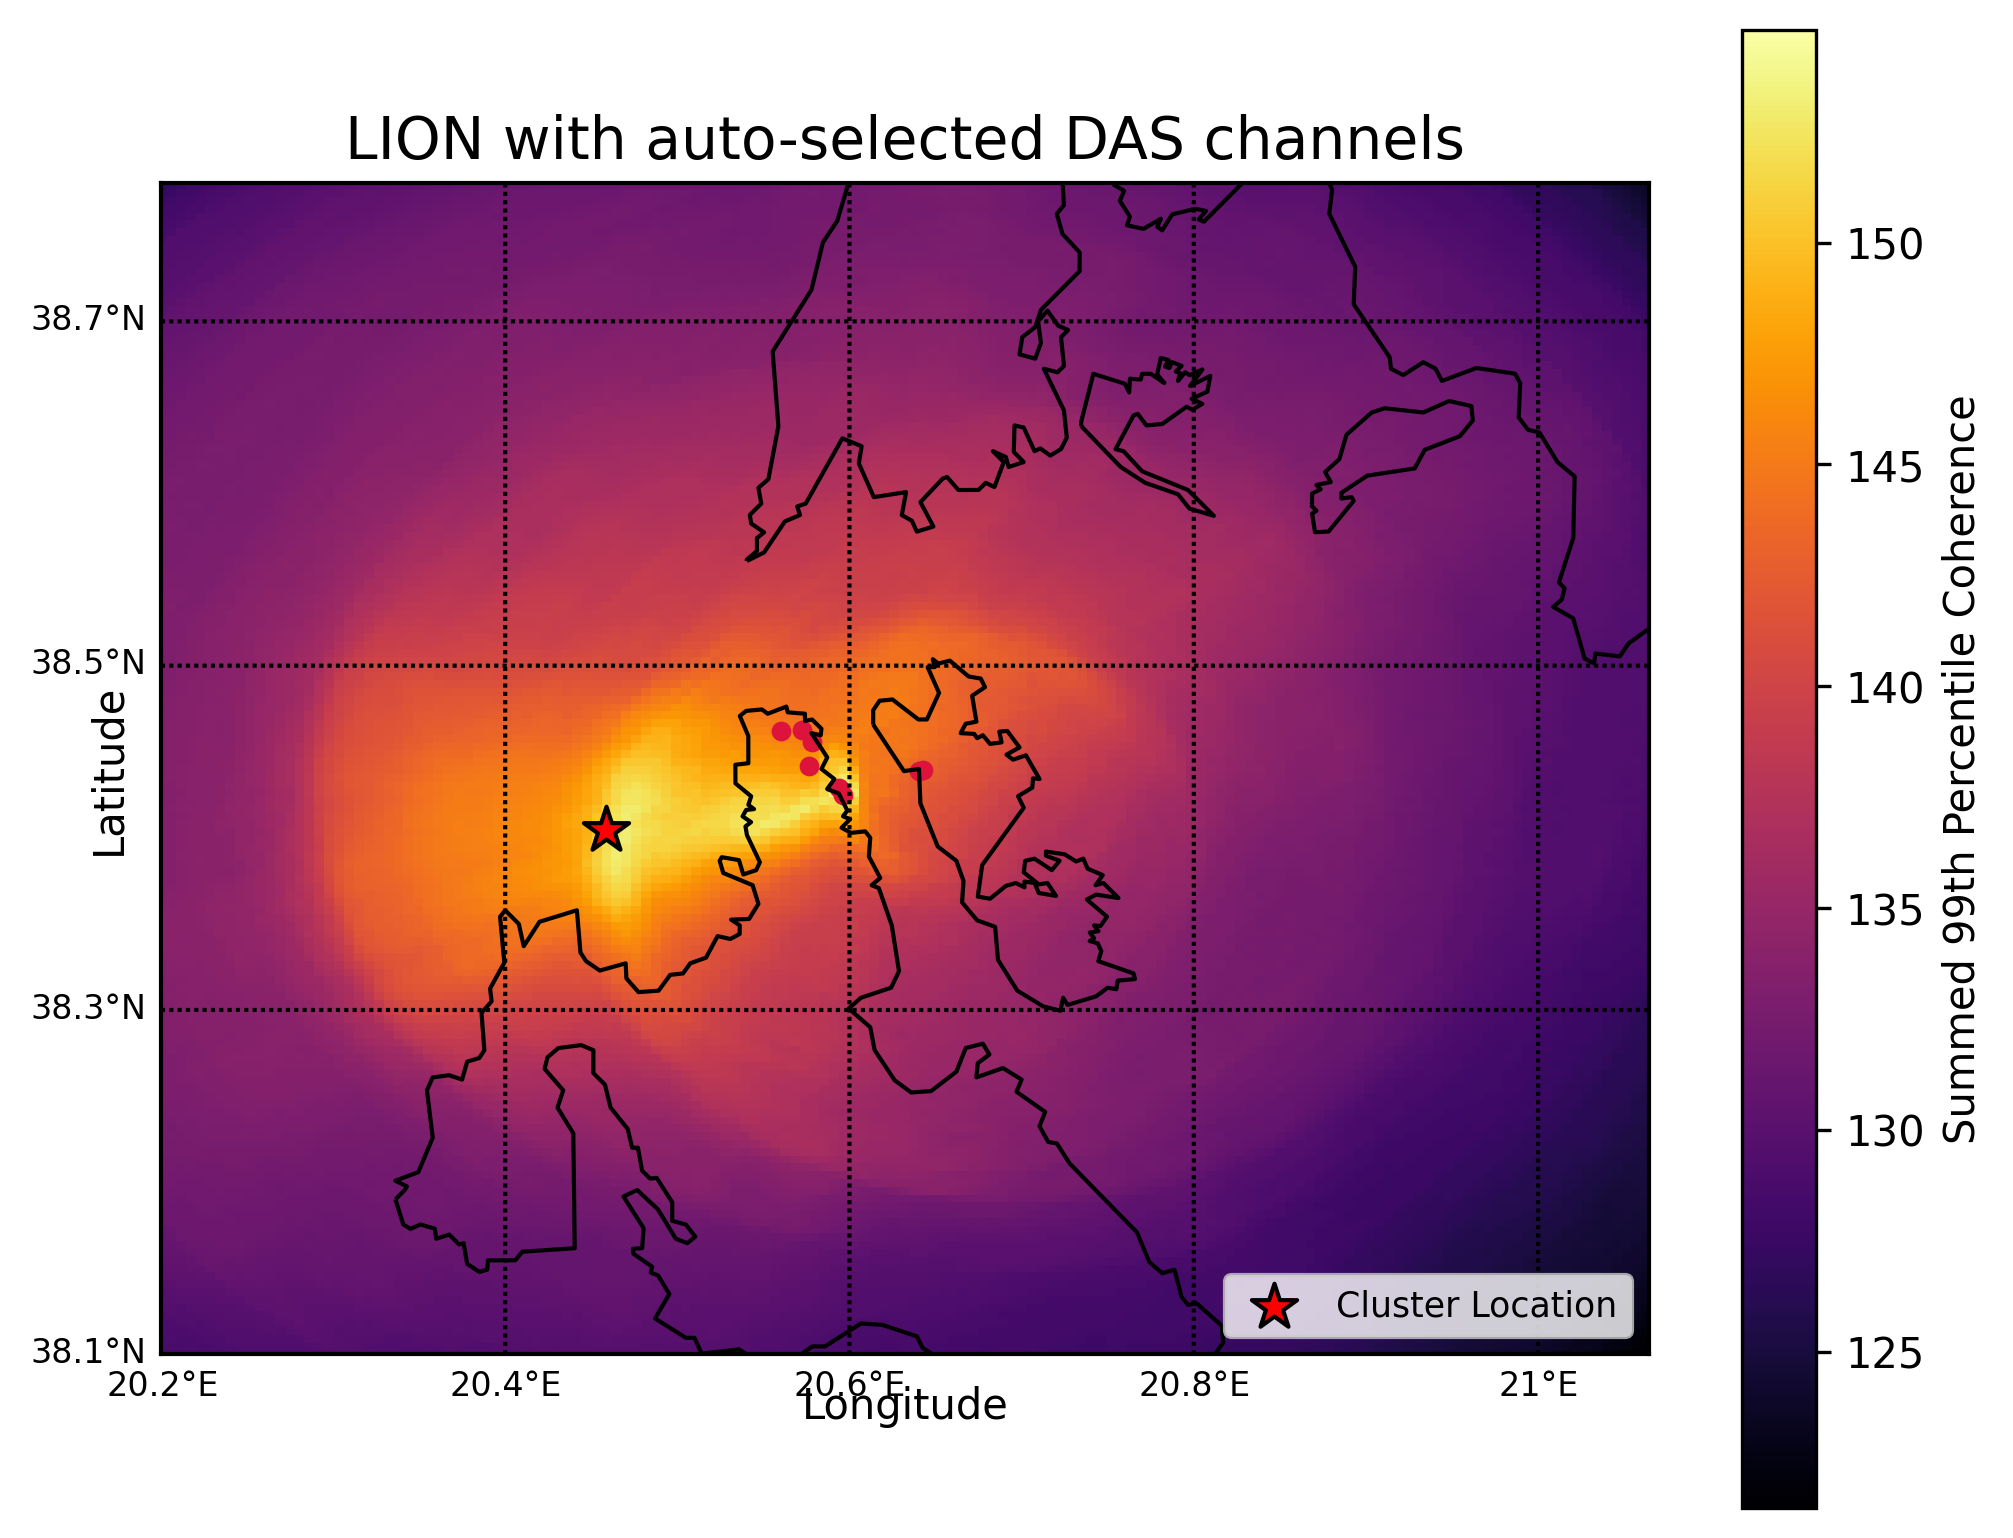

In [6]:
plot_fiber_only_map_with_percentile_sum(
    ref_lat=38.10,
    ref_lon=20.20,
    das_hyb={
        "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
        "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
        "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
        "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
        "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
        "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
        "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
        "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
    },
    earthquake_location=(38.40435, 20.45875),
    cartesian_grid_x=cartesian_grid_x,
    cartesian_grid_y=cartesian_grid_y,
    lat_range=(38.1, 38.78018018018018),
    lon_range=(20.2, 21.064340969963332),
    parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_complete',
    title="LION with auto-selected DAS channels"
)
